# Evaluación de la deformación superficial asociada a movimientos en masa mediante análisis InSAR y datos GNSS en la cuenca media y baja del río Suárez, Colombia

## Componente InSAR: series temporales Sentinel-1 con HyP3 y MintPy

**Autores:** Mariana Paredes Galindo · Sair Granada Garzón  
**Director:** José Pedro Mora Ortiz, Geólogo, MSc. en Sistemas de Información Geográfica y MSc. en Geofísica  
**Codirector:** José Luis Gómez Díaz, Ing. Catastral y Geodesta, MSc. en Ciencias de la Geoinformación y Observación de la Tierra  

Universidad Industrial de Santander · Facultad de Ingenierías Fisicoquímicas · Escuela de Geología  
Bucaramanga, 2026

## 1. Dependencias del entorno de trabajo

**Ejecución:** una sola vez, o cuando se cambie de máquina o de entorno.

Esta celda verifica que las librerías necesarias estén instaladas en el núcleo (*kernel*) de Jupyter e instala únicamente las que falten, sin reinstalar las existentes. Para ello, `importlib.util.find_spec` comprueba si cada módulo puede importarse y `subprocess` invoca al gestor de paquetes `pip` con el mismo intérprete de Python del notebook (`sys.executable`), lo que garantiza que la instalación quede en el entorno activo (Python Software Foundation, 2024).

Las librerías verificadas corresponden a la búsqueda de escenas (`asf_search`; Alaska Satellite Facility [ASF], s.f.-a), la gestión de trabajos de interferometría en la nube (`hyp3_sdk`; Hogenson et al., 2026), el manejo de datos geoespaciales (`geopandas`, `rasterio`, `pyproj`), la lectura de los archivos HDF5 generados por MintPy (`h5py`; Collette, 2013) y la visualización del progreso (`tqdm`; da Costa-Luis, 2019). MintPy se ejecuta en un entorno conda independiente, descrito en la sección 13.

In [21]:
import importlib.util, subprocess, sys

PAQUETES = {
    "hyp3_sdk": "hyp3-sdk",
    "asf_search": "asf-search",
    "geopandas": "geopandas",
    "rasterio": "rasterio",
    "h5py": "h5py",
    "pyproj": "pyproj",
    "tqdm": "tqdm",
}

faltantes = [pip for mod, pip in PAQUETES.items() if importlib.util.find_spec(mod) is None]
if faltantes:
    print("Instalando:", faltantes)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
else:
    print("Todas las dependencias ya están instaladas.")

Todas las dependencias ya están instaladas.


## 2. Librerías

**Ejecución:** siempre, al abrir el notebook.

Se importan en un solo lugar todas las librerías del flujo de procesamiento. La función de cada una es la siguiente:

| Librería / módulo | Función en el flujo | Referencia |
|---|---|---|
| `os`, `re`, `getpass`, `zipfile`, `shutil`, `time`, `subprocess`, `pathlib` | Biblioteca estándar de Python: variables de entorno, expresiones regulares, ingreso seguro de contraseñas, descompresión de productos, copia de archivos, medición de tiempos, ejecución de MintPy como proceso externo y manejo de rutas independiente del sistema operativo. | Python Software Foundation (2024) |
| `numpy` | Operaciones con arreglos numéricos: máscaras, estadísticas y álgebra lineal del análisis de la red de interferogramas. | Harris et al. (2020) |
| `pandas` | Tablas de escenas, pares interferométricos y resúmenes; manejo de fechas. | McKinney (2010) |
| `geopandas` | Tablas con geometría: polígono de la cuenca, huellas de las escenas y reproyección entre sistemas de coordenadas. | Jordahl et al. (2020) |
| `matplotlib` (`pyplot`, `dates`, `lines`) | Gráficas y mapas: red de interferogramas, coherencia, velocidad y series temporales. | Hunter (2007) |
| `rasterio` (`windows`, `transform`, `features`) | Lectura y escritura de GeoTIFF, recorte por ventanas, conversión entre coordenadas y píxeles, y enmascaramiento con el polígono de la cuenca. | Gillies et al. (2013) |
| `h5py` | Lectura de los archivos HDF5 que produce MintPy (`ifgramStack.h5`, `timeseries.h5`, `velocity.h5`). | Collette (2013) |
| `pyproj` (`Transformer`) | Transformación de coordenadas geográficas (latitud y longitud) a UTM, para ubicar puntos sobre los productos. | Snow et al. (2024) |
| `shapely` (`wkt`, `geometry`, `ops`, `validation`) | Geometrías vectoriales: lectura del polígono en formato WKT, reparación de geometrías inválidas, puntos, uniones e intersecciones. | Gillies et al. (2024) |
| `asf_search` | Búsqueda de escenas Sentinel-1 en el archivo del Alaska Satellite Facility. | ASF (s.f.-a) |
| `hyp3_sdk` (`HyP3`, `Batch`) | Envío, consulta y descarga de trabajos de interferometría en el servicio HyP3. | Hogenson et al. (2026) |
| `tqdm` | Barras de progreso en los procesos largos. | da Costa-Luis (2019) |

In [22]:
# Biblioteca estándar de Python
import os, re, getpass, zipfile, shutil, time, subprocess
from pathlib import Path

# Cálculo numérico y tablas
import numpy as np
import pandas as pd

# Datos geoespaciales vectoriales
import geopandas as gpd
from shapely import wkt
from shapely.geometry import shape, Point
from shapely.ops import unary_union
from shapely.validation import make_valid
from pyproj import Transformer

# Datos ráster (GeoTIFF de HyP3) y HDF5 (MintPy)
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import Window, from_bounds
from rasterio.transform import from_origin, rowcol
from rasterio.features import geometry_mask
import h5py

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

# Acceso a datos Sentinel-1 y procesamiento en ASF HyP3
import asf_search as asf
from hyp3_sdk import HyP3, Batch

plt.rcParams.update({"font.size": 11})
print("Librerías cargadas")

Librerías cargadas


## 3. Rutas de trabajo

**Ejecución:** siempre, al abrir el notebook.

Esta celda define la carpeta raíz del proyecto (`BASE_DIR`) y, a partir de ella, todas las rutas del flujo de procesamiento. Se usa una ruta absoluta para que el notebook encuentre los datos y los resultados sin importar la carpeta desde la que se ejecute; para usar el flujo en otro equipo basta con modificar `BASE_DIR`. Las rutas se construyen con `pathlib.Path`, que las hace compatibles con Linux, macOS y Windows (Python Software Foundation, 2024).

El proyecto se organiza en tres etapas numeradas, en el orden en que se generan los datos:

    Tesis_InSAR_Rio_Suarez/
    ├── 01_datos/
    │   ├── cuenca/                      límite del área de estudio
    │   ├── pares/                       tabla de pares interferométricos enviados a HyP3
    │   └── hyp3/
    │       ├── zip/<stack>/             productos originales descargados de HyP3
    │       ├── descomprimidos/<stack>/  productos completos
    │       └── recortados/<stack>/      capas recortadas al área común (entrada de MintPy)
    ├── 02_mintpy/
    │   ├── ERA5/                        modelos meteorológicos para la corrección troposférica
    │   └── <stack>/                     directorio de trabajo de MintPy
    ├── 03_resultados/
    │   ├── geotiff/<stack>/             mapas de velocidad para sistemas de información geográfica
    │   ├── figuras/                     figuras de la tesis
    │   └── tablas/                      tablas resumen
    └── notebooks/

Se denomina *stack* al conjunto de interferogramas con una misma geometría de adquisición (misma órbita relativa y *frame*). MintPy requiere un directorio de trabajo independiente para cada stack, de acuerdo con la estructura recomendada para productos HyP3 en su documentación (Yunjun et al., 2019), en el tutorial de series temporales del Alaska Satellite Facility (ASF, s.f.-b) y en los materiales del curso *InSAR Processing and Analysis* (EarthScope Consortium, 2026).

El identificador `RUN_ID` distingue la corrida de procesamiento (área, periodo y versión) y forma parte del nombre de cada stack y de la tabla de pares.

In [23]:
# Carpeta raíz del proyecto (ruta absoluta)
BASE_DIR = Path.home() / "Tesis_InSAR_Rio_Suarez"
RUN_ID = "suarez_2024_2026_v1"   # identificador de la corrida: área, periodo y versión
BARRA_FORMATO = "{desc} {percentage:3.0f}% |{bar:35}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"

if not BASE_DIR.exists():
    raise FileNotFoundError(f"No existe {BASE_DIR}. Revise BASE_DIR.")

# 01_datos: insumos
DATOS_DIR     = BASE_DIR / "01_datos"
CUENCA_DIR    = DATOS_DIR / "cuenca"
ARCHIVO_PARES = DATOS_DIR / "pares" / f"{RUN_ID}_pares.csv"
HYP3_DIR      = DATOS_DIR / "hyp3"
DOWNLOAD_DIR  = HYP3_DIR / "zip"               # productos originales de HyP3
UNZIP_DIR     = HYP3_DIR / "descomprimidos"    # productos completos
CLIP_DIR      = HYP3_DIR / "recortados"        # capas recortadas, entrada de MintPy

# 02_mintpy: procesamiento de series temporales
MINTPY_ROOT = BASE_DIR / "02_mintpy"
WEATHER_DIR = MINTPY_ROOT / "ERA5"

# 03_resultados: productos finales
RESULTADOS_DIR = BASE_DIR / "03_resultados"
GEOTIFF_DIR    = RESULTADOS_DIR / "geotiff"
FIGURAS_DIR    = RESULTADOS_DIR / "figuras"
TABLAS_DIR     = RESULTADOS_DIR / "tablas"

for carpeta in [CUENCA_DIR, ARCHIVO_PARES.parent, DOWNLOAD_DIR, UNZIP_DIR, CLIP_DIR,
                MINTPY_ROOT, WEATHER_DIR, GEOTIFF_DIR, FIGURAS_DIR, TABLAS_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

# Verificación
stacks = sorted(p.name for p in MINTPY_ROOT.iterdir() if p.is_dir() and p.name != "ERA5")
print("Proyecto:", BASE_DIR)
print("Tabla de pares:", "encontrada" if ARCHIVO_PARES.exists() else "NO encontrada")
print("Stacks recortados:", len(list(CLIP_DIR.iterdir())))
print("Stacks en MintPy:", stacks)

Proyecto: /home/jovyan/Tesis_InSAR_Rio_Suarez
Tabla de pares: encontrada
Stacks recortados: 4
Stacks en MintPy: ['suarez_2024_2026_v1_ASCENDING_R77_F1199', 'suarez_2024_2026_v1_ASCENDING_R77_F1200', 'suarez_2024_2026_v1_DESCENDING_R69_F572']


## 4. Área de estudio, periodo de análisis y evento de referencia

**Ejecución:** siempre, al abrir el notebook. En esta celda se editan el periodo y los datos del evento.

**Polígono de la cuenca.** El límite de la cuenca media y baja del río Suárez se define en formato WKT (*Well-Known Text*) en coordenadas geográficas WGS 84 (EPSG:4326). La función `make_valid` corrige posibles autointersecciones del polígono para que las operaciones de intersección y recorte sean válidas (Gillies et al., 2024). El polígono se usa para buscar las escenas Sentinel-1, calcular la cobertura de cada stack, delimitar el área de procesamiento en MintPy y enmascarar los resultados.

**Periodo de análisis.** `START` y `END` delimitan el rango de fechas de la búsqueda de escenas.

**Evento de referencia.** `PUNTO_EVENTO` ubica el sector de Vélez en los mapas. `FECHA_EVENTO_TXT` es opcional: si se especifica, MintPy estima en esa fecha una función escalón que separa un desplazamiento súbito de la tendencia lineal (Hetland et al., 2012); si es `None`, el modelo temporal incluye solo la tendencia y la estacionalidad.

In [24]:
# Polígono de la cuenca media y baja del río Suárez (WGS 84, EPSG:4326)
detailed_suarez_wkt = r"""POLYGON((-73.3349 6.7904,-73.3597 6.7829,-73.369 6.7669,-73.367 6.7423,-73.3721 6.7366,-73.3652 6.7266,-73.3831 6.7021,-73.3786 6.6977,-73.3831 6.6571,-73.3995 6.6382,-73.4061 6.6172,-73.4177 6.6042,-73.4188 6.592,-73.4304 6.5801,-73.4282 6.5615,-73.4415 6.5407,-73.4349 6.514,-73.4487 6.4913,-73.4412 6.4734,-73.4535 6.473,-73.4632 6.4648,-73.4666 6.4378,-73.4741 6.4314,-73.4727 6.4204,-73.4824 6.402,-73.4765 6.3811,-73.4798 6.369,-73.4749 6.3455,-73.4962 6.3163,-73.4972 6.2722,-73.5354 6.2581,-73.5377 6.2468,-73.5539 6.2392,-73.5556 6.224,-73.5674 6.229,-73.572 6.2193,-73.5803 6.2197,-73.5827 6.2128,-73.5918 6.2125,-73.6395 6.1197,-73.6512 6.1108,-73.6598 6.0923,-73.6752 6.0799,-73.6975 6.0347,-73.7055 6.0392,-73.7297 6.0358,-73.7483 6.0457,-73.7552 6.0375,-73.7638 6.0419,-73.7725 6.0345,-73.7793 6.0367,-73.7819 6.0451,-73.7919 6.0422,-73.7932 6.017,-73.7966 6.011,-73.8086 6.0105,-73.8075 5.9986,-73.8177 5.9864,-73.8156 5.971,-73.8268 5.9648,-73.8315 5.9561,-73.8407 5.9551,-73.8353 5.9378,-73.8408 5.9201,-73.8607 5.8946,-73.8585 5.8849,-73.8461 5.8747,-73.8538 5.8531,-73.8321 5.8426,-73.8412 5.8309,-73.8394 5.8217,-73.8557 5.8124,-73.8574 5.8032,-73.8357 5.7827,-73.8237 5.7406,-73.8188 5.7364,-73.819 5.7148,-73.7939 5.7282,-73.7905 5.7403,-73.7633 5.7694,-73.7392 5.7644,-73.7167 5.7731,-73.6925 5.7501,-73.6833 5.7523,-73.6725 5.747,-73.6648 5.7218,-73.6518 5.711,-73.6559 5.6934,-73.6703 5.6757,-73.6784 5.6433,-73.6966 5.6165,-73.6939 5.6119,-73.7161 5.5934,-73.7136 5.5803,-73.7246 5.5787,-73.72 5.5376,-73.7259 5.527,-73.7145 5.5109,-73.6888 5.5115,-73.6902 5.5079,-73.6809 5.4987,-73.6813 5.4871,-73.6746 5.4838,-73.6749 5.4657,-73.6532 5.4708,-73.6427 5.4682,-73.6425 5.4618,-73.6545 5.45,-73.6463 5.4339,-73.6316 5.4276,-73.6192 5.4118,-73.6044 5.4146,-73.5905 5.4031,-73.5317 5.444,-73.5193 5.4397,-73.5033 5.453,-73.493 5.4533,-73.4879 5.4624,-73.4652 5.48,-73.459 5.4892,-73.4637 5.4972,-73.4552 5.5021,-73.4437 5.5234,-73.4246 5.5292,-73.4267 5.5545,-73.4227 5.5606,-73.4311 5.5672,-73.4262 5.5802,-73.4175 5.5877,-73.4191 5.6036,-73.4017 5.6367,-73.3901 5.6447,-73.3836 5.6331,-73.385 5.6207,-73.3735 5.6114,-73.3487 5.628,-73.3463 5.6344,-73.3553 5.6509,-73.3443 5.6788,-73.3329 5.6846,-73.3271 5.6942,-73.3273 5.7085,-73.3335 5.7197,-73.3291 5.7249,-73.3362 5.7355,-73.3314 5.7438,-73.3457 5.7628,-73.3428 5.7673,-73.3244 5.7661,-73.2975 5.7735,-73.2794 5.7942,-73.2466 5.817,-73.228 5.8249,-73.2064 5.8262,-73.1846 5.8498,-73.1713 5.8507,-73.1637 5.846,-73.1598 5.8519,-73.1416 5.8514,-73.1298 5.8547,-73.1173 5.872,-73.1006 5.8725,-73.0846 5.885,-73.0793 5.8998,-73.0814 5.9128,-73.0701 5.9345,-73.0748 5.9414,-73.0851 5.9366,-73.1155 5.9385,-73.1295 5.9327,-73.1577 5.9382,-73.1622 5.9661,-73.1685 5.9706,-73.1765 5.999,-73.1734 6.0192,-73.1595 6.0287,-73.1458 6.0547,-73.1429 6.0691,-73.1489 6.0821,-73.1457 6.0902,-73.1711 6.0975,-73.175 6.1087,-73.1917 6.1253,-73.1942 6.1189,-73.2077 6.1117,-73.2182 6.1169,-73.2151 6.1342,-73.2314 6.1445,-73.2374 6.1646,-73.2502 6.1739,-73.2354 6.2063,-73.2189 6.2142,-73.2089 6.2131,-73.2058 6.2199,-73.2069 6.2448,-73.2007 6.2572,-73.2005 6.2759,-73.2144 6.3053,-73.2067 6.3084,-73.2017 6.3174,-73.2084 6.322,-73.2107 6.3325,-73.2022 6.3459,-73.2044 6.3651,-73.1951 6.3762,-73.2021 6.4015,-73.1992 6.4058,-73.2041 6.4118,-73.2008 6.4207,-73.1942 6.422,-73.191 6.4348,-73.1948 6.4441,-73.2072 6.4543,-73.209 6.4739,-73.219 6.4854,-73.2257 6.4869,-73.2347 6.4787,-73.2386 6.4886,-73.2641 6.5014,-73.2722 6.5104,-73.2684 6.5154,-73.2481 6.5198,-73.2334 6.5336,-73.2268 6.5572,-73.2122 6.5594,-73.2029 6.5696,-73.1894 6.574,-73.1686 6.6237,-73.1508 6.6196,-73.1124 6.6317,-73.123 6.6423,-73.1203 6.6497,-73.1317 6.6555,-73.1255 6.6698,-73.1388 6.6732,-73.1366 6.6903,-73.183 6.7162,-73.1942 6.7285,-73.2056 6.7617,-73.1986 6.767,-73.2066 6.781,-73.2341 6.7722,-73.2405 6.7748,-73.2485 6.7889,-73.2665 6.7857,-73.275 6.7668,-73.2849 6.758,-73.291 6.7595,-73.2903 6.7674,-73.3017 6.7807,-73.3256 6.783,-73.3349 6.7904))"""

geom = make_valid(wkt.loads(detailed_suarez_wkt))
gdf_cuenca = gpd.GeoDataFrame({"nombre": ["Cuenca Suárez"]}, geometry=[geom], crs="EPSG:4326")

# Periodo de análisis
START = "2024-01-01"
END   = "2026-09-30"

# Evento de referencia
FECHA_EVENTO_TXT = None                 # "AAAA-MM-DD"; None = sin función escalón
PUNTO_EVENTO = Point(-73.673, 6.012)    # (longitud, latitud)
FECHA_EVENTO = pd.Timestamp(FECHA_EVENTO_TXT) if FECHA_EVENTO_TXT else None

print("Polígono válido:", geom.is_valid)
print("Extensión (W, S, E, N):", geom.bounds)
print("Evento:", FECHA_EVENTO.date() if FECHA_EVENTO else "sin fecha",
      "| punto:", PUNTO_EVENTO.wkt, "| dentro de la cuenca:", geom.contains(PUNTO_EVENTO))

Polígono válido: True
Extensión (W, S, E, N): (-73.8607, 5.4031, -73.0701, 6.7904)
Evento: sin fecha | punto: POINT (-73.673 6.012) | dentro de la cuenca: True


## 5. Autenticación en NASA Earthdata y ASF HyP3

**Ejecución:** solo cuando se vaya a consultar, enviar o descargar trabajos de HyP3 (secciones 6 a 10). Para el análisis con MintPy y los resultados no es necesaria.

El procesamiento interferométrico se realizó en HyP3 (*Hybrid Pluggable Processing Pipeline*), el servicio en la nube del Alaska Satellite Facility que genera interferogramas Sentinel-1 con el software GAMMA (Hogenson et al., 2026). El acceso requiere una cuenta de NASA Earthdata, la misma con la que se enviaron los trabajos, porque HyP3 asocia cada trabajo al usuario que lo solicitó.

La celda crea una sesión con la clase `HyP3` del SDK de HyP3 (ASF, s.f.-c) y consulta los créditos disponibles con `check_credits()`. Cada interferograma `INSAR_GAMMA` consume créditos de la cuota mensual del usuario. El usuario se ingresa con `input` y la contraseña con `getpass`, que oculta lo que se escribe; la contraseña se pasa directamente a la sesión sin guardarse en una variable, de modo que no queda en el notebook ni en el repositorio (Python Software Foundation, 2024).

In [27]:
usuario = input("Usuario NASA Earthdata: ")
hyp3 = HyP3(username=usuario, password=getpass.getpass("Contraseña NASA Earthdata: "))

print("Sesión iniciada como:", usuario)
print("Créditos disponibles:", hyp3.check_credits())

Usuario NASA Earthdata:  marianaparedes
Contraseña NASA Earthdata:  ········


Sesión iniciada como: marianaparedes
Créditos disponibles: 4970


## 6. Búsqueda de escenas Sentinel-1

**Ejecución:** una sola vez. Ya fue ejecutada; se conserva como registro metodológico. Solo consulta el catálogo del Alaska Satellite Facility, no descarga datos ni consume créditos.

Se usaron imágenes de la misión Sentinel-1 del programa Copernicus (Copernicus Sentinel-1, 2024–2026), compuesta por satélites de radar de apertura sintética (SAR) en banda C (longitud de onda de 5.55 cm) que adquieren imágenes cada 6 a 12 días sobre la misma zona (Torres et al., 2012). Se buscaron productos de nivel 1 SLC (*Single Look Complex*) en modo IW (*Interferometric Wide Swath*), que conservan la amplitud y la fase de la señal y son los productos de entrada para interferometría.

La búsqueda se realiza con la función `geo_search` de la librería `asf_search` (ASF, s.f.-a), con los siguientes criterios:

| Parámetro | Valor | Significado |
|---|---|---|
| `intersectsWith` | Polígono de la cuenca simplificado | Escenas cuya huella se cruza con el área de estudio. |
| `start`, `end` | `START`, `END` (sección 4) | Periodo de análisis. |
| `platform` | Sentinel-1 | Misión satelital. |
| `beamMode` | IW | Modo de adquisición interferométrico de franja ancha. |
| `processingLevel` | SLC | Producto complejo apto para interferometría. |

El polígono se simplifica con una tolerancia de 0.005° (unos 550 m) mediante `simplify`, porque el servicio de búsqueda limita el número de vértices de la geometría de consulta; esta simplificación no afecta el resultado, ya que la huella de una escena Sentinel-1 mide unos 250 × 170 km. El método `raise_if_incomplete()` detiene la ejecución si la consulta no devolvió todos los resultados, por ejemplo por una interrupción de la conexión.

Con los resultados se construye una tabla geográfica (`GeoDataFrame`; Jordahl et al., 2020) con una fila por escena y los campos: nombre de la escena, dirección de vuelo (ascendente o descendente), órbita relativa (*path*), *frame*, fecha de adquisición, huella y si la escena cubre el punto del evento. Las escenas duplicadas se eliminan y la tabla se ordena por geometría de adquisición y fecha, lo que facilita agrupar los stacks en la sección siguiente. Este procedimiento sigue el módulo de búsqueda y acceso a datos del curso *InSAR Processing and Analysis* (EarthScope Consortium, 2026).

In [28]:
# Geometría de búsqueda: polígono de la cuenca simplificado
search_wkt = geom.simplify(0.005).wkt

# Consulta al catálogo del Alaska Satellite Facility
res = asf.geo_search(
    intersectsWith=search_wkt,
    start=START,
    end=END,
    platform=asf.PLATFORM.SENTINEL1,
    beamMode="IW",
    processingLevel="SLC",
)
res.raise_if_incomplete() 

# Tabla geográfica con una fila por escena
scene_gdf = gpd.GeoDataFrame(
    [
        {
            "scene": r.properties["sceneName"],                 # nombre de la escena
            "dir": r.properties["flightDirection"],             # ASCENDING / DESCENDING
            "path": r.properties["pathNumber"],                 # órbita relativa
            "frame": r.properties["frameNumber"],               # frame
            "date": pd.to_datetime(r.properties["startTime"]).tz_localize(None).normalize(),
            "cubre_evento": shape(r.geometry).covers(PUNTO_EVENTO),
            "geometry": shape(r.geometry),                      # huella de la escena
        }
        for r in res
    ],
    crs="EPSG:4326",
)

# Eliminar duplicados y ordenar por geometría de adquisición y fecha
scene_gdf = (scene_gdf.drop_duplicates("scene")
             .sort_values(["dir", "path", "frame", "date"])
             .reset_index(drop=True))

print("Escenas encontradas:", len(scene_gdf))
display(scene_gdf.head())

Escenas encontradas: 541


,scene,dir,path,frame,date,cubre_evento,geometry
0,S1C_IW_SLC__1SDV_20250515T230450_20250515T2305...,ASCENDING,77,1195,2025-05-15,False,"POLYGON ((-73.39664 3.89734, -71.1698 4.36257,..."
1,S1C_IW_SLC__1SDV_20250608T230453_20250608T2305...,ASCENDING,77,1195,2025-06-08,False,"POLYGON ((-73.40122 3.89706, -71.17431 4.36229..."
2,S1C_IW_SLC__1SDV_20250702T230454_20250702T2305...,ASCENDING,77,1195,2025-07-02,False,"POLYGON ((-73.40051 3.89709, -71.1735 4.36238,..."
3,S1C_IW_SLC__1SDV_20250726T230456_20250726T2305...,ASCENDING,77,1195,2025-07-26,False,"POLYGON ((-73.40077 3.89741, -71.17386 4.36264..."
4,S1C_IW_SLC__1SDV_20250819T230457_20250819T2305...,ASCENDING,77,1195,2025-08-19,False,"POLYGON ((-73.40066 3.89784, -71.17381 4.36307..."


## 7. Cobertura de la cuenca y selección de stacks

**Ejecución:** una sola vez. Ya fue ejecutada; se conserva como registro metodológico.

Las escenas encontradas se agrupan en *stacks*, es decir, conjuntos de adquisiciones con la misma geometría: misma dirección de vuelo (ascendente o descendente), misma órbita relativa (*path*) y mismo *frame*. Solo las imágenes de un mismo stack pueden combinarse en interferogramas e invertirse juntas en una serie temporal; los interferogramas de geometrías distintas no forman un stack (EarthScope Consortium, 2026).

Para cada stack se calcula:

| Campo | Cálculo |
|---|---|
| `n_fechas`, `inicio`, `fin` | Número de fechas de adquisición distintas y rango temporal cubierto. |
| `antes_evento`, `despues_evento` | Fechas anteriores y posteriores al evento, si se definió `FECHA_EVENTO`. |
| `evento_cubierto` | Si alguna escena del stack cubre el punto del evento. |
| `cobertura_pct_cuenca` | Porcentaje del área de la cuenca cubierto por la unión de las huellas del stack. |

La huella del stack se obtiene uniendo las huellas de todas sus escenas con `unary_union` (Gillies et al., 2024) y se intersecta con el polígono de la cuenca. Las áreas se calculan en el sistema MAGNA-SIRGAS / Colombia Bogotá (EPSG:3116), que usa metros; en coordenadas geográficas (grados) no es posible medir áreas directamente. La reproyección se hace con `to_crs` de GeoPandas (Jordahl et al., 2020).

**Criterios de selección.** Se conservan los stacks que cubren más del 50 % de la cuenca y que tienen al menos `MIN_FECHAS` = 12 adquisiciones. Ambos umbrales son criterios adoptados en este trabajo: el primero asegura que el stack represente una parte significativa del área de estudio, y el segundo que la red de interferogramas tenga suficientes observaciones para estimar una serie temporal por el método de pequeñas líneas base (SBAS), en el que cada fecha debe quedar conectada con las demás a través de varios interferogramas (Berardino et al., 2002; Yunjun et al., 2019). Los stacks se ordenan priorizando los que cubren el evento y los de mayor número de fechas.

El mapa resultante muestra el límite de la cuenca, la huella de cada stack seleccionado con su número de fechas y porcentaje de cobertura, y la ubicación del evento. Se guarda en `03_resultados/figuras/` (Hunter, 2007).

Stacks encontrados: 21 | seleccionados: 3


,dir,path,frame,n_fechas,inicio,fin,antes_evento,despues_evento,evento_cubierto,cobertura_pct_cuenca
0,DESCENDING,69,572,115,2024-01-03,2026-09-26,NaN,NaN,True,90.7
1,ASCENDING,77,1199,24,2025-05-03,2026-09-14,NaN,NaN,True,97.7
2,ASCENDING,77,1200,19,2025-05-15,2026-09-26,NaN,NaN,True,95.0


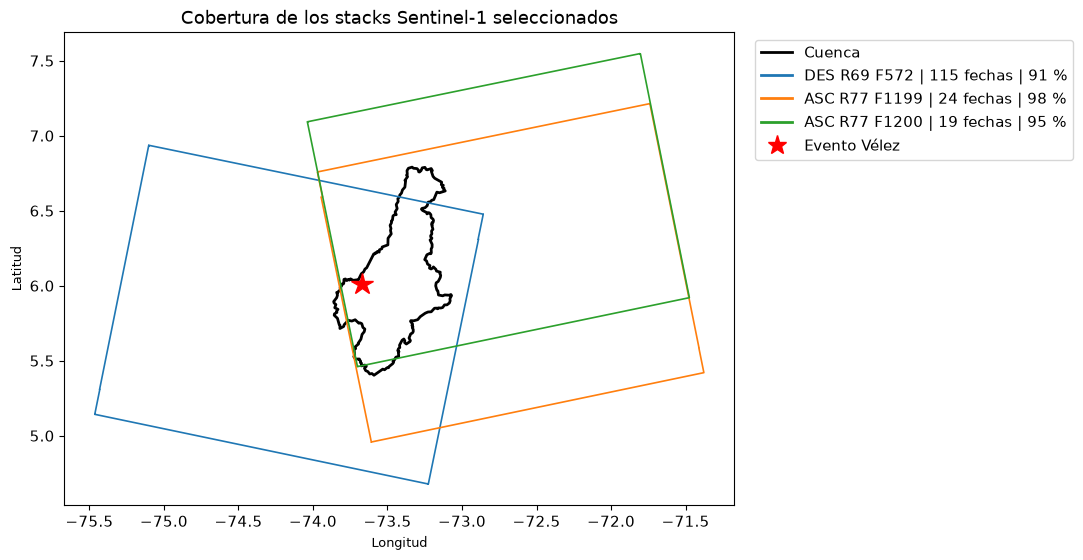

In [29]:
MIN_FECHAS = 12            # mínimo de adquisiciones por stack
MIN_COBERTURA_PCT = 50     # porcentaje mínimo de la cuenca cubierto

# Área de la cuenca en m² (EPSG:3116, MAGNA-SIRGAS / Colombia Bogotá)
aoi_m2 = gdf_cuenca.to_crs(3116).area.iloc[0]

# Resumen por stack (dirección, path, frame)
resumen = []
for (direccion, path, frame), grupo in scene_gdf.groupby(["dir", "path", "frame"]):
    huella = unary_union(grupo.geometry.tolist())                      # huella total del stack
    cobertura_m2 = (gpd.GeoSeries([huella.intersection(geom)], crs="EPSG:4326")
                    .to_crs(3116).area.iloc[0])
    resumen.append({
        "dir": direccion, "path": path, "frame": frame,
        "n_fechas": grupo["date"].nunique(),
        "inicio": grupo["date"].min(), "fin": grupo["date"].max(),
        "antes_evento": (grupo["date"] < FECHA_EVENTO).sum() if FECHA_EVENTO else np.nan,
        "despues_evento": (grupo["date"] > FECHA_EVENTO).sum() if FECHA_EVENTO else np.nan,
        "evento_cubierto": grupo["cubre_evento"].any(),
        "cobertura_pct_cuenca": 100 * cobertura_m2 / aoi_m2,
        "geometry": huella,
    })
stacks_gdf = gpd.GeoDataFrame(resumen, crs="EPSG:4326")

# Selección: cobertura y número de fechas
stacks_sel = (stacks_gdf[(stacks_gdf["cobertura_pct_cuenca"] > MIN_COBERTURA_PCT)
                         & (stacks_gdf["n_fechas"] >= MIN_FECHAS)]
              .sort_values(["evento_cubierto", "n_fechas"], ascending=[False, False])
              .reset_index(drop=True))

print(f"Stacks encontrados: {len(stacks_gdf)} | seleccionados: {len(stacks_sel)}")
display(stacks_sel.drop(columns="geometry").round({"cobertura_pct_cuenca": 1}))

# Mapa de cobertura
fig, ax = plt.subplots(figsize=(11, 12))
gdf_cuenca.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
colores = plt.cm.tab10(np.arange(max(len(stacks_sel), 1)) % 10)
handles = [Line2D([0], [0], color="black", lw=2, label="Cuenca")]

for color, (_, stack) in zip(colores, stacks_sel.iterrows()):
    gpd.GeoSeries([stack.geometry], crs="EPSG:4326").boundary.plot(ax=ax, color=color, linewidth=1.2)
    handles.append(Line2D([0], [0], color=color, lw=2,
                          label=f"{stack.dir[:3]} R{stack.path} F{stack.frame} | "
                                f"{stack.n_fechas} fechas | {stack.cobertura_pct_cuenca:.0f} %"))

ax.plot(PUNTO_EVENTO.x, PUNTO_EVENTO.y, "r*", ms=16)
handles.append(Line2D([0], [0], marker="*", color="red", markersize=14, linestyle="None", label="Evento Vélez"))
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.set(title="Cobertura de los stacks Sentinel-1 seleccionados", xlabel="Longitud", ylabel="Latitud")
plt.tight_layout()
fig.savefig(FIGURAS_DIR / "cobertura_stacks_sentinel1.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Red de pares interferométricos y envío a HyP3

**Ejecución:** una sola vez. Ya fue ejecutada; se conserva como registro metodológico. El envío está bloqueado (`ENVIAR_A_HYP3 = False`) para no repetir trabajos ni consumir créditos, y la tabla de pares no se sobrescribe si ya existe.

**Red de pares.** Se adoptó una red de pequeñas líneas base (SBAS, *Small BAseline Subset*), en la que cada fecha se combina solo con las fechas cercanas en el tiempo para limitar la decorrelación temporal (Berardino et al., 2002). En cada stack, cada fecha se une con sus `n_vecinos` fechas siguientes: dos vecinos si el stack cubre el evento y uno en caso contrario. Con dos vecinos la red contiene triángulos (tres interferogramas que cierran un ciclo entre tres fechas), que permiten detectar errores de desenrollado de fase por cierre de fase (Yunjun et al., 2019). Además, la redundancia de la red hace que la coherencia temporal sea un indicador útil de la calidad de la inversión (Pepe & Lanari, 2006); en una red secuencial de un solo vecino ese indicador vale prácticamente 1 en todos los píxeles y no discrimina (EarthScope Consortium, 2026).

**Envío a HyP3.** Cada par se procesa como un trabajo `INSAR_GAMMA` en HyP3, que genera el interferograma con el software GAMMA (Hogenson et al., 2026; Werner et al., 2000) con las siguientes opciones:

| Opción | Valor | Justificación |
|---|---|---|
| `looks` | `20x4` | Promedio de 20 píxeles en rango por 4 en azimut; tamaño de píxel de unos 80 m, que reduce el ruido y el volumen de datos. |
| `include_dem` | `True` | Incluye el modelo digital de elevación usado, necesario para la corrección del error de DEM en MintPy. |
| `include_look_vectors` | `True` | Incluye los ángulos del vector de mirada (`lv_theta`, `lv_phi`), de los que MintPy obtiene la incidencia y el azimut. |
| `apply_water_mask` | `True` | Enmascara los cuerpos de agua, donde la fase no es interpretable. |

HyP3 utiliza como modelo de elevación el Copernicus GLO-30, con resolución de 30 m (European Space Agency, 2022). La descripción de estas opciones y de las capas resultantes está en la guía de productos InSAR de HyP3 (ASF, s.f.-d), y el flujo completo sigue el tutorial de series temporales con HyP3 y MintPy (ASF, s.f.-b). Cada trabajo `INSAR_GAMMA` consume 10 créditos de la cuota del usuario.

In [30]:
COSTO_POR_PAR = 10        # créditos HyP3 por trabajo INSAR_GAMMA
ENVIAR_A_HYP3 = False     # NO cambiar: los trabajos ya fueron enviados

# Red SBAS: cada fecha con sus n_vecinos fechas siguientes, por stack
pares_lista = []
for _, stack_info in stacks_sel.iterrows():
    grupo = (scene_gdf[(scene_gdf["dir"] == stack_info["dir"])
                       & (scene_gdf["path"] == stack_info["path"])
                       & (scene_gdf["frame"] == stack_info["frame"])]
             .drop_duplicates("date").sort_values("date").reset_index(drop=True))
    n_vecinos = 2 if stack_info["evento_cubierto"] else 1
    stack_id = f"{stack_info['dir']}_R{stack_info['path']}_F{stack_info['frame']}"
    for i in range(len(grupo)):
        for j in range(i + 1, min(i + 1 + n_vecinos, len(grupo))):
            pares_lista.append({
                "stack_id": stack_id, "job_name": f"{RUN_ID}_{stack_id}",
                "ref": grupo.scene.iloc[i], "sec": grupo.scene.iloc[j],
                "fecha_ref": grupo.date.iloc[i], "fecha_sec": grupo.date.iloc[j],
                "dias": (grupo.date.iloc[j] - grupo.date.iloc[i]).days,
            })
pares_nuevos = pd.DataFrame(pares_lista)
print(f"Pares: {len(pares_nuevos)} | costo estimado: {len(pares_nuevos) * COSTO_POR_PAR} créditos")
display(pares_nuevos.groupby("stack_id").size().rename("n_pares").reset_index())

# Registro de pares: no se sobrescribe
if ARCHIVO_PARES.exists():
    print(f"{ARCHIVO_PARES.name} ya existe: no se sobrescribe (registro de los trabajos enviados).")
else:
    pares_nuevos.to_csv(ARCHIVO_PARES, index=False)
    print("Tabla de pares guardada en:", ARCHIVO_PARES)

# Envío a HyP3 (bloqueado)
if not ENVIAR_A_HYP3:
    print("Envío bloqueado: los trabajos ya fueron enviados.")
else:
    if len(pares_nuevos) * COSTO_POR_PAR > hyp3.check_credits():
        raise RuntimeError("Créditos insuficientes: no se enviaron trabajos.")
    jobs = Batch()
    for p in tqdm(pares_nuevos.itertuples(), total=len(pares_nuevos), desc="Enviando a HyP3", bar_format=BARRA_FORMATO):
        jobs += hyp3.submit_insar_job(p.ref, p.sec, name=p.job_name, include_look_vectors=True,
                                      include_dem=True, apply_water_mask=True, looks="20x4")
    print("Trabajos enviados:", len(jobs), "| créditos restantes:", hyp3.check_credits())

Pares: 307 | costo estimado: 3070 créditos


,stack_id,n_pares
0,ASCENDING_R77_F1199,45
1,ASCENDING_R77_F1200,35
2,DESCENDING_R69_F572,227


suarez_2024_2026_v1_pares.csv ya existe: no se sobrescribe (registro de los trabajos enviados).
Envío bloqueado: los trabajos ya fueron enviados.


## 9. Tabla de pares y stacks de trabajo

**Ejecución:** siempre, al abrir el notebook.

Se lee la tabla de pares enviada a HyP3 (sección 8), que es el registro fijo de los interferogramas del estudio, y se definen dos listas de stacks:

- `JOBS_TODOS`: todos los stacks procesados en HyP3; se usa en la descarga y el recorte.
- `JOBS`: los stacks que entran al análisis de series temporales. Se excluyen los indicados en `STACKS_EXCLUIDOS`. El stack ascendente R77 F1200 se excluyó por su baja coherencia media (0.25 a 0.50), un vacío de 96 días sin adquisiciones entre enero y abril de 2026, y porque después del filtro de coherencia su red quedó sin triángulos para controlar los errores de desenrollado.

La lectura usa `pandas.read_csv` con conversión de las columnas de fecha (McKinney, 2010).

In [31]:
STACKS_EXCLUIDOS = ["F1200"]   # stacks que no entran a MintPy

if not ARCHIVO_PARES.exists():
    raise FileNotFoundError(f"No se encontró la tabla de pares: {ARCHIVO_PARES}")

pares = pd.read_csv(ARCHIVO_PARES, parse_dates=["fecha_ref", "fecha_sec"])
JOBS_TODOS = list(pares["job_name"].unique())
JOBS = [j for j in JOBS_TODOS if not any(x in j for x in STACKS_EXCLUIDOS)]

print(f"Pares: {len(pares)} | stacks procesados: {len(JOBS_TODOS)} | stacks para MintPy: {len(JOBS)}")
display(pares.groupby("stack_id")
             .agg(n_pares=("ref", "size"), inicio=("fecha_ref", "min"), fin=("fecha_sec", "max"))
             .reset_index())

Pares: 299 | stacks procesados: 3 | stacks para MintPy: 2


,stack_id,n_pares,inicio,fin
0,ASCENDING_R77_F1199,45,2025-05-03,2026-09-14
1,ASCENDING_R77_F1200,33,2025-05-15,2026-09-02
2,DESCENDING_R69_F572,221,2024-01-03,2026-09-14


## 10. Estado de los trabajos, descarga y descompresión

**Ejecución:** una sola vez; requiere la sesión de HyP3 (sección 5). Si se repite, solo descarga los productos que falten.

Para cada stack se consulta en HyP3 el estado de sus trabajos (exitosos, pendientes y fallidos) con `find_jobs`, `refresh` y `filter_jobs` del SDK de HyP3 (ASF, s.f.-c). Luego se descargan los productos de los trabajos exitosos con `download_files` y se descomprimen, porque MintPy lee los GeoTIFF individuales y no los archivos comprimidos (Yunjun et al., 2019; ASF, s.f.-b).

- Los archivos `.zip` se guardan en `01_datos/hyp3/zip/<stack>/`.
- Los productos descomprimidos se guardan en `01_datos/hyp3/descomprimidos/<stack>/`, una carpeta por interferograma.

Antes de descargar, se verifica si la carpeta del producto ya existe; en ese caso se omite, lo que permite repetir la celda sin volver a descargar todo.

In [32]:
estado, descargados, omitidos = [], 0, 0

for job_name in tqdm(JOBS_TODOS, desc="Descargando", bar_format=BARRA_FORMATO):
    trabajos = hyp3.refresh(hyp3.find_jobs(name=job_name))
    exitosos = trabajos.filter_jobs(succeeded=True, running=False, failed=False)
    fallidos = trabajos.filter_jobs(succeeded=False, running=False, failed=True)
    estado.append({"stack": job_name, "total": len(trabajos), "exitosos": len(exitosos),
                   "pendientes": len(trabajos) - len(exitosos) - len(fallidos), "fallidos": len(fallidos)})

    destino_zip, destino_unzip = DOWNLOAD_DIR / job_name, UNZIP_DIR / job_name
    destino_zip.mkdir(parents=True, exist_ok=True)
    destino_unzip.mkdir(parents=True, exist_ok=True)

    for job in exitosos.jobs:
        producto = Path(job.files[0]["filename"]).stem      # nombre del producto = carpeta del zip
        if (destino_unzip / producto).exists():
            omitidos += 1
            continue
        for archivo_zip in job.download_files(destino_zip):
            with zipfile.ZipFile(archivo_zip) as zf:
                zf.extractall(destino_unzip)
        descargados += 1

display(pd.DataFrame(estado))
print(f"Productos descargados: {descargados} | ya existentes: {omitidos}")

Descargando   0% |                                   | 0/3 [00:00<?]

,stack,total,exitosos,pendientes,fallidos
0,suarez_2024_2026_v1_ASCENDING_R77_F1199,45,45,0,0
1,suarez_2024_2026_v1_ASCENDING_R77_F1200,33,33,0,0
2,suarez_2024_2026_v1_DESCENDING_R69_F572,225,221,0,4


Productos descargados: 0 | ya existentes: 299


## 11. Recorte de los productos al área común de cada stack

**Ejecución:** una sola vez. Si se repite, omite los archivos recortados que ya existen.

Los productos HyP3 de un mismo stack cubren áreas ligeramente distintas, pero MintPy requiere que todas las capas del stack compartan exactamente la misma grilla. Por ello, para cada stack:

1. Se calcula el rectángulo común a todos los pares como la intersección de los límites de sus modelos de elevación (`*_dem.tif`).
2. Se recortan a ese rectángulo las seis capas que usa MintPy: fase desenrollada (`unw_phase`), coherencia (`corr`), elevación (`dem`), ángulos del vector de mirada (`lv_theta`, `lv_phi`) y máscara de agua (`water_mask`). El recorte se hace por ventanas con `rasterio`, leyendo solo la porción necesaria de cada archivo (Gillies et al., 2013).
3. Se copian los archivos de metadatos `.txt`, de los que MintPy obtiene las fechas, la línea base perpendicular, el rumbo del satélite y la hora de adquisición de cada interferograma (Yunjun et al., 2019; ASF, s.f.-d).

Este procedimiento reproduce la función `clip_hyp3_products_to_common_overlap` del tutorial de ASF, que usa GDAL (ASF, s.f.-b), y mantiene el sufijo `_clip` de la estructura de directorios recomendada para productos HyP3 en MintPy.

In [33]:
SUFIJOS = ["unw_phase", "corr", "dem", "lv_theta", "lv_phi", "water_mask"]   # capas para MintPy

for job_name in tqdm(JOBS_TODOS, desc="Recortando", bar_format=BARRA_FORMATO):
    origen, destino = UNZIP_DIR / job_name, CLIP_DIR / job_name
    destino.mkdir(parents=True, exist_ok=True)
    carpetas = sorted(c for c in origen.iterdir() if c.is_dir())

    # 1) Rectángulo común: intersección de los límites de los DEM
    limites = []
    for carpeta in carpetas:
        dem = next(carpeta.glob("*_dem.tif"), None)
        if dem is not None:
            with rasterio.open(dem) as src:
                limites.append(src.bounds)
    if not limites:
        print("Sin DEM:", job_name)
        continue
    xmin, xmax = max(b.left for b in limites), min(b.right for b in limites)
    ymin, ymax = max(b.bottom for b in limites), min(b.top for b in limites)
    if xmin >= xmax or ymin >= ymax:
        raise ValueError(f"Sin área común en {job_name}")

    # 2) Recorte por ventanas de cada capa
    for carpeta in carpetas:
        salida_par = destino / carpeta.name
        salida_par.mkdir(exist_ok=True)
        for sufijo in SUFIJOS:
            archivo = next(carpeta.glob(f"*_{sufijo}.tif"), None)
            if archivo is None:
                continue
            salida = salida_par / f"{archivo.stem}_clip.tif"
            if salida.exists():
                continue
            with rasterio.open(archivo) as src:
                ventana = (from_bounds(xmin, ymin, xmax, ymax, transform=src.transform)
                           .round_offsets().round_lengths()
                           .intersection(Window(0, 0, src.width, src.height)))
                datos = src.read(window=ventana)
                perfil = src.profile.copy()
                perfil.update(height=datos.shape[1], width=datos.shape[2],
                              transform=src.window_transform(ventana))
                with rasterio.open(salida, "w", **perfil) as dst:
                    dst.write(datos)

        # 3) Metadatos .txt (requeridos por MintPy)
        for txt in carpeta.glob("*.txt"):
            if not (salida_par / txt.name).exists():
                shutil.copy(txt, salida_par / txt.name)

print("Recorte completado")

Recortando   0% |                                   | 0/3 [00:00<?]

Recorte completado


## 12. Verificación de los insumos recortados

**Ejecución:** siempre, antes de preparar MintPy.

Antes de cargar los datos en MintPy se revisa, para cada interferograma de los stacks de trabajo (`JOBS`):

- que existan las seis capas recortadas y su archivo de metadatos `.txt`;
- que todas las capas del stack tengan la misma forma, la misma transformación geográfica y el mismo sistema de referencia;
- las fechas de adquisición y la línea base perpendicular, leídas del nombre del producto y de su archivo `.txt`.

Los productos HyP3 siguen la convención `S1xx_AAAAMMDDTHHMMSS_AAAAMMDDTHHMMSS_...`, en la que el segundo y el tercer campo son las fechas de referencia y secundaria (ASF, s.f.-d); es el mismo criterio con el que MintPy lee las fechas (Yunjun et al., 2019). Un par sin metadatos o con una grilla distinta hace fallar la carga en MintPy con mensajes poco claros, por lo que se detecta en este paso. El resultado se guarda en el diccionario `insumos`, que se usa en el análisis de la red.

Funciones definidas:

| Función | Descripción |
|---|---|
| `fechas_desde_producto(nombre)` | Devuelve las fechas de referencia y secundaria a partir del nombre del producto. |
| `leer_baseline(txt)` | Lee la línea base perpendicular (m) del archivo de metadatos. |
| `verificar_stack(job_name)` | Revisa capas, metadatos y grilla de cada par de un stack y devuelve una tabla. |

In [84]:
def fechas_desde_producto(nombre):
    partes = nombre.split("_")
    return pd.Timestamp(partes[1][:8]), pd.Timestamp(partes[2][:8])


def leer_baseline(txt):
    try:
        for linea in Path(txt).read_text().splitlines():
            if linea.strip().lower().startswith("baseline"):
                return float(linea.split(":")[1])
    except Exception:
        pass
    return np.nan


def verificar_stack(job_name):
    filas, grilla_ref = [], None
    for carpeta in sorted(c for c in (CLIP_DIR / job_name).iterdir() if c.is_dir()):
        f1, f2 = fechas_desde_producto(carpeta.name)
        fila = {"producto": carpeta.name, "fecha1": f1, "fecha2": f2, "dias": (f2 - f1).days}
        for sufijo in SUFIJOS:
            arch = next(carpeta.glob(f"*_{sufijo}_clip.tif"), None)
            fila[sufijo] = arch is not None
            if arch is not None:
                with rasterio.open(arch) as src:
                    grilla = (src.shape, tuple(round(v, 3) for v in src.transform[:6]), src.crs.to_epsg())
                grilla_ref = grilla_ref or grilla
                if grilla != grilla_ref:
                    print(f"  Grilla distinta en {arch.name}")
                    fila[sufijo] = False
        txt = carpeta / f"{carpeta.name}.txt"
        fila["txt"] = txt.exists()
        fila["bperp_m"] = leer_baseline(txt) if txt.exists() else np.nan
        filas.append(fila)
    tabla = pd.DataFrame(filas)
    tabla.attrs["grilla"] = grilla_ref
    return tabla


insumos = {}
for job_name in JOBS:
    tabla = verificar_stack(job_name)
    insumos[job_name] = tabla
    incompletos = tabla[~tabla[SUFIJOS + ["txt"]].all(axis=1)]
    forma, _, epsg = tabla.attrs["grilla"]
    n_fechas = pd.concat([tabla.fecha1, tabla.fecha2]).nunique()
    print(f"{job_name}: {len(tabla)} pares | {n_fechas} fechas | {forma[0]} x {forma[1]} píxeles | EPSG:{epsg} | "
          f"{'completo' if incompletos.empty else f'{len(incompletos)} pares incompletos'}")
    if not incompletos.empty:
        display(incompletos[["producto"] + SUFIJOS + ["txt"]])

suarez_2024_2026_v1_ASCENDING_R77_F1199: 45 pares | 24 fechas | 2715 x 3603 píxeles | EPSG:32618 | completo
suarez_2024_2026_v1_DESCENDING_R69_F572: 221 pares | 114 fechas | 2393 x 3509 píxeles | EPSG:32618 | completo


# Análisis de series temporales con MintPy

MintPy (*Miami INsar Time-series software in PYthon*) estima la serie temporal de desplazamiento en la línea de vista del satélite (LOS, *line of sight*) a partir de un stack de interferogramas desenrollados, mediante la inversión de la red de pequeñas líneas base, y luego corrige las principales fuentes de ruido: mareas terrestres, retardo troposférico y error del modelo de elevación (Yunjun et al., 2019). Su programa principal, `smallbaselineApp.py`, ejecuta en orden los siguientes pasos:

`load_data → modify_network → reference_point → quick_overview → correct_unwrap_error → invert_network → correct_LOD → correct_SET → correct_ionosphere → correct_troposphere → deramp → correct_topography → residual_RMS → reference_date → velocity → geocode → google_earth → hdfeos5`

Siguiendo los materiales del curso *InSAR Processing and Analysis* (EarthScope Consortium, 2026), el procesamiento se ejecuta por bloques de pasos, de modo que la red y la calidad de los datos se revisan antes de la inversión. Como los productos HyP3 ya están geocodificados en coordenadas UTM, el paso `geocode` no modifica los datos.

## 13. Entorno de MintPy y función de ejecución

**Ejecución:** siempre, al abrir el notebook. La creación del entorno ocurre solo la primera vez; si el entorno ya existe, se omite.

**Entorno.** MintPy se instala en un entorno conda independiente (`~/.conda/envs/mintpy`) junto con PyAPS3, que calcula el retardo troposférico a partir de modelos meteorológicos (Jolivet et al., 2011), y PySolid, que calcula las mareas terrestres (Yunjun et al., 2022). Se usa un entorno separado porque instalar MintPy en el mismo núcleo del notebook genera conflictos entre las versiones de GDAL y PROJ, como se recomienda en las instrucciones de instalación del curso (EarthScope Consortium, 2026).

**Función de ejecución.** Las herramientas de MintPy se ejecutan desde el notebook como procesos externos con el intérprete de Python de ese entorno. Se definen dos funciones:

| Función | Descripción |
|---|---|
| `entorno_mintpy()` | Prepara las variables de entorno del proceso: rutas a los datos de PROJ y GDAL del entorno de MintPy y un modo gráfico sin pantalla (`MPLBACKEND=Agg`), para que las figuras se guarden en archivo. |
| `ejecutar_mintpy(modulo, args, cwd)` | Ejecuta `python -m mintpy.cli.<modulo>` en el directorio del stack, lo que equivale a ejecutar el script `<modulo>.py` en la terminal. Toda la salida se guarda en un registro por stack (`log_mintpy.txt`); si ocurre un error, se muestran sus últimas líneas. |

Al final se verifican las versiones instaladas de MintPy, PyAPS3 y PySolid, que deben reportarse en la metodología.

In [86]:
MINTPY_ENV = Path.home() / ".conda" / "envs" / "mintpy"
MINTPY_PYTHON = MINTPY_ENV / "bin" / "python"

# Creación del entorno (solo si no existe)
if not MINTPY_PYTHON.exists():
    gestor = shutil.which("mamba") or shutil.which("conda")
    if gestor is None:
        raise RuntimeError("No se encontró conda ni mamba en este servidor.")
    subprocess.run([gestor, "create", "-y", "-p", str(MINTPY_ENV), "-c", "conda-forge",
                    "python=3.11", "mintpy>=1.6.1", "pyaps3>=0.3.6", "pysolid", "gdal", "h5py"], check=True)


def entorno_mintpy():
    env = os.environ.copy()
    env["PATH"] = f"{MINTPY_ENV / 'bin'}{os.pathsep}{env.get('PATH', '')}"
    env["PROJ_DATA"] = env["PROJ_LIB"] = str(MINTPY_ENV / "share" / "proj")
    env["GDAL_DATA"] = str(MINTPY_ENV / "share" / "gdal")
    env["MPLBACKEND"] = "Agg"
    return env


def ejecutar_mintpy(modulo, args, cwd, log_nombre="log_mintpy.txt", check=True):
    cwd = Path(cwd)
    cmd = [str(MINTPY_PYTHON), "-m", f"mintpy.cli.{modulo}", *map(str, args)]
    log = cwd / log_nombre
    with open(log, "a", encoding="utf-8") as f:
        f.write(f"\n\n===== {time.strftime('%Y-%m-%d %H:%M:%S')} :: {' '.join(cmd[2:])}\n")
        f.flush()
        proc = subprocess.run(cmd, cwd=cwd, env=entorno_mintpy(), stdout=f, stderr=subprocess.STDOUT)
    if proc.returncode != 0:
        cola = log.read_text(encoding="utf-8", errors="ignore").splitlines()[-25:]
        print(f"ERROR: {modulo} falló en {cwd.name} (código {proc.returncode}). Últimas líneas del registro:")
        print("\n".join(cola))
        if check:
            raise RuntimeError(f"MintPy {modulo} falló en {cwd}")
    return proc.returncode


# Versiones del entorno
salida = subprocess.run(
    [str(MINTPY_PYTHON), "-c",
     "import mintpy, pyaps3, pysolid; print(mintpy.__version__, pyaps3.__version__, pysolid.__version__)"],
    capture_output=True, text=True, env=entorno_mintpy())
print("Entorno MintPy:", MINTPY_ENV)
print("MintPy / PyAPS3 / PySolid:", salida.stdout.strip() or salida.stderr.strip()[-400:])

Entorno MintPy: /home/jovyan/.conda/envs/mintpy
MintPy / PyAPS3 / PySolid: 1.6.4 0.3.7 0.3.4


## 14. Análisis de la red de interferogramas

**Ejecución:** siempre, antes de preparar la configuración de MintPy.

Antes de la inversión se evalúa la geometría de la red de cada stack de trabajo:

- **Conectividad.** Se verifica que todas las fechas estén unidas por interferogramas formando una sola componente. Si la red está dividida en partes desconectadas, la inversión por mínimos cuadrados no determina el desplazamiento relativo entre ellas (Berardino et al., 2002). La conectividad se evalúa con una estructura de conjuntos disjuntos (*union-find*) sobre las fechas.
- **Triángulos.** Se cuentan los ciclos de tres interferogramas entre tres fechas (i→j, j→k, i→k). La suma de fases de un triángulo debe ser cercana a cero, por lo que los triángulos permiten detectar errores de desenrollado de fase (Yunjun et al., 2019).
- **Línea base perpendicular.** Se estima la línea base perpendicular (Bperp) de cada fecha respecto de la primera, por mínimos cuadrados a partir de la Bperp de cada par, y se grafica la red en el espacio tiempo–Bperp, equivalente a la figura de red de `plot_network.py` (EarthScope Consortium, 2026).

La figura se guarda en `03_resultados/figuras/` y la tabla `info_red` resume el número de fechas, pares, componentes y triángulos de cada stack.

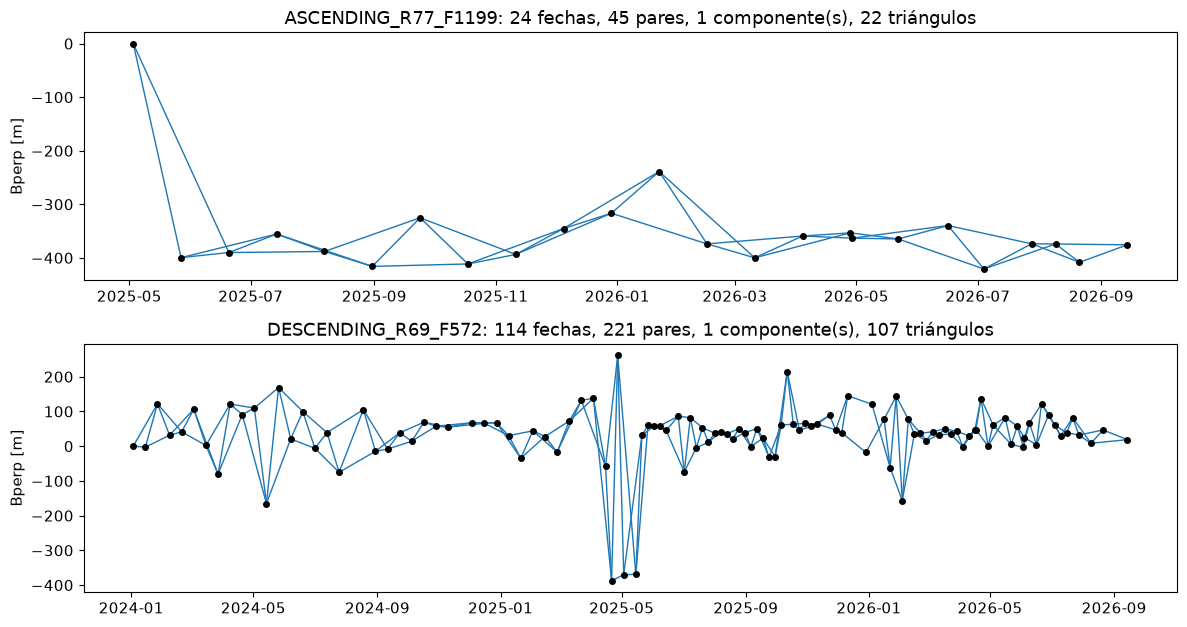

,n_fechas,n_pares,componentes,triangulos
suarez_2024_2026_v1_ASCENDING_R77_F1199,24,45,1,22
suarez_2024_2026_v1_DESCENDING_R69_F572,114,221,1,107


In [36]:
def analizar_red(tabla):
    fechas = sorted(set(tabla.fecha1) | set(tabla.fecha2))
    idx = {f: i for i, f in enumerate(fechas)}

    # Conectividad por conjuntos disjuntos (union-find)
    padre = list(range(len(fechas)))
    def raiz(i):
        while padre[i] != i:
            padre[i] = padre[padre[i]]
            i = padre[i]
        return i
    for a, b in zip(tabla.fecha1, tabla.fecha2):
        padre[raiz(idx[a])] = raiz(idx[b])
    n_comp = len({raiz(i) for i in range(len(fechas))})

    # Triángulos i->j, j->k, i->k
    aristas = {(idx[a], idx[b]) for a, b in zip(tabla.fecha1, tabla.fecha2)}
    n_tri = sum(1 for (i, j) in aristas for (j2, k) in aristas if j2 == j and (i, k) in aristas)

    # Bperp por fecha: B[sec] - B[ref] = Bperp_par, con B[primera fecha] = 0
    A = np.zeros((len(tabla), len(fechas)))
    for n, (a, b) in enumerate(zip(tabla.fecha1, tabla.fecha2)):
        A[n, idx[a]], A[n, idx[b]] = -1, 1
    sol = np.linalg.lstsq(A[:, 1:], tabla.bperp_m.fillna(0).to_numpy(), rcond=None)[0] if len(fechas) > 1 else []
    return fechas, n_comp, n_tri, np.r_[0, sol]


info_red = {}
fig, axes = plt.subplots(len(JOBS), 1, figsize=(12, 3.2 * len(JOBS)), squeeze=False)
for ax, job_name in zip(axes[:, 0], JOBS):
    tabla = insumos[job_name]
    fechas, n_comp, n_tri, bp = analizar_red(tabla)
    info_red[job_name] = {"n_fechas": len(fechas), "n_pares": len(tabla), "componentes": n_comp, "triangulos": n_tri}
    pos = dict(zip(fechas, bp))
    for a, b in zip(tabla.fecha1, tabla.fecha2):
        ax.plot([a, b], [pos[a], pos[b]], "-", color="#1f77b4", lw=1)
    ax.plot(fechas, bp, "o", color="k", ms=4)
    if FECHA_EVENTO:
        ax.axvline(FECHA_EVENTO, color="r", ls="--", lw=1)
    ax.set_title(f"{job_name.replace(RUN_ID + '_', '')}: {len(fechas)} fechas, {len(tabla)} pares, "
                 f"{n_comp} componente(s), {n_tri} triángulos")
    ax.set_ylabel("Bperp [m]")
plt.tight_layout()
fig.savefig(FIGURAS_DIR / "red_interferogramas.png", dpi=300, bbox_inches="tight")
plt.show()

display(pd.DataFrame(info_red).T)
for job, d in info_red.items():
    if d["componentes"] > 1:
        print(f"Advertencia: la red de {job} está dividida en {d['componentes']} partes.")

## 15. Corrección troposférica: credenciales del Copernicus Climate Data Store

**Ejecución:** siempre. La creación del archivo de credenciales se hace una sola vez (`CREAR_CDSAPIRC = True`); después se deja en `False`.

El vapor de agua de la troposfera retrasa la señal de radar y produce en los interferogramas patrones de fase que pueden confundirse con deformación. En zonas montañosas domina la componente estratificada, correlacionada con la altura del terreno, que en la cuenca es relevante por desniveles superiores a 2000 m. Esta componente se corrige con el reanálisis atmosférico ERA5 (Hersbach et al., 2020), a partir del cual PyAPS calcula el retardo para cada fecha y píxel (Jolivet et al., 2011). Si no hay acceso a ERA5, se usa el método empírico `height_correlation`, que estima la relación entre fase y elevación en cada fecha (Doin et al., 2009).

La descarga de ERA5 requiere una cuenta del Copernicus Climate Data Store (CDS), la aceptación de la licencia del conjunto de datos `reanalysis-era5-pressure-levels` y un archivo `~/.cdsapirc` con la dirección del servicio y el token personal. La celda:

- crea el archivo pidiendo el token con `getpass`, de modo que no queda escrito en el notebook;
- verifica con `revisar_cds()` que el archivo tenga el formato vigente del CDS;
- define `METODO_TROPO`: `pyaps` si las credenciales son válidas, `height_correlation` si no.

In [37]:
CDSRC = Path.home() / ".cdsapirc"
CREAR_CDSAPIRC = False   # True una sola vez para crear el archivo; luego volver a False

if CREAR_CDSAPIRC:
    token = getpass.getpass("Token personal del CDS: ").strip()
    if token.lower().startswith("key:"):
        token = token.split(":", 1)[1].strip()
    CDSRC.write_text(f"url: https://cds.climate.copernicus.eu/api\nkey: {token}\n")
    CDSRC.chmod(0o600)   # lectura solo para el usuario
    print("Archivo creado:", CDSRC)


def revisar_cds():
    if not CDSRC.exists():
        return False, "No existe ~/.cdsapirc"
    partes = CDSRC.read_text().split()
    if partes[:2] != ["url:", "https://cds.climate.copernicus.eu/api"]:
        return False, "Formato antiguo: la URL debe ser https://cds.climate.copernicus.eu/api"
    if len(partes) < 4 or partes[2] != "key:" or len(partes[3]) < 20:
        return False, "Falta el token en la línea 'key:'"
    return True, "OK"


cds_ok, cds_msg = revisar_cds()
METODO_TROPO = "pyaps" if cds_ok else "height_correlation"
print("Credenciales CDS:", cds_msg, "| método troposférico:", METODO_TROPO)

Credenciales CDS: OK | método troposférico: pyaps


## 16. Parámetros y archivos de configuración de MintPy

**Ejecución:** siempre, antes de ejecutar MintPy.

MintPy se configura con un archivo de texto por stack (`config.txt`) cuyas opciones tienen prioridad sobre la plantilla por defecto `smallbaselineApp.cfg`; las opciones no especificadas conservan sus valores por defecto (Yunjun et al., 2019). La función `construir_config(job_name)` escribe ese archivo en `02_mintpy/<stack>/` con las siguientes opciones:

| Opción | Valor | Justificación |
|---|---|---|
| `load.processor` | `hyp3` | Productos HyP3 GAMMA. MintPy convierte los ángulos del vector de mirada (`lv_theta`, `lv_phi`) en ángulo de incidencia y azimut. |
| `subset.lalo` | Rectángulo de la cuenca + 0.02° | Limita el procesamiento al área de estudio, lo que reduce el tiempo de cálculo y la memoria requerida. |
| `network.coherenceBased`, `minCoherence`, `keepMinSpanTree` | `yes`, 0.4, `yes` | Excluye los interferogramas de coherencia media inferior a 0.4, conservando el árbol de expansión mínima para que la red no se divida. El valor por defecto (0.7) es restrictivo en zonas con vegetación en banda C. |
| `reference.lalo`, `reference.minCoherence` | `auto` o `REF_LALO`; 0.5 | En modo automático se elige el píxel de mayor coherencia. El umbral se reduce de 0.85 a 0.5 porque en la cuenca pocos píxeles superan el valor por defecto. Para combinar geometrías ascendente y descendente se requiere el mismo punto en ambas. |
| `unwrapError.method` | `no` | Los métodos de corrección de MintPy (`bridging` y `phase_closure`) requieren las componentes conectadas del desenrollado, que los productos HyP3 GAMMA no incluyen. Los errores se detectan con los triángulos y se excluyen con la máscara de calidad. |
| `networkInversion.weightFunc` | `var` | Inversión por mínimos cuadrados ponderados con la varianza de la fase estimada a partir de la coherencia (Yunjun et al., 2019). |
| `solidEarthTides` | `yes` | Corrección de mareas terrestres con PySolid (Yunjun et al., 2022). |
| `troposphericDelay.method` | `pyaps` (ERA5) | Corrección troposférica (sección 15; Jolivet et al., 2011). |
| `deramp` | `no` | No se remueven rampas, porque en un área de este tamaño una rampa puede eliminar deformación real. |
| `topographicResidual` | `yes` | Corrección del error residual del modelo de elevación (Fattahi & Amelung, 2013). |
| `timeFunc.polynomial`, `timeFunc.periodic` | 1; 1.0 y 0.5 años | Tendencia lineal más componentes anual y semestral, por el régimen bimodal de lluvias de la región andina (Hetland et al., 2012). |
| `timeFunc.stepDate` | Fecha del evento o `no` | Función escalón en la fecha del evento, solo si esta cae dentro del periodo del stack; en caso contrario la matriz de diseño sería singular. |
| `compute.cluster`, `maxMemory` | `none`; 8 GB | Procesamiento en serie. El procesamiento paralelo con Dask no se inicia correctamente dentro del proceso externo en OpenScienceLab. |

In [89]:
REF_LALO = None            # (lat, lon) de un punto estable y coherente; None = automático
COH_RED_MIN = 0.4          # coherencia mínima de los interferogramas
USAR_SUBSET_CUENCA = True  
BUFFER_GRADOS = 0.02       
PERIODOS = "1.0,0.5"       # periodos estacionales en años
DERAMP = "no"              # "no" | "linear" | "quadratic"

w, s, e, n = geom.bounds
SUBSET_LALO = f"{s - BUFFER_GRADOS:.4f}:{n + BUFFER_GRADOS:.4f},{w - BUFFER_GRADOS:.4f}:{e + BUFFER_GRADOS:.4f}"
FECHA_EVENTO_MINTPY = FECHA_EVENTO.strftime("%Y%m%d") if FECHA_EVENTO else "no"


def construir_config(job_name):
    carpeta_clip = CLIP_DIR / job_name
    mintpy_dir = MINTPY_ROOT / job_name
    mintpy_dir.mkdir(parents=True, exist_ok=True)

    tabla = insumos[job_name]
    hay_evento = FECHA_EVENTO is not None and tabla.fecha1.min() < FECHA_EVENTO < tabla.fecha2.max()
    step = FECHA_EVENTO_MINTPY if hay_evento else "no"
    ref = f"{REF_LALO[0]},{REF_LALO[1]}" if REF_LALO else "auto"

    opciones = [
        ("## ---------- cómputo", None, None),
        ("mintpy.compute.cluster", "none", "procesamiento en serie"),
        ("mintpy.compute.maxMemory", 8, "GB por bloque"),
        ("## ---------- carga de datos HyP3", None, None),
        ("mintpy.load.processor", "hyp3", ""),
        ("mintpy.load.unwFile", f"{carpeta_clip}/*/*_unw_phase_clip.tif", "fase desenrollada (rad)"),
        ("mintpy.load.corFile", f"{carpeta_clip}/*/*_corr_clip.tif", "coherencia"),
        ("mintpy.load.demFile", f"{carpeta_clip}/*/*_dem_clip.tif", "elevación (m)"),
        ("mintpy.load.incAngleFile", f"{carpeta_clip}/*/*_lv_theta_clip.tif", "ángulo de incidencia"),
        ("mintpy.load.azAngleFile", f"{carpeta_clip}/*/*_lv_phi_clip.tif", "azimut de la línea de vista"),
        ("mintpy.load.waterMaskFile", f"{carpeta_clip}/*/*_water_mask_clip.tif", "máscara de agua"),
        ("mintpy.subset.lalo", SUBSET_LALO if USAR_SUBSET_CUENCA else "auto", "S:N,W:E"),
        ("## ---------- red y referencia", None, None),
        ("mintpy.network.coherenceBased", "yes", ""),
        ("mintpy.network.minCoherence", COH_RED_MIN, ""),
        ("mintpy.network.keepMinSpanTree", "yes", "no dividir la red"),
        ("mintpy.reference.lalo", ref, ""),
        ("mintpy.reference.minCoherence", 0.5, ""),
        ("## ---------- inversión", None, None),
        ("mintpy.unwrapError.method", "no", "HyP3 no incluye componentes conectadas"),
        ("mintpy.networkInversion.weightFunc", "var", ""),
        ("mintpy.networkInversion.minTempCoh", 0.7, ""),
        ("## ---------- correcciones", None, None),
        ("mintpy.solidEarthTides", "yes", "PySolid"),
        ("mintpy.troposphericDelay.method", METODO_TROPO, ""),
        ("mintpy.troposphericDelay.weatherModel", "ERA5", ""),
        ("mintpy.troposphericDelay.weatherDir", WEATHER_DIR, ""),
        ("mintpy.deramp", DERAMP, ""),
        ("mintpy.topographicResidual", "yes", ""),
        ("mintpy.topographicResidual.stepDate", step, ""),
        ("## ---------- modelo temporal y velocidad", None, None),
        ("mintpy.timeFunc.polynomial", 1, "tendencia lineal"),
        ("mintpy.timeFunc.periodic", PERIODOS, "anual y semestral"),
        ("mintpy.timeFunc.stepDate", step, "escalón del evento"),
        ("## ---------- salidas", None, None),
        ("mintpy.save.kmz", "yes", "Google Earth"),
        ("mintpy.plot", "yes", "figuras en pic/"),
    ]

    lineas = [f"# Configuración MintPy: {job_name} ({time.strftime('%Y-%m-%d %H:%M')})"]
    for clave, valor, comentario in opciones:
        if valor is None:
            lineas.append("\n" + clave)
        else:
            lineas.append(f"{clave:<42} = {valor}" + (f"   # {comentario}" if comentario else ""))
    ruta = mintpy_dir / "config.txt"
    ruta.write_text("\n".join(lineas) + "\n", encoding="utf-8")
    return ruta


print("Rectángulo de procesamiento (S:N,W:E):", SUBSET_LALO, "| escalón:", FECHA_EVENTO_MINTPY)
for job_name in JOBS:
    print("Configuración escrita:", construir_config(job_name))
print("\nEjemplo:\n" + (MINTPY_ROOT / JOBS[0] / "config.txt").read_text())

Rectángulo de procesamiento (S:N,W:E): 5.3831:6.8104,-73.8807:-73.0501 | escalón: no
Configuración escrita: /home/jovyan/Tesis_InSAR_Rio_Suarez/02_mintpy/suarez_2024_2026_v1_ASCENDING_R77_F1199/config.txt
Configuración escrita: /home/jovyan/Tesis_InSAR_Rio_Suarez/02_mintpy/suarez_2024_2026_v1_DESCENDING_R69_F572/config.txt

Ejemplo:
# Configuración MintPy: suarez_2024_2026_v1_ASCENDING_R77_F1199 (2026-09-30 03:17)

## ---------- cómputo
mintpy.compute.cluster                     = none   # procesamiento en serie
mintpy.compute.maxMemory                   = 8   # GB por bloque

## ---------- carga de datos HyP3
mintpy.load.processor                      = hyp3
mintpy.load.unwFile                        = /home/jovyan/Tesis_InSAR_Rio_Suarez/01_datos/hyp3/recortados/suarez_2024_2026_v1_ASCENDING_R77_F1199/*/*_unw_phase_clip.tif   # fase desenrollada (rad)
mintpy.load.corFile                        = /home/jovyan/Tesis_InSAR_Rio_Suarez/01_datos/hyp3/recortados/suarez_2024_2026_v1_ASCENDING

# Ejecución de MintPy

MintPy trabaja en modo de actualización: antes de cada paso verifica si sus resultados ya existen, si son más recientes que sus datos de entrada y si las opciones de configuración correspondientes no cambiaron; en ese caso omite el paso (Yunjun et al., 2019). Por ello, las celdas de esta parte pueden ejecutarse de nuevo sin repetir el procesamiento, y si se modifica una opción en la sección 16 solo se recalculan los pasos que dependen de ella.

El procesamiento se divide en dos bloques, con una revisión de calidad entre ellos, como en los ejercicios del curso *InSAR Processing and Analysis* (EarthScope Consortium, 2026). El avance puede seguirse en una terminal con `tail -f ~/Tesis_InSAR_Rio_Suarez/02_mintpy/<stack>/log_mintpy.txt`.

## 17. Bloque A: carga de datos, red y punto de referencia

**Ejecución:** siempre. La primera vez tarda varios minutos por stack; después, MintPy omite lo ya calculado.

Para cada stack se ejecuta `smallbaselineApp.py config.txt --start load_data --end quick_overview`, que comprende los siguientes pasos:

| Paso | Resultado |
|---|---|
| `load_data` | Carga los interferogramas y la geometría en `inputs/ifgramStack.h5` (fase desenrollada, coherencia, fechas y líneas base) e `inputs/geometryGeo.h5` (elevación, ángulos de incidencia y azimut, máscara de agua), recortados al rectángulo de la cuenca. |
| `modify_network` | Marca como excluidos (`dropIfgram`) los interferogramas con coherencia media inferior al umbral, sin dividir la red. |
| `reference_point` | Selecciona el punto de referencia espacial al que se refieren todos los desplazamientos (atributos `REF_LAT`, `REF_LON`). |
| `quick_overview` | Calcula la coherencia espacial promedio (`avgSpatialCoh.h5`) y el número de triángulos con error de desenrollado por píxel (`numTriNonzeroIntAmbiguity.h5`). |

Si el bloque falla, se reintenta una vez. Esto resuelve un error conocido de MintPy: cuando ningún píxel presenta errores de desenrollado, la gráfica del histograma de `quick_overview` falla después de haber guardado el resultado, y al repetir el paso este se omite.

In [39]:
estado_mintpy = {}
for job_name in tqdm(JOBS, desc="MintPy bloque A", bar_format=BARRA_FORMATO):
    args = ["config.txt", "--start", "load_data", "--end", "quick_overview"]
    rc = ejecutar_mintpy("smallbaselineApp", args, cwd=MINTPY_ROOT / job_name, check=False)
    if rc != 0:
        print("Reintentando:", job_name)
        rc = ejecutar_mintpy("smallbaselineApp", args, cwd=MINTPY_ROOT / job_name, check=False)
    estado_mintpy[job_name] = "A_ok" if rc == 0 else "A_error"

display(pd.Series(estado_mintpy, name="estado"))

MintPy bloque A   0% |                                   | 0/2 [00:00<?]

suarez_2024_2026_v1_ASCENDING_R77_F1199    A_ok
suarez_2024_2026_v1_DESCENDING_R69_F572    A_ok
Name: estado, dtype: str

## 18. Revisión de la red y de la coherencia antes de la inversión

**Ejecución:** siempre.

Antes de invertir la red se revisa la calidad de los datos de cada stack mediante tres gráficas:

1. **Coherencia media de cada interferograma frente a su línea base temporal**, diferenciando los usados y los excluidos por el filtro de coherencia. En banda C la coherencia disminuye con el tiempo transcurrido entre imágenes, sobre todo en zonas con vegetación.
2. **Coherencia espacial promedio** (`avgSpatialCoh`), con el límite de la cuenca, el evento y el punto de referencia. Los valores altos corresponden a superficies estables, como zonas urbanas y roca expuesta; los bajos, a vegetación densa y cuerpos de agua.
3. **Número de triángulos con error de desenrollado** (*T_int*; `numTriNonzeroIntAmbiguity`). Los píxeles con valores mayores que cero presentan errores de desenrollado de fase (Yunjun et al., 2019).

Estas revisiones siguen las secciones de red, máscaras de calidad y errores de desenrollado del curso *InSAR Processing and Analysis* (EarthScope Consortium, 2026). Las figuras se guardan en `03_resultados/figuras/`.

Funciones definidas, que también se usan en la presentación de resultados:

| Función | Descripción |
|---|---|
| `leer_h5(archivo, dataset)` | Lee un conjunto de datos de un archivo HDF5 de MintPy y sus atributos (Collette, 2013). |
| `fechas_h5(arreglo)` | Convierte las fechas guardadas en HDF5 a texto de Python, requerido por pandas 3. |
| `georef(attrs)` | Obtiene la transformación geográfica y el código EPSG a partir de los atributos de MintPy. |
| `extent(attrs)` | Calcula la extensión del mapa para graficarlo en coordenadas. |
| `dibujar_contexto(ax, epsg, attrs)` | Dibuja la cuenca, el evento y el punto de referencia sobre un mapa. |

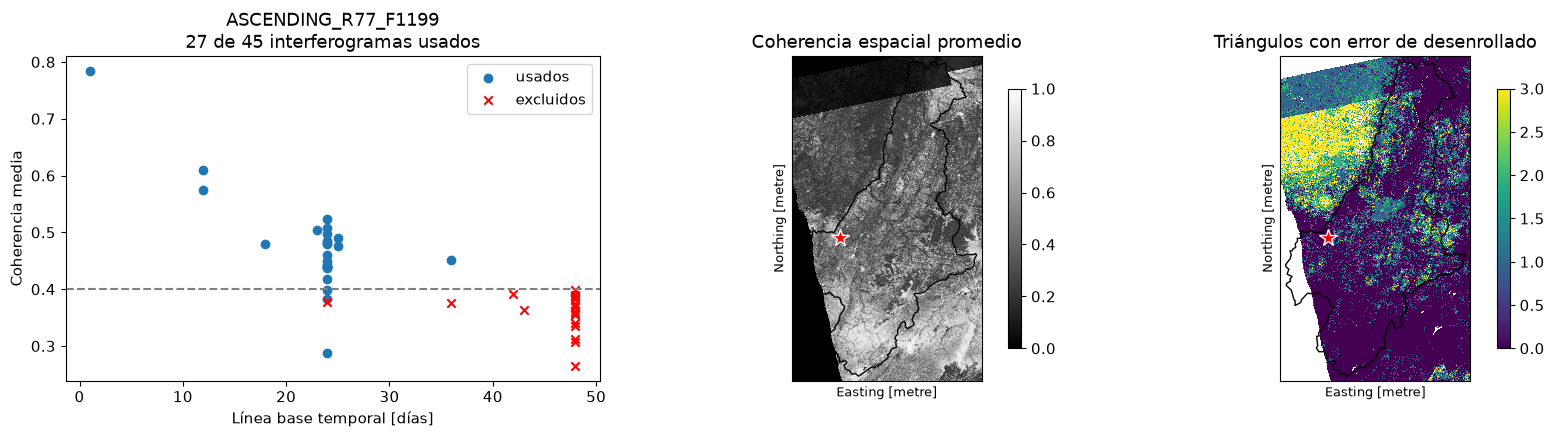

ASCENDING_R77_F1199: punto de referencia en lat 615360.0, lon 643440.0


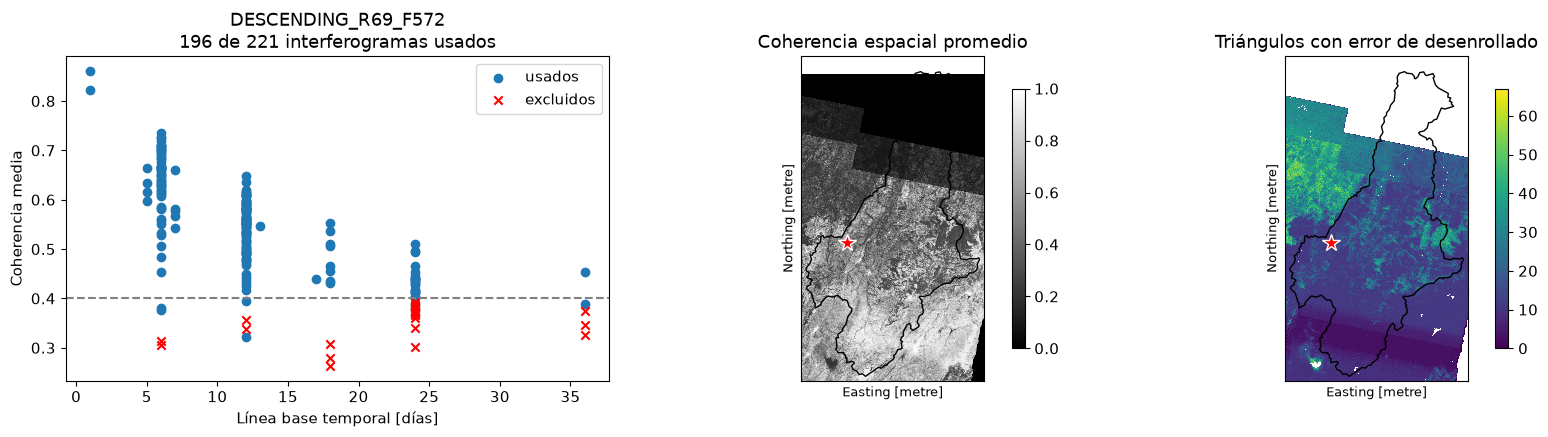

DESCENDING_R69_F572: punto de referencia en lat 609200.0, lon 709200.0


In [90]:
def leer_h5(archivo, dataset=None, indice=None):
    with h5py.File(archivo, "r") as f:
        dataset = dataset or list(f.keys())[0]
        d = f[dataset]
        datos = d[indice] if indice is not None else d[()]
        attrs = {k: (v.decode() if isinstance(v, bytes) else str(v)) for k, v in f.attrs.items()}
    return datos, attrs


def fechas_h5(arreglo):
    return [str(x.decode() if isinstance(x, bytes) else x) for x in arreglo]


def georef(attrs):
    transform = from_origin(float(attrs["X_FIRST"]), float(attrs["Y_FIRST"]),
                            float(attrs["X_STEP"]), -float(attrs["Y_STEP"]))
    if attrs.get("EPSG") not in (None, "None", ""):
        epsg = int(attrs["EPSG"])
    elif "UTM_ZONE" in attrs:
        z = attrs["UTM_ZONE"]
        epsg = (32600 if z[-1].upper() == "N" else 32700) + int(re.sub(r"\D", "", z))
    else:
        epsg = 4326
    return transform, epsg


def extent(attrs):
    t, _ = georef(attrs)
    L, W = int(attrs["LENGTH"]), int(attrs["WIDTH"])
    return [t.c, t.c + W * t.a, t.f + L * t.e, t.f]


def dibujar_contexto(ax, epsg, attrs=None):
    gdf_cuenca.to_crs(epsg).boundary.plot(ax=ax, color="k", lw=1)
    ev = gpd.GeoSeries([PUNTO_EVENTO], crs=4326).to_crs(epsg).iloc[0]
    ax.plot(ev.x, ev.y, "r*", ms=13, mec="w")
    if attrs and "REF_LAT" in attrs:
        ref = gpd.GeoSeries([Point(float(attrs["REF_LON"]), float(attrs["REF_LAT"]))], crs=4326).to_crs(epsg).iloc[0]
        ax.plot(ref.x, ref.y, "ks", ms=8, mfc="yellow")
    ax.set_xticks([]); ax.set_yticks([])


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    stack = d / "inputs" / "ifgramStack.h5"
    if not stack.exists():
        print("Sin ifgramStack.h5:", job_name)
        continue

    with h5py.File(stack, "r") as f:
        fechas = [fechas_h5(par) for par in f["date"][()]]
        drop = f["dropIfgram"][()]
        coh_media = np.array([np.nanmean(np.where(f["coherence"][i] > 0, f["coherence"][i], np.nan))
                              for i in range(f["coherence"].shape[0])])
    btemp = np.array([(pd.Timestamp(b) - pd.Timestamp(a)).days for a, b in fechas])
    at_stack = leer_h5(stack, "dropIfgram")[1]
    nombre = job_name.replace(RUN_ID + "_", "")

    paneles = [p for p in ["avgSpatialCoh.h5", "numTriNonzeroIntAmbiguity.h5"] if (d / p).exists()]
    fig, axes = plt.subplots(1, 1 + len(paneles), figsize=(6 + 5 * len(paneles), 4.5))
    axes = np.atleast_1d(axes)
    axes[0].scatter(btemp[drop], coh_media[drop], c="C0", label="usados")
    axes[0].scatter(btemp[~drop], coh_media[~drop], c="r", marker="x", label="excluidos")
    axes[0].axhline(COH_RED_MIN, color="gray", ls="--")
    axes[0].set(xlabel="Línea base temporal [días]", ylabel="Coherencia media",
                title=f"{nombre}\n{drop.sum()} de {len(drop)} interferogramas usados")
    axes[0].legend()
    for ax, p in zip(axes[1:], paneles):
        data, at = leer_h5(d / p)
        _, epsg = georef(at)
        im = ax.imshow(data, extent=extent(at), cmap="gray" if "Coh" in p else "viridis",
                       vmin=0, vmax=1 if "Coh" in p else None, interpolation="nearest")
        dibujar_contexto(ax, epsg, at_stack)
        ax.set_title("Coherencia espacial promedio" if "Coh" in p else "Triángulos con error de desenrollado")
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    fig.savefig(FIGURAS_DIR / f"calidad_red_{nombre}.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"{nombre}: punto de referencia en lat {at_stack.get('REF_LAT', '?')}, lon {at_stack.get('REF_LON', '?')}")

## 19. Bloque B: inversión, correcciones y velocidad

**Ejecución:** siempre. La primera vez puede tardar varias horas, principalmente por la descarga de los datos ERA5; después se usa la copia local en `02_mintpy/ERA5/`.

Para cada stack se ejecuta `smallbaselineApp.py config.txt --start correct_unwrap_error`, que completa el procesamiento:

| Paso | Resultado |
|---|---|
| `invert_network` | Inversión de la red por mínimos cuadrados ponderados: serie temporal de desplazamiento (`timeseries.h5`) y coherencia temporal (`temporalCoherence.h5`), que mide la consistencia de cada píxel con la red (Pepe & Lanari, 2006; Yunjun et al., 2019). |
| `correct_SET` | Corrección de mareas terrestres (Yunjun et al., 2022); sufijo `_SET`. |
| `correct_troposphere` | Corrección del retardo troposférico con ERA5 (Jolivet et al., 2011); sufijo `_ERA5`. |
| `correct_topography` | Corrección del error residual del modelo de elevación (Fattahi & Amelung, 2013); sufijo `_demErr`. |
| `residual_RMS`, `reference_date` | Identificación de fechas con ruido anómalo y selección de la fecha de referencia temporal. |
| `velocity` | Ajuste del modelo temporal (tendencia lineal y componentes estacionales) y cálculo de la velocidad y su desviación estándar (`velocity.h5`). |
| `google_earth` | Exportación de la velocidad a formato KMZ. |

La corrección de errores de desenrollado (`correct_unwrap_error`) se omite porque los productos HyP3 no incluyen componentes conectadas (sección 16). Si un stack falla, el proceso continúa con el siguiente y el error queda en su registro.

In [41]:
for job_name in tqdm(JOBS, desc="MintPy bloque B", bar_format=BARRA_FORMATO):
    if estado_mintpy.get(job_name) == "A_error":
        print("Se omite (falló el bloque A):", job_name)
        continue
    rc = ejecutar_mintpy("smallbaselineApp", ["config.txt", "--start", "correct_unwrap_error"],
                         cwd=MINTPY_ROOT / job_name, check=False)
    estado_mintpy[job_name] = "B_ok" if rc == 0 else "B_error"

display(pd.Series(estado_mintpy, name="estado"))

MintPy bloque B   0% |                                   | 0/2 [00:00<?]

suarez_2024_2026_v1_ASCENDING_R77_F1199    B_ok
suarez_2024_2026_v1_DESCENDING_R69_F572    B_ok
Name: estado, dtype: str

# Resultados

**Convención de signos.** Siguiendo la convención de MintPy, los valores positivos indican que el terreno se acerca al satélite y los negativos que se aleja de él, a lo largo de la línea de vista (LOS). Según la geometría de observación, un alejamiento puede corresponder a hundimiento o a movimiento ladera abajo. Las velocidades se expresan en milímetros por año y son relativas al punto de referencia espacial (Yunjun et al., 2019; EarthScope Consortium, 2026).

**Áreas sin dato.** Los píxeles en blanco de los mapas fueron excluidos por baja coherencia (vegetación densa y cambios en la cobertura del suelo, que en banda C alteran la señal entre adquisiciones), por distorsiones geométricas en pendientes fuertes (inversión por relieve y sombra de radar), por errores de desenrollado o por corresponder a cuerpos de agua. Además, el sector norte de la cuenca queda fuera de la cobertura del stack descendente.

## 20. Serie temporal final y máscara de confiabilidad

**Ejecución:** siempre.

MintPy guarda un archivo de serie temporal por cada corrección aplicada y añade un sufijo al nombre: `_SET` (mareas terrestres), `_ERA5` (troposfera) y `_demErr` (error del modelo de elevación). La función `serie_final()` identifica la serie con todas las correcciones, que en este estudio es `timeseries_SET_ERA5_demErr.h5`.

La función `mascara_confiable()` define los píxeles que se usan en el análisis mediante tres criterios:

| Criterio | Umbral | Justificación |
|---|---|---|
| Coherencia temporal | ≥ 0.7 (`maskTempCoh.h5`) | Mide la consistencia entre la serie temporal estimada y los interferogramas; valores bajos indican ruido o errores de desenrollado (Pepe & Lanari, 2006; Yunjun et al., 2019). |
| Coherencia espacial promedio | ≥ `COH_ESPACIAL_MIN` = 0.3 | Excluye píxeles de baja calidad de fase en la mayoría de los interferogramas. |
| Máscara de agua | Tierra firme | Excluye cuerpos de agua, donde la fase no representa deformación. |

La combinación de las dos coherencias sigue el análisis de calidad del curso *InSAR Processing and Analysis* (EarthScope Consortium, 2026). Aumentar `COH_ESPACIAL_MIN` a 0.4 o 0.5 reduce el ruido a costa de la cobertura.

In [91]:
COH_ESPACIAL_MIN = 0.3  


def serie_final(mintpy_dir):
    """Serie temporal con la cadena de correcciones más larga (excluye los archivos de residuos)."""
    candidatos = [p for p in Path(mintpy_dir).glob("timeseries*.h5") if "Residual" not in p.name]
    if not candidatos:
        raise FileNotFoundError(f"No hay archivos timeseries*.h5 en {mintpy_dir}")
    return max(candidatos, key=lambda p: len(p.stem))


def mascara_confiable(mintpy_dir):
    """Máscara booleana: coherencia temporal >= 0.7, coherencia espacial >= COH_ESPACIAL_MIN y tierra firme."""
    d = Path(mintpy_dir)
    m = leer_h5(d / "maskTempCoh.h5")[0].astype(bool)
    if (d / "avgSpatialCoh.h5").exists():
        m &= leer_h5(d / "avgSpatialCoh.h5")[0] >= COH_ESPACIAL_MIN
    with h5py.File(d / "inputs" / "geometryGeo.h5", "r") as f:
        if "waterMask" in f:
            m &= f["waterMask"][()].astype(bool)
    return m


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        print(f"{job_name}: sin velocity.h5 (revise el registro)")
        continue
    m = mascara_confiable(d)
    print(f"{job_name.replace(RUN_ID + '_', '')}: serie final = {serie_final(d).name} | "
          f"píxeles confiables = {100 * m.mean():.1f} %")

ASCENDING_R77_F1199: serie final = timeseries_SET_ERA5_demErr.h5 | píxeles confiables = 58.2 %
DESCENDING_R69_F572: serie final = timeseries_SET_ERA5_demErr.h5 | píxeles confiables = 44.1 %


## 21. Mapas de velocidad en la línea de vista e incertidumbre

**Ejecución:** siempre.

Para cada stack se grafican:

- **Velocidad LOS** (`velocity`, mm/año): pendiente de la tendencia lineal del modelo temporal ajustado a la serie de cada píxel (Yunjun et al., 2019). La escala de colores es simétrica respecto de cero y se limita a los percentiles 2 y 98 de los valores absolutos, para que unos pocos valores extremos no saturen el mapa.
- **Incertidumbre** (`velocityStd`, mm/año): desviación estándar de la velocidad estimada a partir de los residuos del ajuste. Refleja qué tan bien se ajusta el modelo temporal a la serie, aumenta con la distancia al punto de referencia porque el ruido atmosférico residual está correlacionado espacialmente, y puede subestimar la incertidumbre real, ya que no incluye ese ruido de forma explícita (EarthScope Consortium, 2026).

Sobre los mapas se dibujan el límite de la cuenca, el evento (estrella) y el punto de referencia (cuadro amarillo). Las figuras se guardan en `03_resultados/figuras/`.

Función definida: `lim_simetrico(arr, p)`, que calcula el límite simétrico de la escala de colores a partir del percentil `p` del valor absoluto.

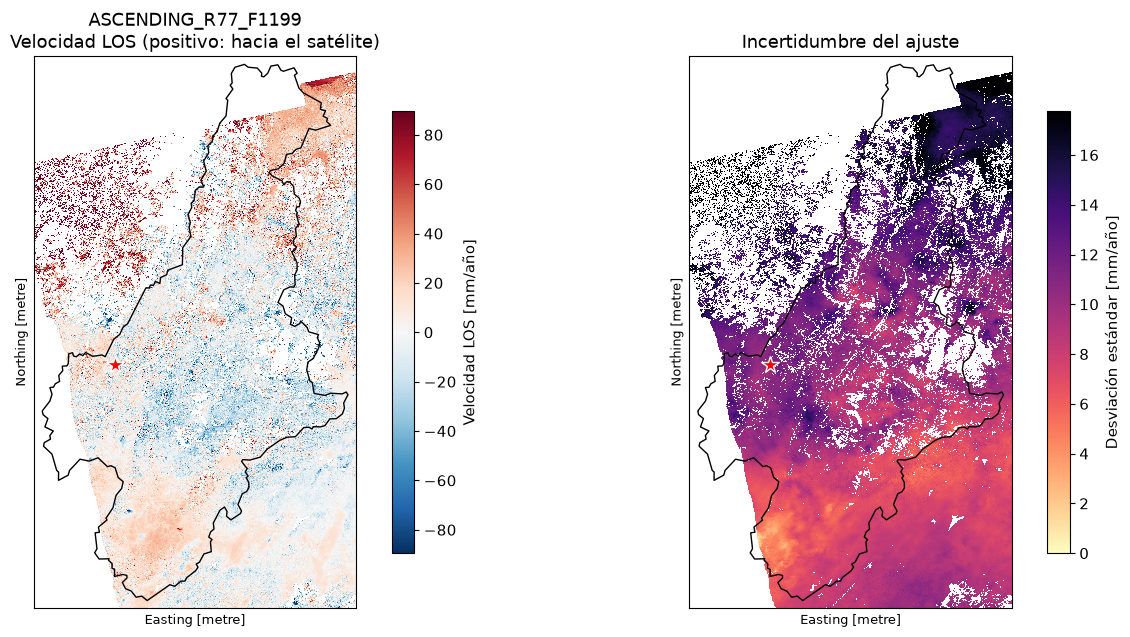

ASCENDING_R77_F1199: mediana 2.5 mm/año | percentiles 2-98: -50.5 a 84.7 mm/año


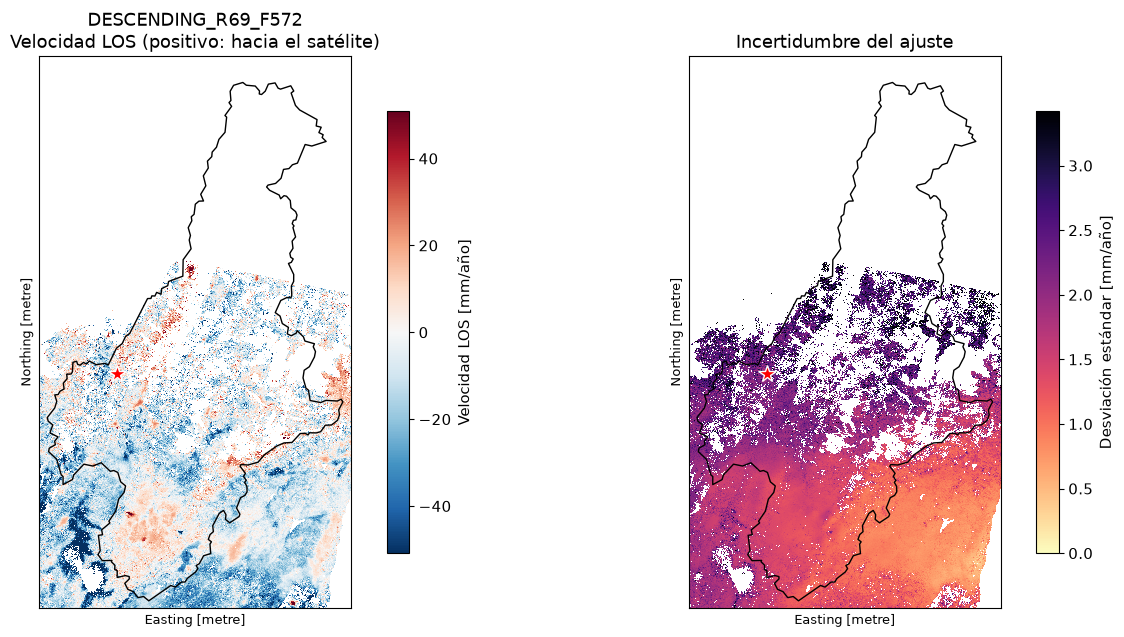

DESCENDING_R69_F572: mediana -7.0 mm/año | percentiles 2-98: -50.2 a 22.2 mm/año


In [43]:
def lim_simetrico(arr, p=98):
    """Límite simétrico de la escala de colores a partir del percentil p de |arr|."""
    v = np.nanpercentile(np.abs(arr), p)
    return float(v) if np.isfinite(v) and v > 0 else 1.0


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    nombre = job_name.replace(RUN_ID + "_", "")
    vel, at = leer_h5(d / "velocity.h5", "velocity")
    std, _ = leer_h5(d / "velocity.h5", "velocityStd")
    _, epsg = georef(at)
    m = mascara_confiable(d)
    vel_mm, std_mm = np.where(m, vel * 1000, np.nan), np.where(m, std * 1000, np.nan)
    vlim = lim_simetrico(vel_mm)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
    im0 = axes[0].imshow(vel_mm, extent=extent(at), cmap="RdBu_r", vmin=-vlim, vmax=vlim, interpolation="nearest")
    im1 = axes[1].imshow(std_mm, extent=extent(at), cmap="magma_r", vmin=0,
                         vmax=np.nanpercentile(std_mm, 98), interpolation="nearest")
    for ax in axes:
        dibujar_contexto(ax, epsg, at)
    plt.colorbar(im0, ax=axes[0], shrink=0.8, label="Velocidad LOS [mm/año]")
    plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Desviación estándar [mm/año]")
    axes[0].set_title(f"{nombre}\nVelocidad LOS (positivo: hacia el satélite)")
    axes[1].set_title("Incertidumbre del ajuste")
    plt.tight_layout()
    fig.savefig(FIGURAS_DIR / f"velocidad_{nombre}.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"{nombre}: mediana {np.nanmedian(vel_mm):.1f} mm/año | percentiles 2-98: "
          f"{np.nanpercentile(vel_mm, 2):.1f} a {np.nanpercentile(vel_mm, 98):.1f} mm/año")

## 22. Componentes estacionales y escalón del evento

**Ejecución:** siempre.

Además de la tendencia lineal, el modelo temporal ajustado por MintPy incluye funciones periódicas y, si se definió la fecha del evento, una función escalón (Hetland et al., 2012):

- **Amplitud anual y semestral** (`annualAmplitude`, `semiAnnualAmplitude`, en cm): magnitud de las oscilaciones de periodo 1 año y 0.5 años. La componente semestral es relevante en la región andina por su régimen bimodal de lluvias, con dos temporadas lluviosas al año, que puede inducir variaciones estacionales en la humedad del suelo y en el movimiento de laderas.
- **Escalón** (`step<AAAAMMDD>`, en cm): desplazamiento súbito en la fecha del evento, separado de la tendencia lineal. Solo existe si `FECHA_EVENTO` está definida y cae dentro del periodo del stack.

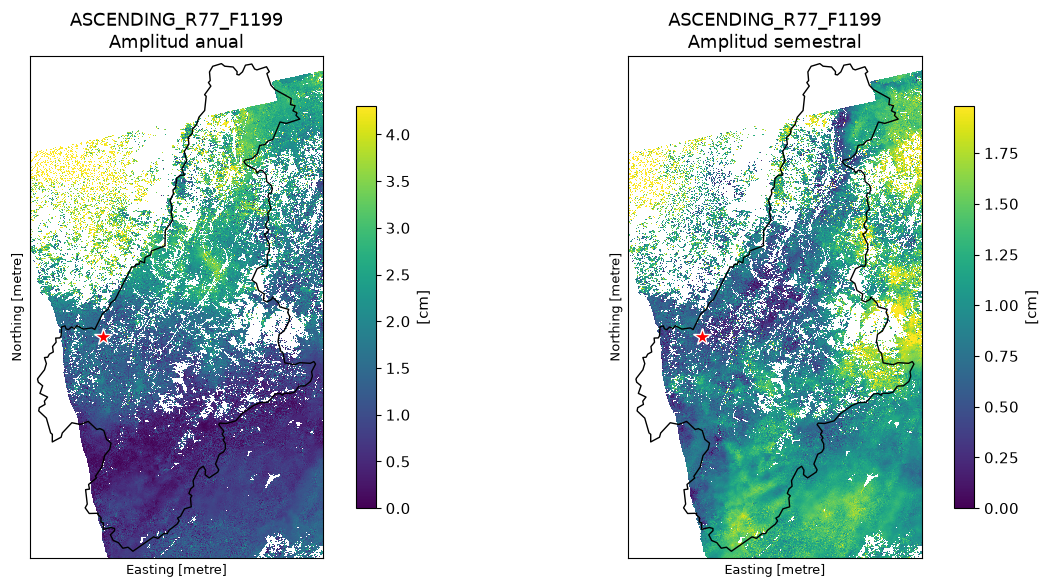

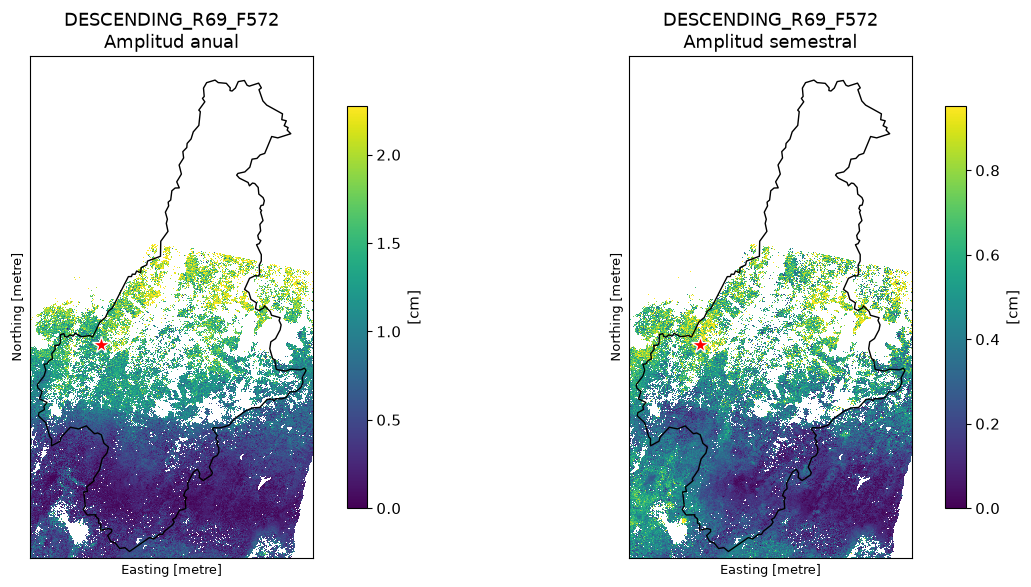

In [44]:
for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    nombre = job_name.replace(RUN_ID + "_", "")
    with h5py.File(d / "velocity.h5", "r") as f:
        claves = [k for k in f.keys() if (k.startswith("step") and not k.endswith("Std"))
                  or k in ("annualAmplitude", "semiAnnualAmplitude")]
    if not claves:
        print(f"{nombre}: sin componentes estacionales ni escalón.")
        continue

    titulos = {"annualAmplitude": "Amplitud anual", "semiAnnualAmplitude": "Amplitud semestral"}
    m = mascara_confiable(d)
    fig, axes = plt.subplots(1, len(claves), figsize=(6.5 * len(claves), 6), squeeze=False)
    for ax, k in zip(axes[0], claves):
        data, at = leer_h5(d / "velocity.h5", k)
        _, epsg = georef(at)
        data_cm = np.where(m, data * 100, np.nan)
        if k.startswith("step"):
            vlim = lim_simetrico(data_cm)
            im = ax.imshow(data_cm, extent=extent(at), cmap="RdBu_r", vmin=-vlim, vmax=vlim, interpolation="nearest")
        else:
            im = ax.imshow(data_cm, extent=extent(at), cmap="viridis", vmin=0,
                           vmax=np.nanpercentile(data_cm, 98), interpolation="nearest")
        dibujar_contexto(ax, epsg, at)
        plt.colorbar(im, ax=ax, shrink=0.8, label="[cm]")
        ax.set_title(f"{nombre}\n{titulos.get(k, 'Escalón ' + k[4:])}")
    plt.tight_layout()
    fig.savefig(FIGURAS_DIR / f"estacionalidad_{nombre}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 23. Series temporales en puntos de interés

**Ejecución:** siempre. Los puntos se agregan en el diccionario `PUNTOS` como `"nombre": (latitud, longitud)`.

Para cada punto se extrae el desplazamiento LOS de la serie temporal final, promediando una ventana de 3 × 3 píxeles (unos 240 m de lado) que incluye solo los píxeles confiables. El promedio reduce el ruido de un píxel individual sin mezclar señales de sectores distintos. El desplazamiento se expresa en centímetros respecto de la primera fecha.

Una tendencia sostenida en el tiempo indica deformación; oscilaciones sin tendencia son atribuibles a ruido atmosférico residual. La extracción de series en puntos corresponde a la herramienta `tsview.py` de MintPy (EarthScope Consortium, 2026). La conversión de coordenadas geográficas a la proyección del producto se hace con `pyproj` (Snow et al., 2024).

Función definida: `serie_en_punto(mintpy_dir, lat, lon, ventana)`, que devuelve las fechas y el desplazamiento promedio de la ventana, o nada si el punto queda fuera del área o sin píxeles confiables.


----------------------------------------------------------------------
GNSS CHRL  (6.2875, -73.1565)
  ASCENDING_R77_F1199: 24 imágenes | cada 24 días (mín 1.0, máx 25.0) | tendencia -1.4 mm/año | dispersión alrededor de la tendencia ±2.58 cm
  DESCENDING_R69_F572: fuera del área o sin píxeles confiables


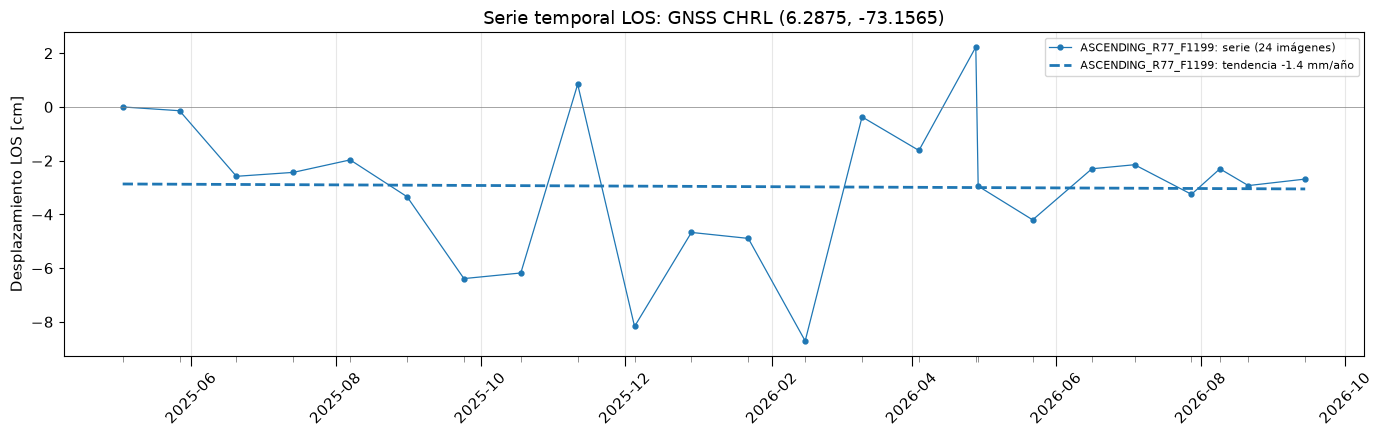


----------------------------------------------------------------------
GNSS PATU  (5.7465, -73.1257)
  ASCENDING_R77_F1199: 24 imágenes | cada 24 días (mín 1.0, máx 25.0) | tendencia -28.0 mm/año | dispersión alrededor de la tendencia ±1.60 cm
  DESCENDING_R69_F572: 114 imágenes | cada 6 días (mín 1.0, máx 24.0) | tendencia -30.8 mm/año | dispersión alrededor de la tendencia ±0.91 cm


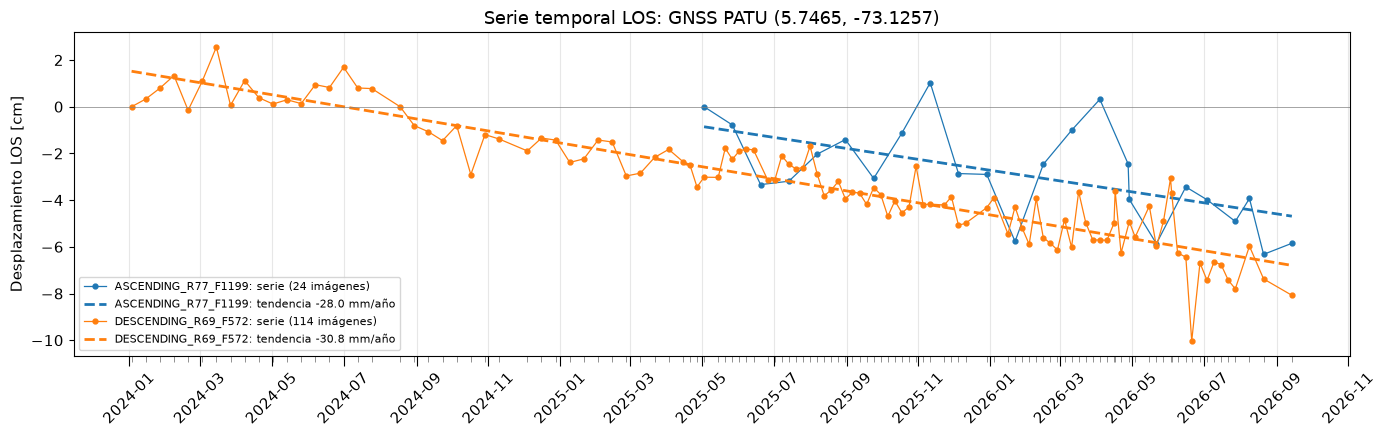


----------------------------------------------------------------------
GNSS SUAM  (5.7099, -72.9247)
  ASCENDING_R77_F1199: fuera del área o sin píxeles confiables
  DESCENDING_R69_F572: fuera del área o sin píxeles confiables
  Sin datos InSAR en ningún stack: no se genera gráfica.

----------------------------------------------------------------------
GNSS VMES  (6.8833, -73.0917)
  ASCENDING_R77_F1199: fuera del área o sin píxeles confiables
  DESCENDING_R69_F572: fuera del área o sin píxeles confiables
  Sin datos InSAR en ningún stack: no se genera gráfica.

----------------------------------------------------------------------
GNSS VELZ (inactiva)  (5.9571, -73.6466)
  ASCENDING_R77_F1199: 24 imágenes | cada 24 días (mín 1.0, máx 25.0) | tendencia +10.0 mm/año | dispersión alrededor de la tendencia ±2.02 cm
  DESCENDING_R69_F572: 114 imágenes | cada 6 días (mín 1.0, máx 24.0) | tendencia +0.7 mm/año | dispersión alrededor de la tendencia ±1.89 cm


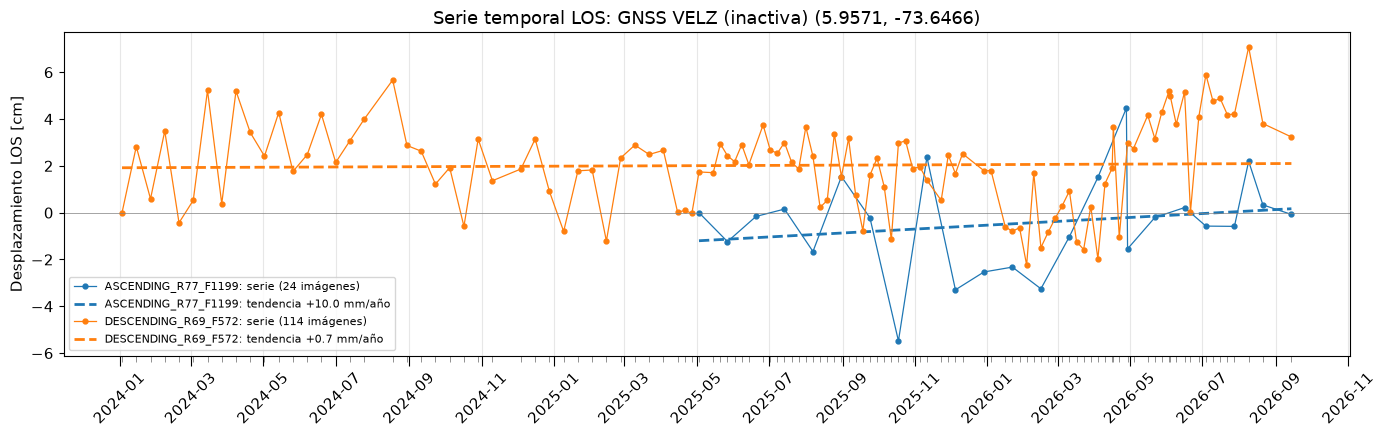


----------------------------------------------------------------------
GNSS FLRN  (5.8078, -73.9720)
  ASCENDING_R77_F1199: fuera del área o sin píxeles confiables
  DESCENDING_R69_F572: fuera del área o sin píxeles confiables
  Sin datos InSAR en ningún stack: no se genera gráfica.

----------------------------------------------------------------------
GNSS VBUV  (5.5332, -73.8589)
  ASCENDING_R77_F1199: fuera del área o sin píxeles confiables
  DESCENDING_R69_F572: 114 imágenes | cada 6 días (mín 1.0, máx 24.0) | tendencia -8.5 mm/año | dispersión alrededor de la tendencia ±1.36 cm


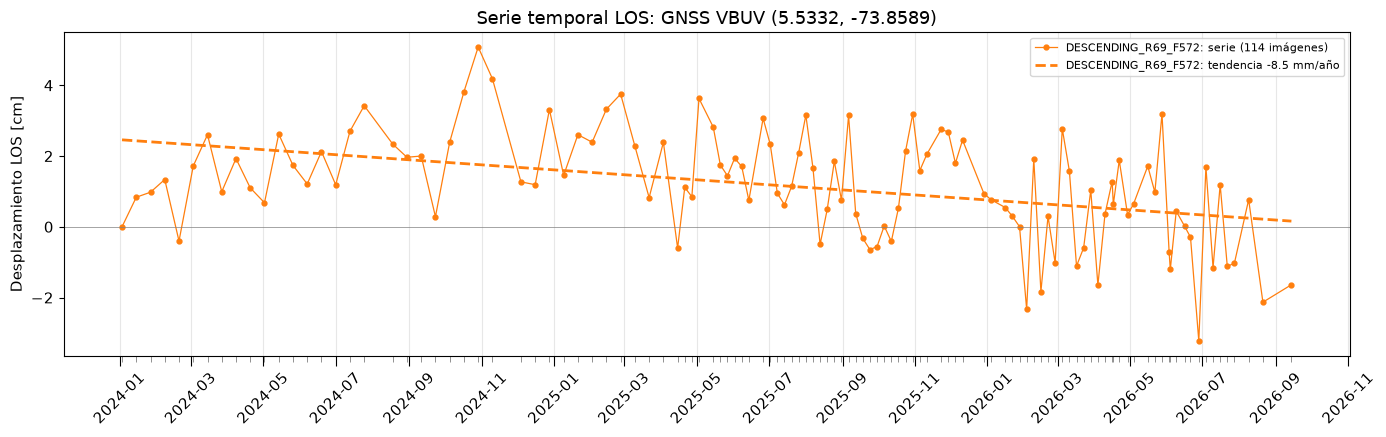


----------------------------------------------------------------------
GNSS TUNA  (5.5313, -73.3639)
  ASCENDING_R77_F1199: 24 imágenes | cada 24 días (mín 1.0, máx 25.0) | tendencia +16.4 mm/año | dispersión alrededor de la tendencia ±1.84 cm
  DESCENDING_R69_F572: 114 imágenes | cada 6 días (mín 1.0, máx 24.0) | tendencia +17.7 mm/año | dispersión alrededor de la tendencia ±0.75 cm


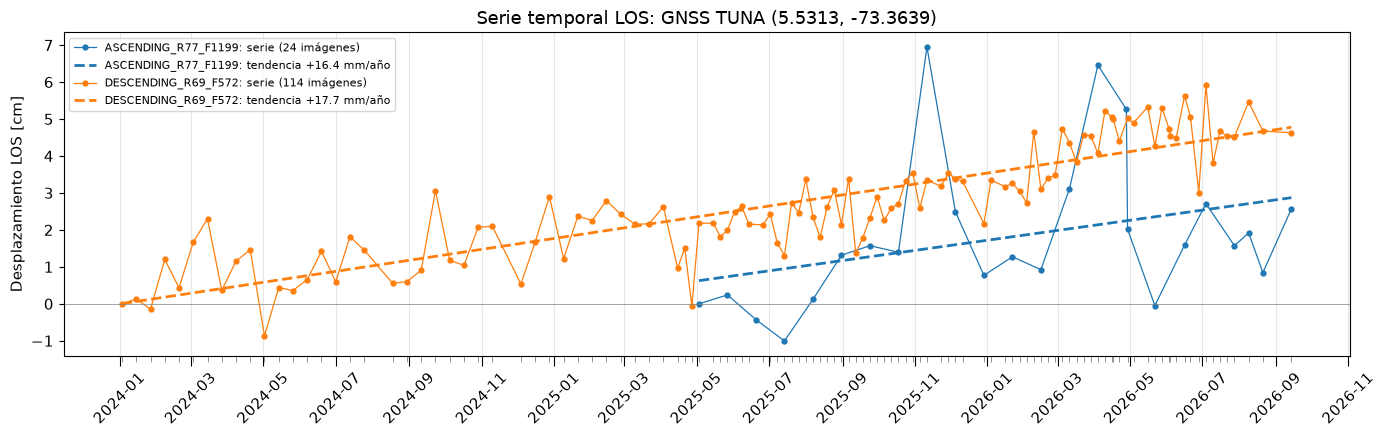


----------------------------------------------------------------------
GNSS AGTU (inactiva)  (5.5199, -73.3737)
  ASCENDING_R77_F1199: 24 imágenes | cada 24 días (mín 1.0, máx 25.0) | tendencia +13.9 mm/año | dispersión alrededor de la tendencia ±1.91 cm
  DESCENDING_R69_F572: 114 imágenes | cada 6 días (mín 1.0, máx 24.0) | tendencia +11.1 mm/año | dispersión alrededor de la tendencia ±0.70 cm


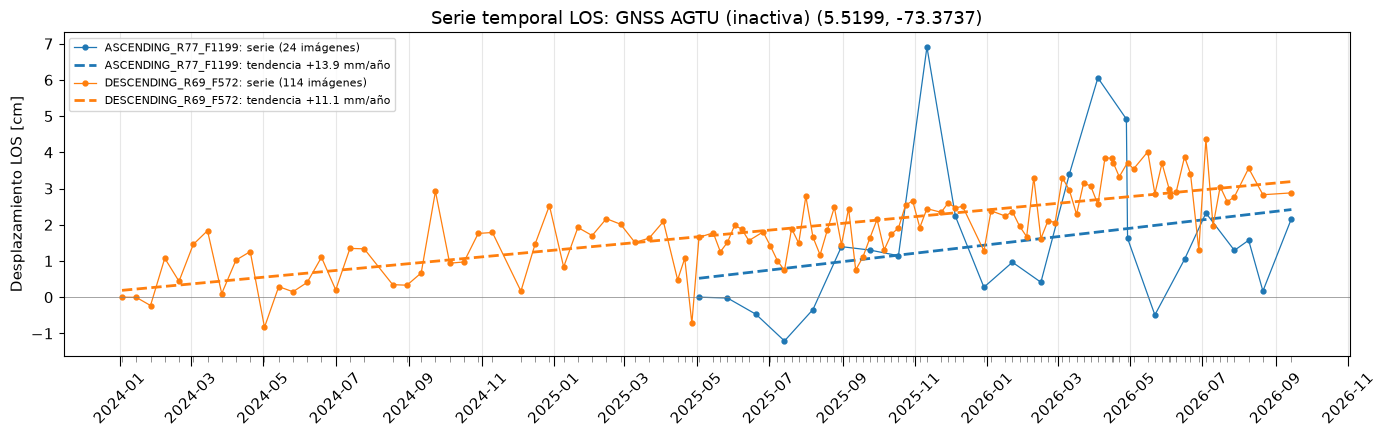


----------------------------------------------------------------------
GNSS OAMU  (5.6472, -73.5580)
  ASCENDING_R77_F1199: 24 imágenes | cada 24 días (mín 1.0, máx 25.0) | tendencia +11.3 mm/año | dispersión alrededor de la tendencia ±1.42 cm
  DESCENDING_R69_F572: 114 imágenes | cada 6 días (mín 1.0, máx 24.0) | tendencia +0.1 mm/año | dispersión alrededor de la tendencia ±1.17 cm


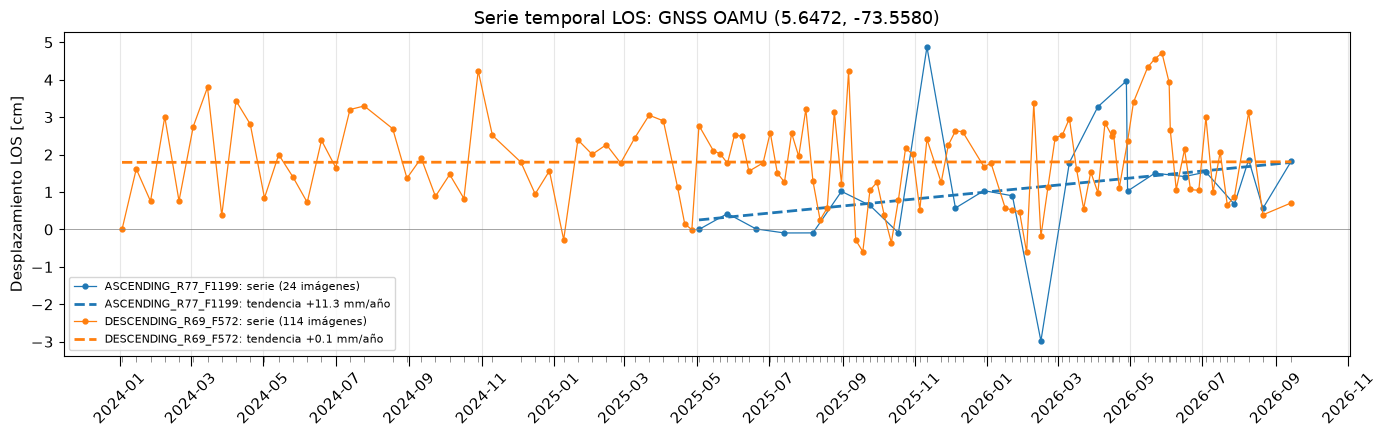


----------------------------------------------------------------------
GNSS TEAT  (5.4218, -73.5393)
  ASCENDING_R77_F1199: 24 imágenes | cada 24 días (mín 1.0, máx 25.0) | tendencia +10.7 mm/año | dispersión alrededor de la tendencia ±1.72 cm
  DESCENDING_R69_F572: 114 imágenes | cada 6 días (mín 1.0, máx 24.0) | tendencia -0.3 mm/año | dispersión alrededor de la tendencia ±0.98 cm


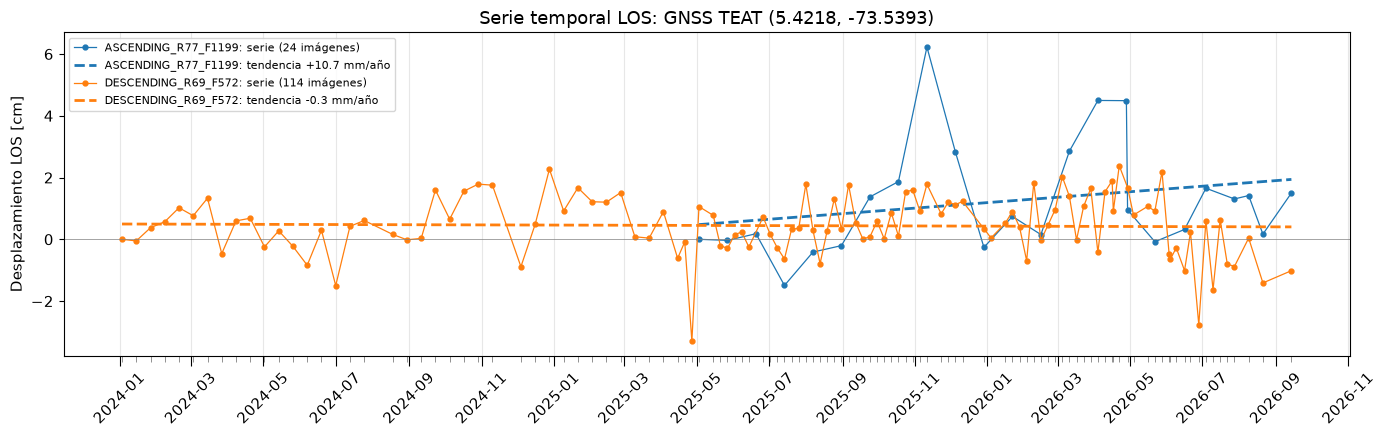


----------------------------------------------------------------------
GNSS FQNE  (5.4673, -73.7348)
  ASCENDING_R77_F1199: fuera del área o sin píxeles confiables
  DESCENDING_R69_F572: fuera del área o sin píxeles confiables
  Sin datos InSAR en ningún stack: no se genera gráfica.


In [56]:
# Estaciones GNSS en la cuenca o cerca de ella (lat, lon), coordenadas geodésicas WGS84.
PUNTOS = {
    # "Evento Vélez": (PUNTO_EVENTO.y, PUNTO_EVENTO.x),
    "GNSS CHRL": (6.287477, -73.156451),
    "GNSS PATU": (5.74649545, -73.12566732),
    "GNSS SUAM": (5.709874625, -72.92469695),
    "GNSS VMES": (6.88333419, -73.09168234),
    "GNSS VELZ (inactiva)": (5.957135, -73.646586),
    "GNSS FLRN": (5.807812, -73.971958),
    "GNSS VBUV": (5.533208338, -73.85893524),
    "GNSS TUNA": (5.531330417, -73.36388193),
    "GNSS AGTU (inactiva)": (5.519884547, -73.37370225),
    "GNSS OAMU": (5.647208907, -73.55802943),
    "GNSS TEAT": (5.421783709, -73.53931227),
    "GNSS FQNE": (5.467344957, -73.73480849),
}


def ventana_en_punto(archivo, lat, lon, ventana=1):
    with h5py.File(archivo, "r") as f:
        attrs = {k: (v.decode() if isinstance(v, bytes) else str(v)) for k, v in f.attrs.items()}
    transform, epsg = georef(attrs)
    x, y = Transformer.from_crs(4326, epsg, always_xy=True).transform(lon, lat)
    r, c = rowcol(transform, x, y)
    L, W = int(attrs["LENGTH"]), int(attrs["WIDTH"])
    if not (0 <= r < L and 0 <= c < W):
        return None
    return max(r - ventana, 0), min(r + ventana + 1, L), max(c - ventana, 0), min(c + ventana + 1, W)


def serie_en_punto(mintpy_dir, lat, lon, ventana=1):
    archivo = serie_final(mintpy_dir)
    v = ventana_en_punto(archivo, lat, lon, ventana)
    if v is None:
        return None, None
    r0, r1, c0, c1 = v
    m = mascara_confiable(mintpy_dir)[r0:r1, c0:c1]
    with h5py.File(archivo, "r") as f:
        fechas = pd.to_datetime(fechas_h5(f["date"][()]), format="%Y%m%d")
        cubo = f["timeseries"][:, r0:r1, c0:c1]
    if not m.any():
        return fechas, None
    serie = np.nanmean(np.where(m, cubo, np.nan), axis=(1, 2)) * 100
    return fechas, serie - serie[0]


for nombre_punto, (lat, lon) in PUNTOS.items():
    print("\n" + "-" * 70)
    print(f"{nombre_punto}  ({lat:.4f}, {lon:.4f})")
    fig, ax = plt.subplots(figsize=(14, 4.5))
    hay_datos = False

    for i, job_name in enumerate(JOBS):
        d = MINTPY_ROOT / job_name
        if not (d / "velocity.h5").exists():
            continue
        etiqueta = job_name.replace(RUN_ID + "_", "")
        fechas, serie = serie_en_punto(d, lat, lon)
        if serie is None:
            print(f"  {etiqueta}: fuera del área o sin píxeles confiables")
            continue
        color = f"C{i}"

        # Tendencia lineal por mínimos cuadrados sobre los mismos puntos graficados
        anios = ((fechas - fechas[0]).days / 365.25).to_numpy()
        pendiente, intercepto = np.polyfit(anios, serie, 1)
        tendencia = pendiente * anios + intercepto
        residuo = np.std(serie - tendencia)

        ax.plot(fechas, serie, "o-", ms=3.5, lw=0.9, color=color, label=f"{etiqueta}: serie ({len(fechas)} imágenes)")
        ax.plot(fechas, tendencia, "--", lw=2, color=color, label=f"{etiqueta}: tendencia {pendiente * 10:+.1f} mm/año")
        ax.set_xticks(fechas, minor=True)       # una marca por cada imagen
        hay_datos = True

        dias = fechas.to_series().diff().dt.days.dropna().to_numpy()
        print(f"  {etiqueta}: {len(fechas)} imágenes | cada {np.median(dias):.0f} días (mín {dias.min()}, máx {dias.max()}) "
              f"| tendencia {pendiente * 10:+.1f} mm/año | dispersión alrededor de la tendencia ±{residuo:.2f} cm")

    if not hay_datos:
        print("  Sin datos InSAR en ningún stack: no se genera gráfica.")
        plt.close(fig)
        continue
    if FECHA_EVENTO is not None:
        ax.axvline(FECHA_EVENTO, color="r", ls="--", label="Evento")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set(title=f"Serie temporal LOS: {nombre_punto} ({lat:.4f}, {lon:.4f})", ylabel="Desplazamiento LOS [cm]")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", which="minor", length=4, color="gray")
    ax.tick_params(axis="x", which="major", length=7, rotation=45)
    ax.grid(axis="x", which="major", alpha=0.3)
    ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    nombre_archivo = re.sub(r"[^A-Za-z0-9]+", "_", nombre_punto).strip("_")
    fig.savefig(FIGURAS_DIR / f"serie_{nombre_archivo}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 24. Exportación de resultados a GeoTIFF

**Ejecución:** siempre.

Los resultados se exportan a formato GeoTIFF para su uso en sistemas de información geográfica (ArcGIS Pro, QGIS). Para cada stack se generan, en `03_resultados/geotiff/<stack>/`:

| Archivo | Contenido |
|---|---|
| `velocidad_mm_anio.tif` | Velocidad LOS (mm/año) con la máscara de confiabilidad aplicada. |
| `velocidad_std_mm_anio.tif` | Desviación estándar de la velocidad (mm/año). |
| `mascara_confiable.tif` | Máscara de confiabilidad (1 = confiable, 0 = excluido). |
| `step_cm.tif` | Escalón del evento (cm), si existe. |
| `*_cuenca.tif` | Las mismas capas recortadas al límite de la cuenca. |

Los archivos conservan el sistema de coordenadas del producto (WGS 84 / UTM zona 18N, EPSG:32618), usan `NaN` como valor sin dato y se comprimen sin pérdida. La escritura se hace con `rasterio`, y el recorte a la cuenca con `geometry_mask` (Gillies et al., 2013); es equivalente a la herramienta `save_gdal.py` de MintPy (EarthScope Consortium, 2026). MintPy genera además `velocity.kmz` en la carpeta de cada stack, para visualización en Google Earth.

Función definida: `guardar_tif(ruta, arr, attrs)`, que escribe un arreglo como GeoTIFF con la georreferencia del producto de MintPy.

In [92]:
def guardar_tif(ruta, arr, attrs):
    transform, epsg = georef(attrs)
    perfil = dict(driver="GTiff", height=arr.shape[0], width=arr.shape[1], count=1, dtype="float32",
                  crs=f"EPSG:{epsg}", transform=transform, nodata=np.nan, compress="deflate")
    with rasterio.open(ruta, "w", **perfil) as dst:
        dst.write(arr.astype("float32"), 1)


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    nombre = job_name.replace(RUN_ID + "_", "")
    salida = GEOTIFF_DIR / job_name
    salida.mkdir(parents=True, exist_ok=True)

    vel, at = leer_h5(d / "velocity.h5", "velocity")
    std, _ = leer_h5(d / "velocity.h5", "velocityStd")
    m = mascara_confiable(d)
    transform, epsg = georef(at)
    fuera_cuenca = geometry_mask(gdf_cuenca.to_crs(epsg).geometry, out_shape=vel.shape, transform=transform)

    capas = {"velocidad_mm_anio": np.where(m, vel * 1000, np.nan),
             "velocidad_std_mm_anio": np.where(m, std * 1000, np.nan),
             "mascara_confiable": m.astype("float32")}
    with h5py.File(d / "velocity.h5", "r") as f:
        for k in f.keys():
            if k.startswith("step") and not k.endswith("Std"):
                capas["step_cm"] = np.where(m, f[k][()] * 100, np.nan)

    for nombre_capa, arr in capas.items():
        guardar_tif(salida / f"{nombre_capa}.tif", arr, at)
        guardar_tif(salida / f"{nombre_capa}_cuenca.tif", np.where(fuera_cuenca, np.nan, arr), at)
    print(f"{nombre}: {len(capas) * 2} archivos GeoTIFF en {salida}")

ASCENDING_R77_F1199: 6 archivos GeoTIFF en /home/jovyan/Tesis_InSAR_Rio_Suarez/03_resultados/geotiff/suarez_2024_2026_v1_ASCENDING_R77_F1199
DESCENDING_R69_F572: 6 archivos GeoTIFF en /home/jovyan/Tesis_InSAR_Rio_Suarez/03_resultados/geotiff/suarez_2024_2026_v1_DESCENDING_R69_F572


## 25. Tabla resumen por stack

**Ejecución:** siempre.

Se resume para cada stack el número de fechas e interferogramas (totales y usados), la fecha de referencia temporal seleccionada por MintPy (`reference_date.txt`), las fechas excluidas por ruido anómalo en el paso `residual_RMS` (`exclude_date.txt`), la ubicación del punto de referencia, el porcentaje de píxeles confiables dentro de la cuenca y la distribución de las velocidades (mediana y percentiles 2 y 98). La tabla se guarda en `03_resultados/tablas/` para incluirla en el documento de tesis.

In [55]:
filas = []
for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    vel, at = leer_h5(d / "velocity.h5", "velocity")
    transform, epsg = georef(at)
    dentro = ~geometry_mask(gdf_cuenca.to_crs(epsg).geometry, out_shape=vel.shape, transform=transform)
    m = mascara_confiable(d) & dentro
    v = vel[m] * 1000
    drop = leer_h5(d / "inputs" / "ifgramStack.h5", "dropIfgram")[0]
    with h5py.File(d / "timeseries.h5", "r") as f:
        n_fechas = f["date"].shape[0]
    leer_txt = lambda p: (d / p).read_text().split() if (d / p).exists() else []

    filas.append({
        "stack": job_name.replace(RUN_ID + "_", ""),
        "fechas": n_fechas,
        "interferogramas": len(drop),
        "interferogramas_usados": int(drop.sum()),
        "fecha_referencia": ",".join(leer_txt("reference_date.txt")),
        "fechas_excluidas": ",".join(leer_txt("exclude_date.txt")) or "ninguna",
        "punto_referencia_lat_lon": f"{float(at.get('REF_LAT', 'nan')):.4f}, {float(at.get('REF_LON', 'nan')):.4f}",
        "pixeles_confiables_cuenca_pct": round(100 * m.sum() / max(dentro.sum(), 1), 1),
        "velocidad_mediana_mm_anio": round(float(np.median(v)), 1) if v.size else np.nan,
        "velocidad_P2_mm_anio": round(float(np.percentile(v, 2)), 1) if v.size else np.nan,
        "velocidad_P98_mm_anio": round(float(np.percentile(v, 98)), 1) if v.size else np.nan,
    })

resumen_df = pd.DataFrame(filas)
display(resumen_df)
resumen_df.to_csv(TABLAS_DIR / f"{RUN_ID}_resumen_mintpy.csv", index=False)
print("Tabla guardada en:", TABLAS_DIR / f"{RUN_ID}_resumen_mintpy.csv")

,stack,fechas,interferogramas,interferogramas_usados,fecha_referencia,fechas_excluidas,punto_referencia_lat_lon,pixeles_confiables_cuenca_pct,velocidad_mediana_mm_anio,velocidad_P2_mm_anio,velocidad_P98_mm_anio
0,ASCENDING_R77_F1199,24,45,27,20250503,ninguna,"615360.0000, 643440.0000",75.1,1.2,-52.0,51.7
1,DESCENDING_R69_F572,114,221,196,20250819,ninguna,"609200.0000, 709200.0000",51.4,-3.7,-39.2,25.5


Tabla guardada en: /home/jovyan/Tesis_InSAR_Rio_Suarez/03_resultados/tablas/suarez_2024_2026_v1_resumen_mintpy.csv


# 26. Validación con GNSS

InSAR mide el desplazamiento solo en la línea de vista del satélite (LOS) y de forma relativa a un punto de referencia (Yunjun et al., 2019). Las estaciones GNSS permanentes miden la posición en tres componentes (Este, Norte y Vertical) de forma independiente, por lo que se usan para validar los resultados de InSAR (EarthScope Consortium, 2026).

Las series GNSS se obtienen del Nevada Geodetic Laboratory (NGL), que procesa diariamente las estaciones con posicionamiento puntual preciso (PPP) en GipsyX (Zumberge et al., 1997; Bertiger et al., 2020; Blewitt et al., 2018). Se usa el marco IGS20, alineado con el ITRF2020 (Altamimi et al., 2023). Los conceptos de PPP se tomaron del curso de EarthScope sobre PPP multi-GNSS (Geng et al., 2024).

El análisis de las series se basa en el curso de EarthScope sobre GAMIT/GLOBK (Herring et al., 2026), que trata el cálculo de velocidades, los saltos, las señales estacionales y el ruido. Ese curso trabaja con GAMIT/GLOBK; en este notebook los mismos pasos se escriben en Python. La descarga y la comparación con InSAR siguen la sección 5 del notebook `smallbaselineApp_aria.ipynb` del curso ISCE+ 2026, y la proyección a LOS sigue su módulo 1.2 (EarthScope Consortium, 2026).

Pasos:

1. Descarga de las series diarias y de la base de saltos del NGL (26.1).
2. Ajuste de un modelo de trayectoria a cada componente: tendencia, señal anual y semestral y saltos (Bevis & Brown, 2014). La incertidumbre considera el ruido correlacionado (Williams, 2003; Herring et al., 2016) (26.2).
3. Mapa de velocidades de la red (26.3).
4. Proyección de las velocidades a LOS y comparación con InSAR (26.4).
5. Figuras de comparación y series superpuestas (26.5 y 26.6).

Las velocidades GNSS incluyen el movimiento del Bloque Norandino (Mora-Páez et al., 2019), que InSAR no ve porque es relativo a un píxel de la escena. Por eso, antes de comparar, se resta la diferencia constante entre ambas, usando una estación de referencia (`REF_GNSS`) o la mediana de las diferencias. Es el mismo criterio de la opción `--ref-gnss` de MintPy (EarthScope Consortium, 2026).

Esta sección usa variables y funciones de las secciones 3 a 23.

## 26.1 Descarga de las series GNSS

**Ejecución:** una sola vez. Si se repite, omite los archivos que ya existen; con `ACTUALIZAR = True` los vuelve a descargar para incluir los días más recientes.

Las estaciones se toman del diccionario `PUNTOS` de la sección 23, a partir de las claves que empiezan por `GNSS`. Para cada una:

1. Se extrae el código de cuatro letras (por ejemplo, `TUNA`) con la expresión regular `GNSS\s+(\w{4})` del módulo `re` (Python Software Foundation, 2024). Es el identificador que usan el NGL y las redes GeoRED y MAGNA-ECO.
2. Se descarga el archivo `.tenv3` de la solución IGS20 del NGL, que contiene una posición diaria en Este, Norte y Vertical con su incertidumbre (Blewitt et al., 2018).
3. Se descarga una sola vez el archivo `steps.txt`, donde el NGL registra las fechas de cambio de equipo (código 1) y de sismos cercanos (código 2). Estos saltos se incluyen luego en el modelo para que no se confundan con la velocidad (Bevis & Brown, 2014).

La descarga se hace con `requests.get` y los archivos se guardan en `01_datos/gnss/`. Es el mismo archivo `.tenv3` que descarga MintPy con la opción `--gnss-source UNR` en la sección 5 del notebook `smallbaselineApp_aria.ipynb` del curso ISCE+ 2026 (EarthScope Consortium, 2026).

In [81]:
import requests

GNSS_DIR = DATOS_DIR / "gnss"
GNSS_DIR.mkdir(parents=True, exist_ok=True)
URL_TENV3 = "https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{}.tenv3"
URL_PASOS = "https://geodesy.unr.edu/NGLStationPages/steps.txt"
ACTUALIZAR = False     
GUARDAR_FIGURAS = True

ESTACIONES = {re.match(r"GNSS\s+(\w{4})", nombre).group(1): coords
              for nombre, coords in PUNTOS.items() if nombre.startswith("GNSS")}


def descargar(url, destino, forzar=False):
    if destino.exists() and destino.stat().st_size > 0 and not forzar:
        return "existente"
    r = requests.get(url, timeout=180)
    if r.status_code != 200:
        return "no disponible"
    destino.write_bytes(r.content)
    return "descargado"


MENSAJES = {"existente": "Ya esta en el disco, no se descarga",
            "descargado": "Descargado ahora",
            "no disponible": "NO disponible en NGL IGS20"}

archivo_pasos = GNSS_DIR / "steps.txt"
print(f"steps.txt: {MENSAJES[descargar(URL_PASOS, archivo_pasos, ACTUALIZAR)]}")
for sitio in ESTACIONES:
    estado = descargar(URL_TENV3.format(sitio), GNSS_DIR / f"{sitio}.tenv3", ACTUALIZAR)
    print(f"{sitio}: {MENSAJES[estado]}")

steps.txt: Ya esta en el disco, no se descarga
CHRL: Ya esta en el disco, no se descarga
PATU: Ya esta en el disco, no se descarga
SUAM: Ya esta en el disco, no se descarga
VMES: Ya esta en el disco, no se descarga
VELZ: Ya esta en el disco, no se descarga
FLRN: Ya esta en el disco, no se descarga
VBUV: Ya esta en el disco, no se descarga
TUNA: Ya esta en el disco, no se descarga
AGTU: Ya esta en el disco, no se descarga
OAMU: Ya esta en el disco, no se descarga
TEAT: Ya esta en el disco, no se descarga
FQNE: Ya esta en el disco, no se descarga


## 26.2 Lectura de las series y modelo de trayectoria

**Ejecución:** cada vez que se abre el notebook.

Una serie GNSS no es una recta: además de la velocidad tiene señales estacionales, saltos por cambio de equipo y días con valores atípicos (Bevis & Brown, 2014). Para obtener una velocidad confiable, para cada estación y cada componente (Este, Norte y Vertical):

1. Se lee el archivo `.tenv3` con `pandas` (McKinney, 2010). La posición se obtiene sumando la parte entera y la fraccional que entrega el NGL, y la fecha se calcula a partir del día juliano modificado (MJD).
2. Se ajusta por mínimos cuadrados ponderados, con `numpy.linalg.lstsq` (Harris et al., 2020), el modelo:

   $y(t) = a + v\,t + \sum_{k=1}^{2}\left[s_k \sin(2\pi k t) + c_k \cos(2\pi k t)\right] + \sum_j b_j\,H(t - t_j)$

   donde $v$ es la velocidad, $k = 1$ y $k = 2$ son las señales anual y semestral, y $H$ es un escalón en cada salto $t_j$ (Bevis & Brown, 2014). Los términos periódicos solo se incluyen si la serie cubre al menos un año.
3. Se eliminan los valores atípicos en hasta tres iteraciones, descartando los días cuyo residuo supera tres veces la desviación robusta (1.4826 veces la mediana de las desviaciones absolutas).
4. Se corrige la incertidumbre de la velocidad por ruido correlacionado. La incertidumbre formal supone ruido blanco y subestima la real de 2 a 5 veces (Williams, 2003). Se multiplica por un factor que compara la dispersión de los residuos promediados cada 30 días con la de los residuos diarios, una versión simplificada del método de sigma realista (Herring et al., 2016).
5. Se identifican los huecos de más de `HUECO_MIN_DIAS` días sin datos, que se sombrean en las figuras.

El modelo es el mismo tipo que ajusta la herramienta `tsfit` de GLOBK, vista en el curso de EarthScope sobre GAMIT/GLOBK (Herring et al., 2026), y el que usa MintPy para las series InSAR con `mintpy.timeFunc` (Yunjun et al., 2019). Las velocidades se guardan en `03_resultados/tablas/gnss_velocidades_enu_igs20.csv`.


----------------------------------------------------------------------
CHRL  (6.2875, -73.1565)
  458 días (45.6 % del periodo) | huecos mayores a 15 días: 1 (46 días) | saltos: 2
  vE +3.3 ± 1.0 | vN +9.4 ± 0.7 | vU -4.1 ± 3.0 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.78, 1.3, 1.46
  Nota: serie corta (1.4 años).


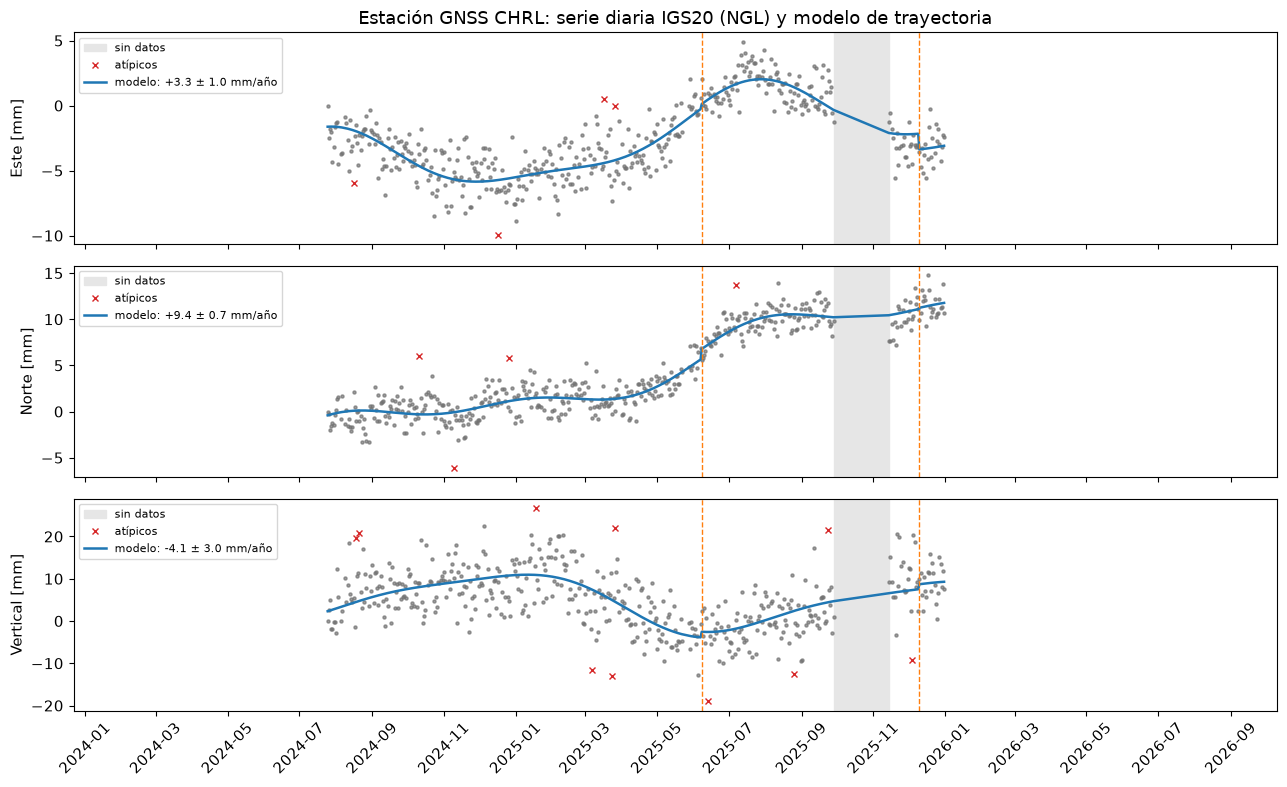


----------------------------------------------------------------------
PATU  (5.7465, -73.1257)
  Solo 0 días en el periodo 2024-01-01 a 2026-09-30: no se analiza.

----------------------------------------------------------------------
SUAM  (5.7099, -72.9247)
  417 días (41.5 % del periodo) | huecos mayores a 15 días: 4 (160 días) | saltos: 1
  vE +1.0 ± 0.5 | vN +10.5 ± 0.3 | vU -5.0 ± 1.5 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.41, 1.35, 1.53
  Nota: serie corta (2.0 años).


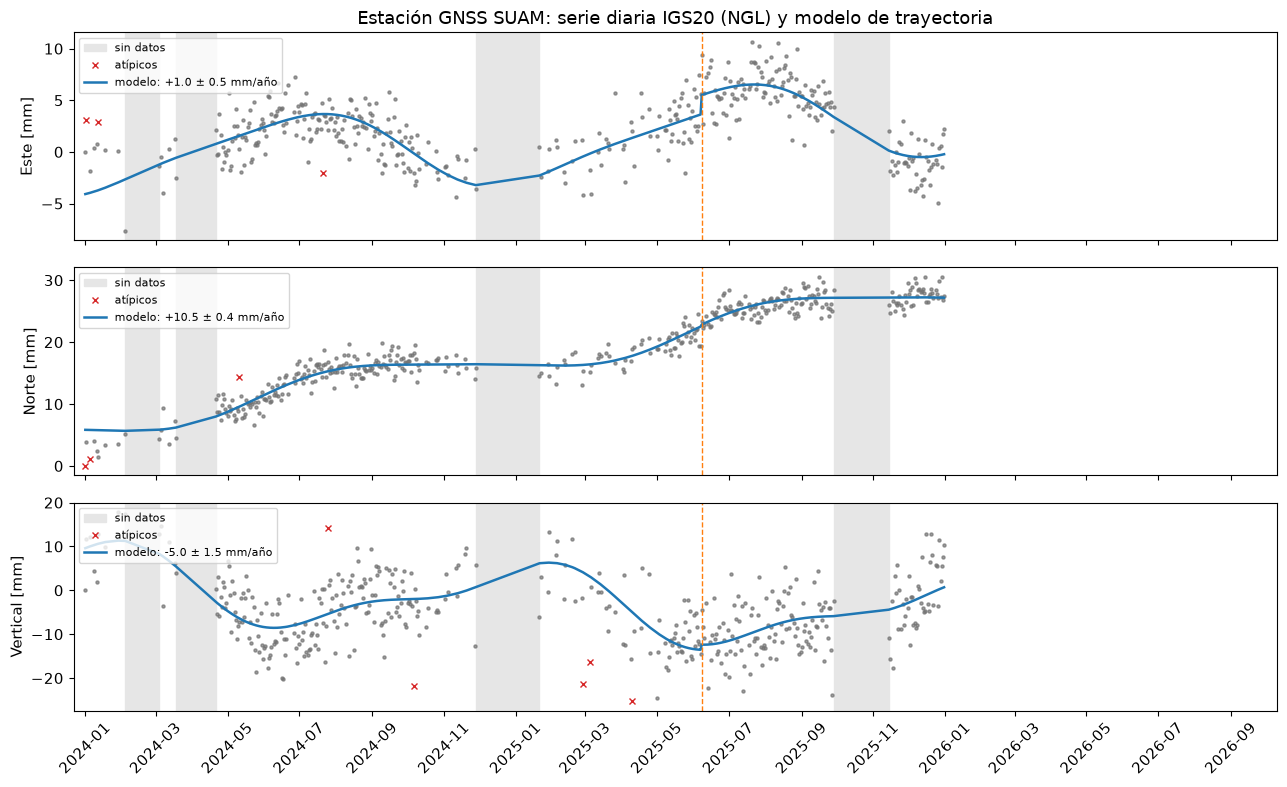


----------------------------------------------------------------------
VMES  (6.8833, -73.0917)
  316 días (31.5 % del periodo) | huecos mayores a 15 días: 5 (349 días) | saltos: 1
  vE +3.1 ± 0.2 | vN +12.4 ± 0.2 | vU -4.3 ± 0.7 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.0, 1.08, 1.11
  Nota: serie corta (2.0 años).


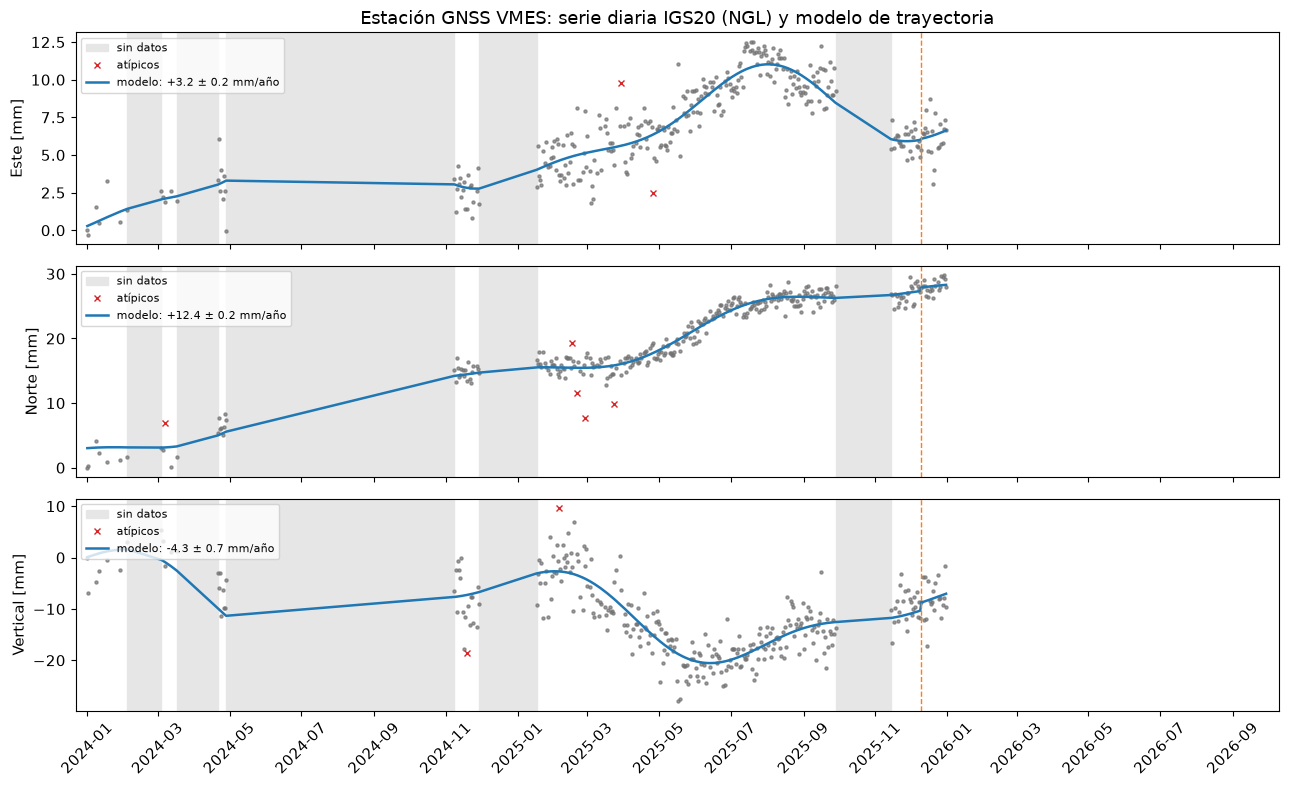


----------------------------------------------------------------------
VELZ  (5.9571, -73.6466)
  500 días (49.8 % del periodo) | huecos mayores a 15 días: 2 (68 días) | saltos: 1
  vE +4.0 ± 0.5 | vN +11.7 ± 0.4 | vU -7.1 ± 1.3 mm/año (IGS20)
  Factor de ruido (E, N, U): 2.03, 1.67, 1.46
  Nota: serie corta (1.7 años).


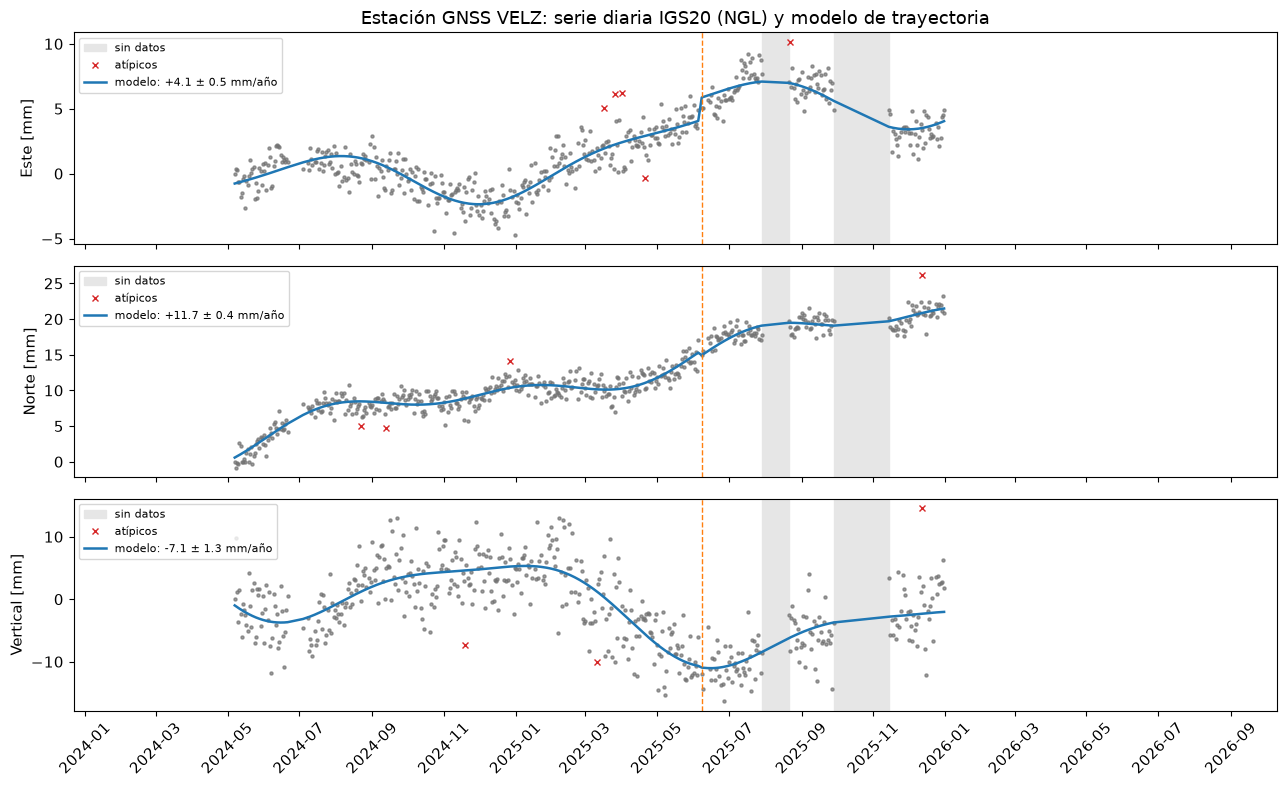


----------------------------------------------------------------------
FLRN  (5.8078, -73.9720)
  312 días (31.1 % del periodo) | huecos mayores a 15 días: 1 (46 días) | saltos: 1
  vE +15.7 ± 2.4 | vN -12.4 ± 4.0 | vU -3.1 ± 2.3 mm/año (IGS20)
  Factor de ruido (E, N, U): 2.32, 3.45, 1.0
  Nota: serie corta (1.0 años).


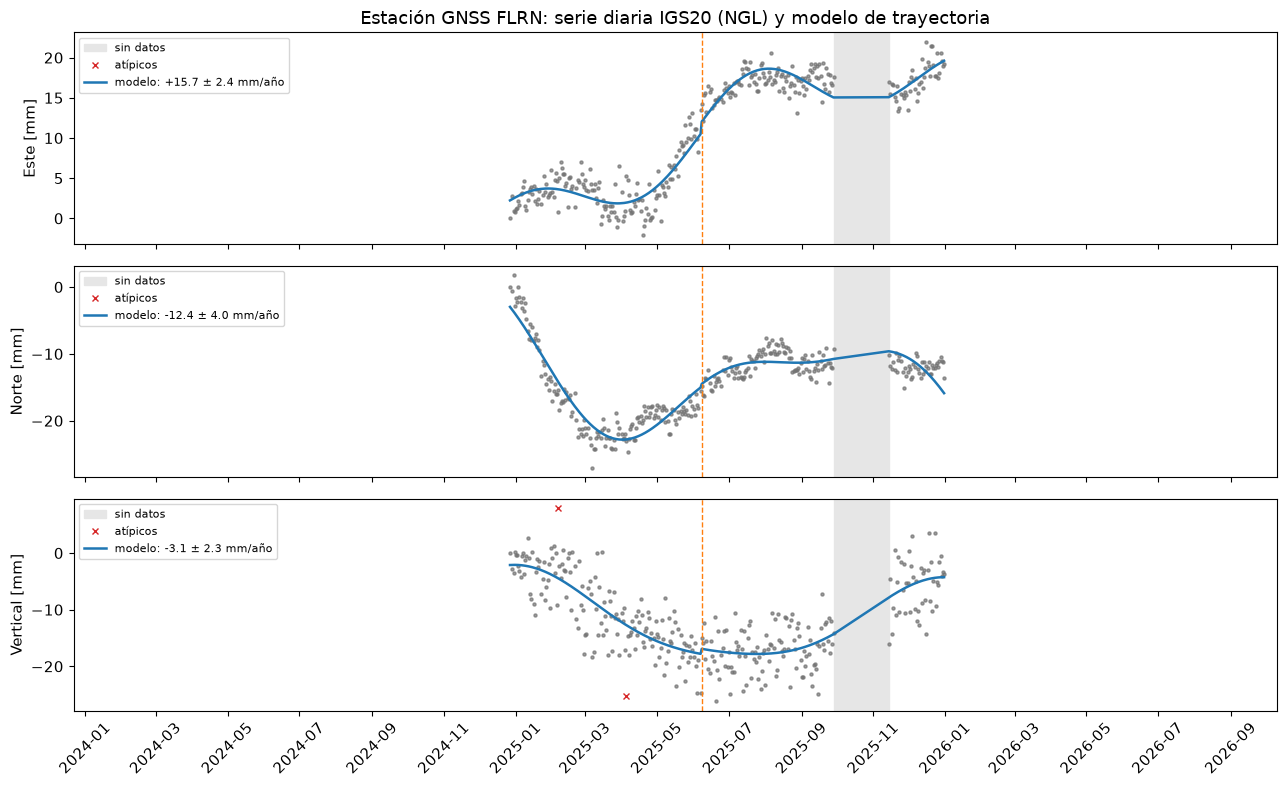


----------------------------------------------------------------------
VBUV  (5.5332, -73.8589)
  193 días (19.2 % del periodo) | huecos mayores a 15 días: 4 (416 días) | saltos: 1
  vE +4.3 ± 0.5 | vN +7.9 ± 1.0 | vU +9.7 ± 2.7 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.32, 2.18, 1.95
  Nota: serie corta (2.0 años).


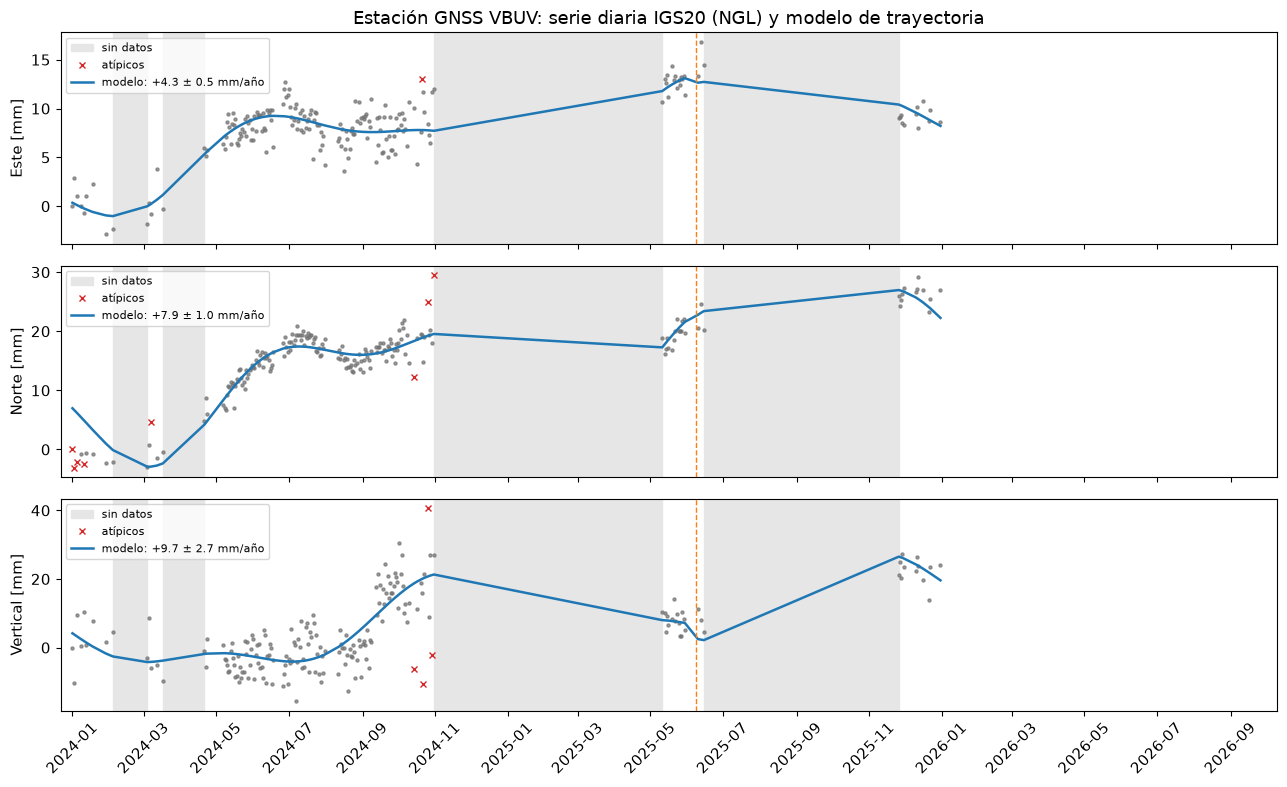


----------------------------------------------------------------------
TUNA  (5.5313, -73.3639)
  665 días (66.2 % del periodo) | huecos mayores a 15 días: 1 (46 días) | saltos: 1
  vE +1.6 ± 0.2 | vN +12.2 ± 0.3 | vU -4.8 ± 0.8 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.43, 2.66, 1.96
  Nota: serie corta (2.0 años).


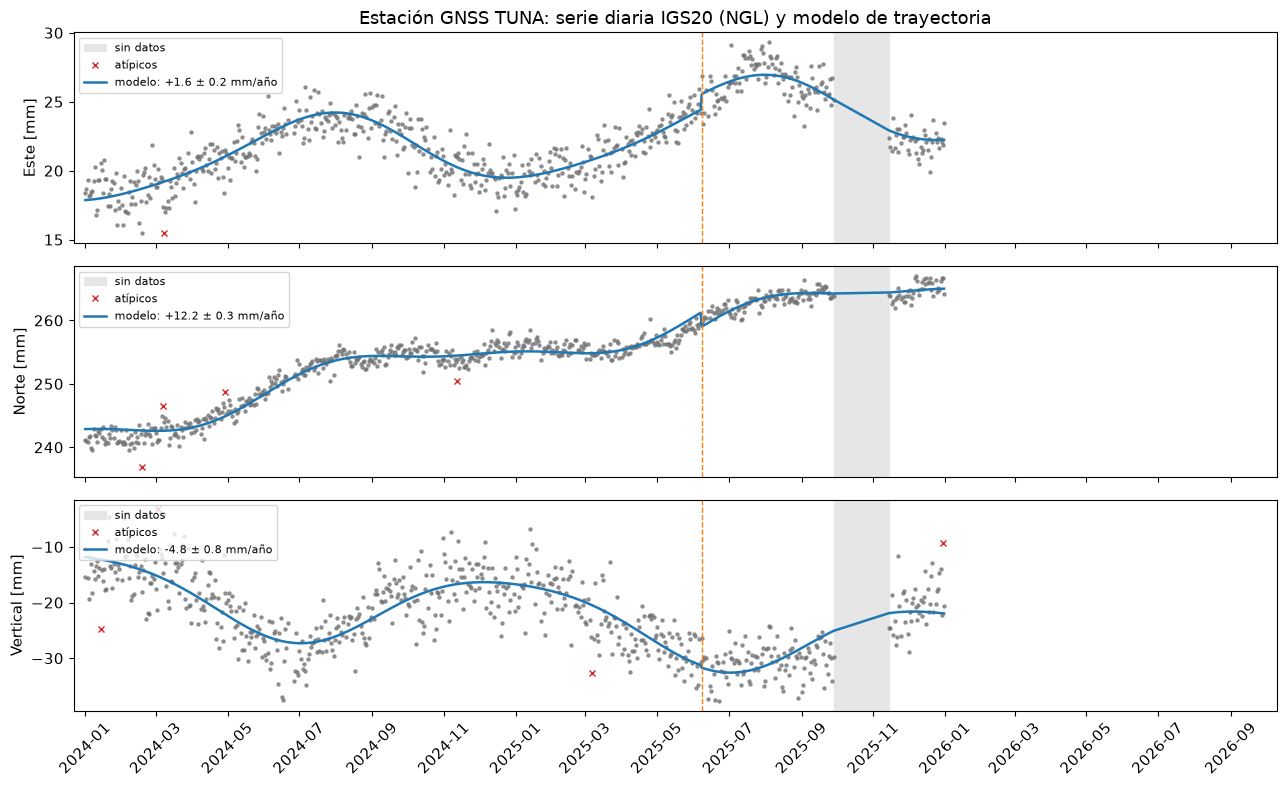


----------------------------------------------------------------------
AGTU  (5.5199, -73.3737)
  211 días (21.0 % del periodo) | huecos mayores a 15 días: 3 (255 días) | saltos: 1
  vE +2.8 ± 0.2 | vN +10.2 ± 0.6 | vU -6.7 ± 0.8 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.0, 2.11, 1.0
  Nota: serie corta (1.5 años).


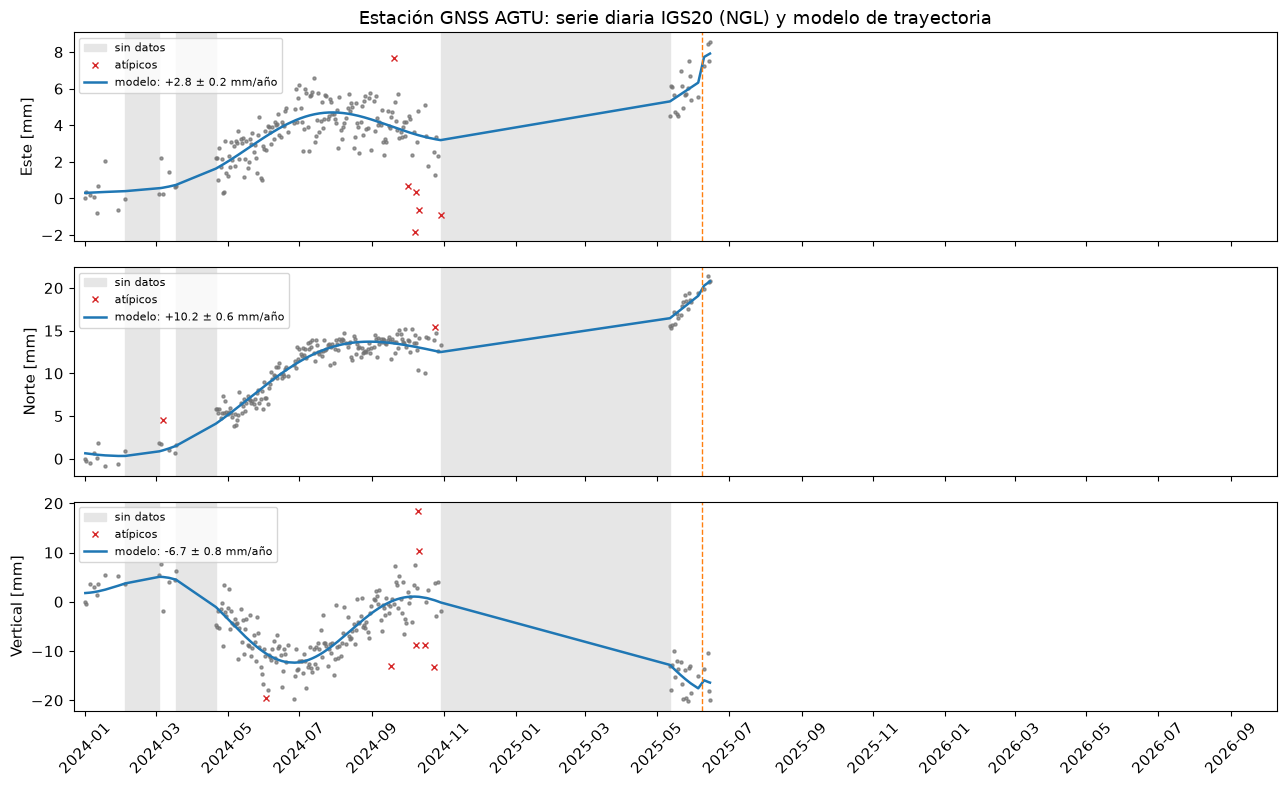


----------------------------------------------------------------------
OAMU  (5.6472, -73.5580)
  175 días (17.4 % del periodo) | huecos mayores a 15 días: 3 (281 días) | saltos: 1
  vE +3.7 ± 0.4 | vN +8.5 ± 0.6 | vU -6.4 ± 1.3 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.0, 1.74, 1.0
  Nota: serie corta (1.5 años).


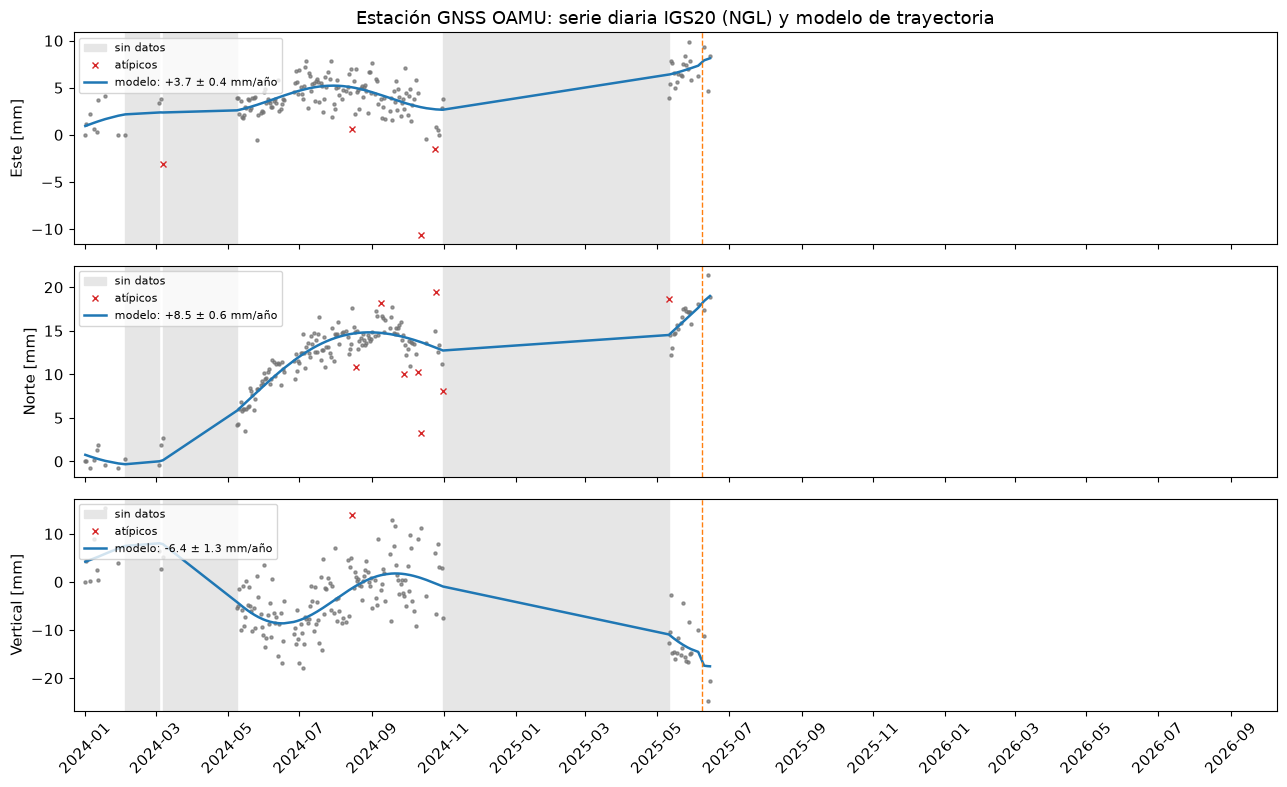


----------------------------------------------------------------------
TEAT  (5.4218, -73.5393)
  113 días (11.3 % del periodo) | huecos mayores a 15 días: 6 (528 días) | saltos: 1
  vE +1.5 ± 0.3 | vN +11.7 ± 0.3 | vU -5.1 ± 1.1 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.0, 1.0, 1.0
  Nota: serie corta (2.0 años).


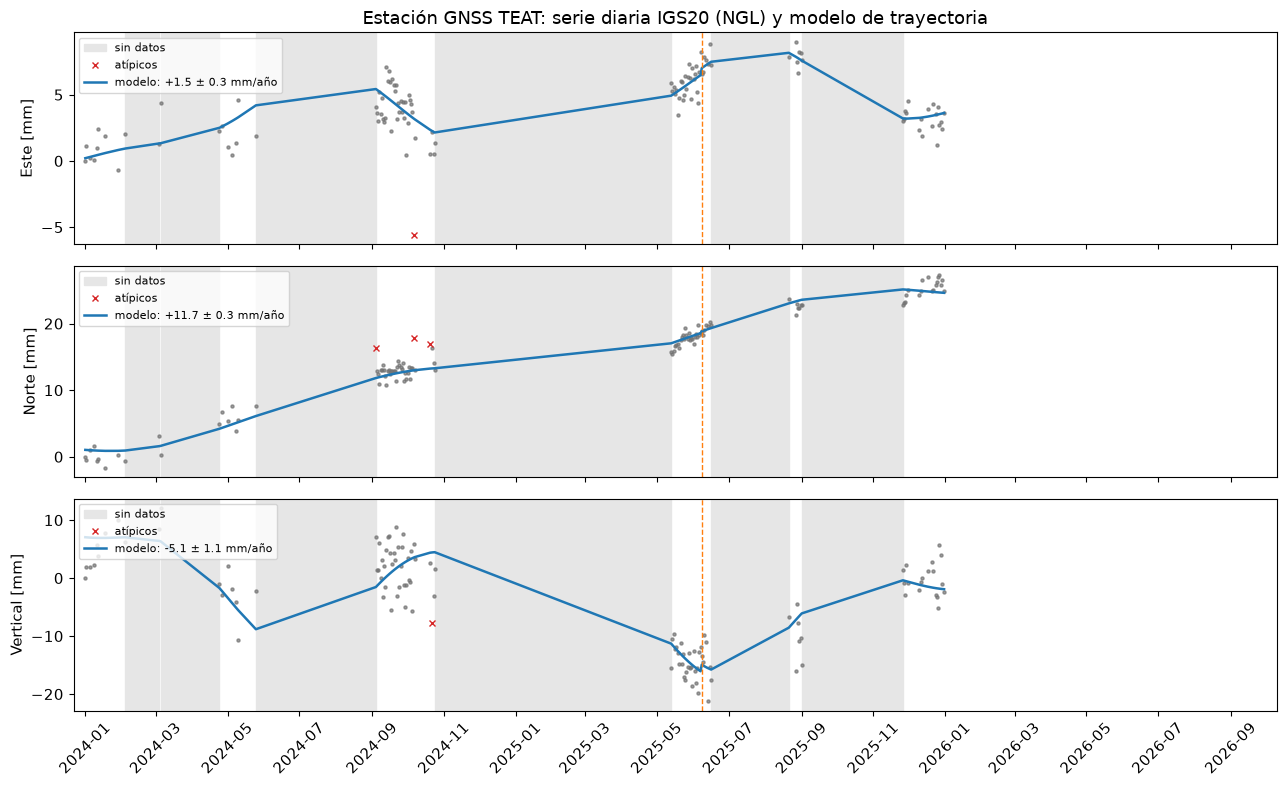


----------------------------------------------------------------------
FQNE  (5.4673, -73.7348)
  599 días (59.7 % del periodo) | huecos mayores a 15 días: 2 (63 días) | saltos: 1
  vE +2.4 ± 0.2 | vN +12.3 ± 0.3 | vU -4.6 ± 1.6 mm/año (IGS20)
  Factor de ruido (E, N, U): 1.58, 2.07, 2.41
  Nota: serie corta (2.0 años).


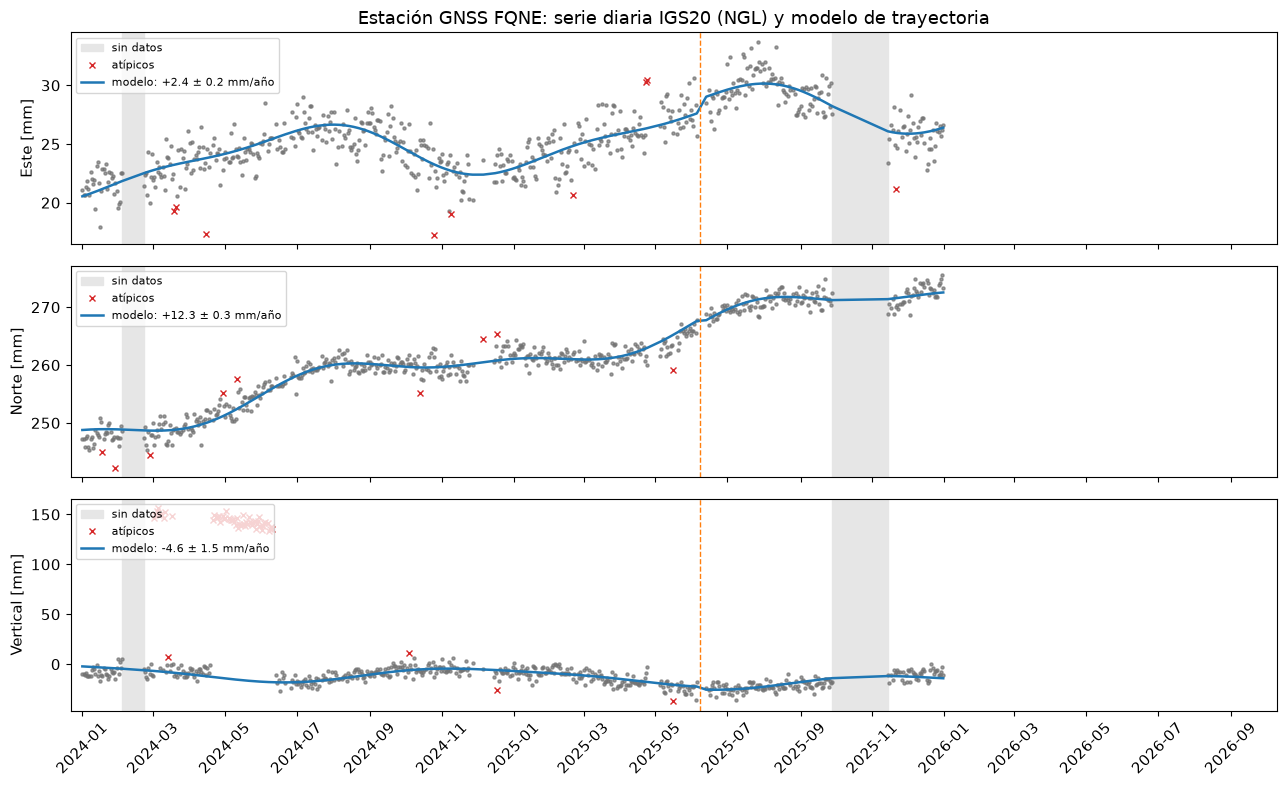

,sitio,lat,lon,inicio,fin,anios,dias,%_dias,huecos,dias_hueco,...,factor_E,atipicos_E,vN_mm,sN_mm,factor_N,atipicos_N,vU_mm,sU_mm,factor_U,atipicos_U
0,CHRL,6.287477,-73.156451,2024-07-25,2025-12-31,1.43,458,45.6,1,46,...,1.78,4,9.36,0.72,1.30,4,-4.07,3.03,1.46,10
1,SUAM,5.709875,-72.924697,2024-01-01,2025-12-31,2.00,417,41.5,4,160,...,1.41,3,10.54,0.35,1.35,3,-5.02,1.54,1.53,5
2,VMES,6.883334,-73.091682,2024-01-01,2025-12-31,2.00,316,31.5,5,349,...,1.00,2,12.37,0.23,1.08,5,-4.29,0.74,1.11,2
3,VELZ,5.957135,-73.646586,2024-05-07,2025-12-31,1.65,500,49.8,2,68,...,2.03,5,11.70,0.44,1.67,4,-7.13,1.29,1.46,3
4,FLRN,5.807812,-73.971958,2024-12-27,2025-12-31,1.01,312,31.1,1,46,...,2.32,0,-12.45,4.00,3.45,0,-3.09,2.31,1.00,2
5,VBUV,5.533208,-73.858935,2024-01-01,2025-12-31,2.00,193,19.2,4,416,...,1.32,1,7.89,0.97,2.18,8,9.68,2.73,1.95,4
6,TUNA,5.531330,-73.363882,2024-01-01,2025-12-31,2.00,665,66.2,1,46,...,1.43,1,12.22,0.35,2.66,4,-4.85,0.84,1.96,4
7,AGTU,5.519885,-73.373702,2024-01-01,2025-06-15,1.45,211,21.0,3,255,...,1.00,6,10.20,0.56,2.11,2,-6.74,0.85,1.00,7
8,OAMU,5.647209,-73.558029,2024-01-01,2025-06-15,1.45,175,17.4,3,281,...,1.00,4,8.47,0.61,1.74,8,-6.37,1.26,1.00,1
9,TEAT,5.421784,-73.539312,2024-01-01,2025-12-31,2.00,113,11.3,6,528,...,1.00,1,11.68,0.35,1.00,3,-5.12,1.14,1.00,1


In [82]:
GNSS_INICIO = pd.Timestamp("2024-01-01")
GNSS_FIN = pd.Timestamp("2026-09-30")
MJD0 = pd.Timestamp("1858-11-17")
HUECO_MIN_DIAS = 15      
COLUMNAS_TENV3 = ["sitio", "fecha_txt", "anio_dec", "mjd", "semana", "dia", "reflon",
                  "e0", "este", "n0", "norte", "u0", "vertical", "ant",
                  "sig_e", "sig_n", "sig_u", "corr_en", "corr_eu", "corr_nu", "lat", "lon", "altura"]


def leer_tenv3(archivo):
    """Serie diaria del NGL: fecha, E, N, U (mm, relativos al primer día) y sus incertidumbres (mm)."""
    df = pd.read_csv(archivo, sep=r"\s+", header=0)
    df.columns = COLUMNAS_TENV3[:df.shape[1]]
    salida = pd.DataFrame({"fecha": MJD0 + pd.to_timedelta(df["mjd"], unit="D")})
    for comp, entero, frac, sig in (("E", "e0", "este", "sig_e"), ("N", "n0", "norte", "sig_n"),
                                    ("U", "u0", "vertical", "sig_u")):
        pos = (df[entero] + df[frac]).to_numpy() * 1000
        salida[comp] = pos - pos[0]
        salida[f"sig_{comp}"] = df[sig].to_numpy() * 1000
    return salida


def leer_pasos(sitio, inicio, fin):
    if not archivo_pasos.exists():
        return []
    fechas = set()
    for linea in archivo_pasos.read_text(errors="ignore").splitlines():
        p = linea.split()
        if len(p) >= 3 and p[0] == sitio:
            try:
                f = pd.to_datetime(p[1], format="%y%b%d")
            except ValueError:
                continue
            if inicio < f < fin:
                fechas.add(f)
    return sorted(fechas)


def buscar_huecos(fechas, minimo=HUECO_MIN_DIAS):
    fechas = pd.Series(pd.DatetimeIndex(fechas))
    saltos = fechas.diff().dt.days.to_numpy()
    return [(fechas.iloc[i - 1], fechas.iloc[i]) for i in np.where(saltos > minimo)[0]]


def factor_ruido_correlacionado(fechas, res, sigma, ventana=30):
    s = pd.DataFrame({"r": res, "w": 1.0 / sigma ** 2}, index=pd.DatetimeIndex(fechas))
    grupos = (s.index - s.index[0]).days // ventana
    agg = s.assign(rw=s["r"] * s["w"]).groupby(grupos).agg(rw=("rw", "sum"), w=("w", "sum"), n=("r", "size"))
    agg = agg[agg["n"] >= ventana // 2]
    if len(agg) < 4:
        return 1.0
    chi2_promedios = np.mean((agg["rw"] / agg["w"]) ** 2 * agg["w"])
    chi2_diario = np.mean(s["r"] ** 2 * s["w"])
    return float(np.sqrt(max(chi2_promedios / chi2_diario, 1.0)))


def ajustar_trayectoria(fechas, y, sigma, pasos=(), umbral=3.0, n_iter=3):
    fechas = pd.DatetimeIndex(fechas)
    t = ((fechas - fechas[0]).days / 365.25).to_numpy(dtype=float)
    columnas = [np.ones_like(t), t - t.mean()]
    if t[-1] - t[0] >= 1.0:
        for k in (1, 2):
            columnas += [np.sin(2 * np.pi * k * t), np.cos(2 * np.pi * k * t)]
    columnas += [(fechas >= p).astype(float) for p in pasos if fechas[0] < p < fechas[-1]]
    A = np.column_stack(columnas)
    y, sigma = np.asarray(y, float), np.asarray(sigma, float)
    ok = np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)

    for _ in range(n_iter + 1):
        w = 1.0 / sigma[ok]
        x = np.linalg.lstsq(A[ok] * w[:, None], y[ok] * w, rcond=None)[0]
        res = y - A @ x
        mad = 1.4826 * np.median(np.abs(res[ok] - np.median(res[ok])))
        nuevo = ok & (np.abs(res) <= umbral * mad)
        if nuevo.sum() == ok.sum():
            break
        ok = nuevo

    w = 1.0 / sigma[ok]
    Aw = A[ok] * w[:, None]
    x = np.linalg.lstsq(Aw, y[ok] * w, rcond=None)[0]
    res = y - A @ x
    gl = max(ok.sum() - A.shape[1], 1)
    chi2r = np.sum((res[ok] / sigma[ok]) ** 2) / gl
    cov = np.linalg.inv(Aw.T @ Aw) * chi2r
    anual = float(np.hypot(x[2], x[3])) if A.shape[1] > 2 and t[-1] - t[0] >= 1.0 else np.nan
    sigma_formal = float(np.sqrt(cov[1, 1]))
    factor = factor_ruido_correlacionado(fechas[ok], res[ok], sigma[ok])
    return {"vel": float(x[1]), "vel_sigma": sigma_formal * factor, "vel_sigma_formal": sigma_formal,
            "factor_ruido": factor, "modelo": A @ x,
            "atipicos": ~ok, "n": int(ok.sum()), "amplitud_anual": anual,
            "rms": float(np.std(res[ok]))}


gnss, filas = {}, []
for sitio, (lat, lon) in ESTACIONES.items():
    print("\n" + "-" * 70)
    print(f"{sitio}  ({lat:.4f}, {lon:.4f})")
    archivo = GNSS_DIR / f"{sitio}.tenv3"
    if not archivo.exists():
        print("  Sin archivo del NGL.")
        continue
    serie = leer_tenv3(archivo)
    serie = serie[(serie["fecha"] >= GNSS_INICIO) & (serie["fecha"] <= GNSS_FIN)].reset_index(drop=True)
    dias_periodo = (GNSS_FIN - GNSS_INICIO).days + 1
    if len(serie) < 60:
        print(f"  Solo {len(serie)} días en el periodo {GNSS_INICIO.date()} a {GNSS_FIN.date()}: no se analiza.")
        continue
    pasos = leer_pasos(sitio, serie["fecha"].iloc[0], serie["fecha"].iloc[-1])
    huecos = buscar_huecos(serie["fecha"])
    dias_hueco = int(sum((b - a).days - 1 for a, b in huecos))
    anios = (serie["fecha"].iloc[-1] - serie["fecha"].iloc[0]).days / 365.25
    fila = {"sitio": sitio, "lat": lat, "lon": lon, "inicio": serie["fecha"].iloc[0].date(),
            "fin": serie["fecha"].iloc[-1].date(), "anios": round(anios, 2), "dias": len(serie),
            "%_dias": round(100 * len(serie) / dias_periodo, 1), "huecos": len(huecos),
            "dias_hueco": dias_hueco, "saltos": len(pasos)}
    ajustes = {}
    for comp in "ENU":
        a = ajustar_trayectoria(serie["fecha"], serie[comp], serie[f"sig_{comp}"], pasos)
        ajustes[comp] = a
        fila[f"v{comp}_mm"] = round(a["vel"], 2)
        fila[f"s{comp}_mm"] = round(a["vel_sigma"], 2)
        fila[f"factor_{comp}"] = round(a["factor_ruido"], 2)
        fila[f"atipicos_{comp}"] = int(a["atipicos"].sum())
    gnss[sitio] = {"serie": serie, "pasos": pasos, "huecos": huecos, "ajustes": ajustes, "lat": lat, "lon": lon}
    filas.append(fila)
    print(f"  {len(serie)} días ({fila['%_dias']} % del periodo) | huecos mayores a {HUECO_MIN_DIAS} días: "
          f"{len(huecos)} ({dias_hueco} días) | saltos: {len(pasos)}")
    print(f"  vE {fila['vE_mm']:+.1f} ± {fila['sE_mm']:.1f} | vN {fila['vN_mm']:+.1f} ± {fila['sN_mm']:.1f} | "
          f"vU {fila['vU_mm']:+.1f} ± {fila['sU_mm']:.1f} mm/año (IGS20)")
    print(f"  Factor de ruido (E, N, U): {fila['factor_E']}, {fila['factor_N']}, {fila['factor_U']}")
    if anios < 2.5:
        print(f"  Nota: serie corta ({anios:.1f} años).")

    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
    for ax, comp, nombre_comp in zip(axes, "ENU", ("Este", "Norte", "Vertical")):
        a = ajustes[comp]
        buenos = ~a["atipicos"]
        for k, (h0, h1) in enumerate(huecos):
            ax.axvspan(h0, h1, color="0.9", zorder=0, label="sin datos" if k == 0 else None)
        ax.plot(serie["fecha"][buenos], serie[comp][buenos], "o", ms=2.2, color="0.45", alpha=0.7)
        ax.plot(serie["fecha"][~buenos], serie[comp][~buenos], "x", ms=4, color="tab:red", label="atípicos")
        ax.plot(serie["fecha"], a["modelo"], "-", lw=1.8, color="tab:blue",
                label=f"modelo: {a['vel']:+.1f} ± {a['vel_sigma']:.1f} mm/año")
        for p in pasos:
            ax.axvline(p, color="tab:orange", ls="--", lw=1)
        ax.set_ylabel(f"{nombre_comp} [mm]")
        ax.legend(loc="upper left", fontsize=8)
    axes[0].set_title(f"Estación GNSS {sitio}: serie diaria IGS20 (NGL) y modelo de trayectoria")
    axes[-1].set_xlim(GNSS_INICIO - pd.Timedelta(days=10), GNSS_FIN + pd.Timedelta(days=10))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[-1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

vel_gnss = pd.DataFrame(filas)
display(vel_gnss)
vel_gnss.to_csv(TABLAS_DIR / "gnss_velocidades_enu_igs20.csv", index=False)

## 26.3 Mapa de velocidades GNSS

**Ejecución:** cada vez que se abre el notebook.

El mapa de velocidades de la red resume el movimiento de todas las estaciones (Mora-Páez et al., 2019). Se presenta en dos paneles:

1. Velocidades en el marco IGS20, tal como salen de 26.2. Las flechas muestran la componente horizontal y el color de cada círculo la vertical. En este marco domina el movimiento del Bloque Norandino, casi igual en todas las estaciones (Mora-Páez et al., 2019).
2. Velocidades horizontales relativas a la red, restando la mediana de todas las estaciones. Esto equivale a fijar el marco de referencia a la propia red, como se trata en el curso de GAMIT/GLOBK (Herring et al., 2026), y deja solo las diferencias entre estaciones.

Las flechas se dibujan con `quiver` y la escala con `quiverkey`, de Matplotlib (Hunter, 2007).

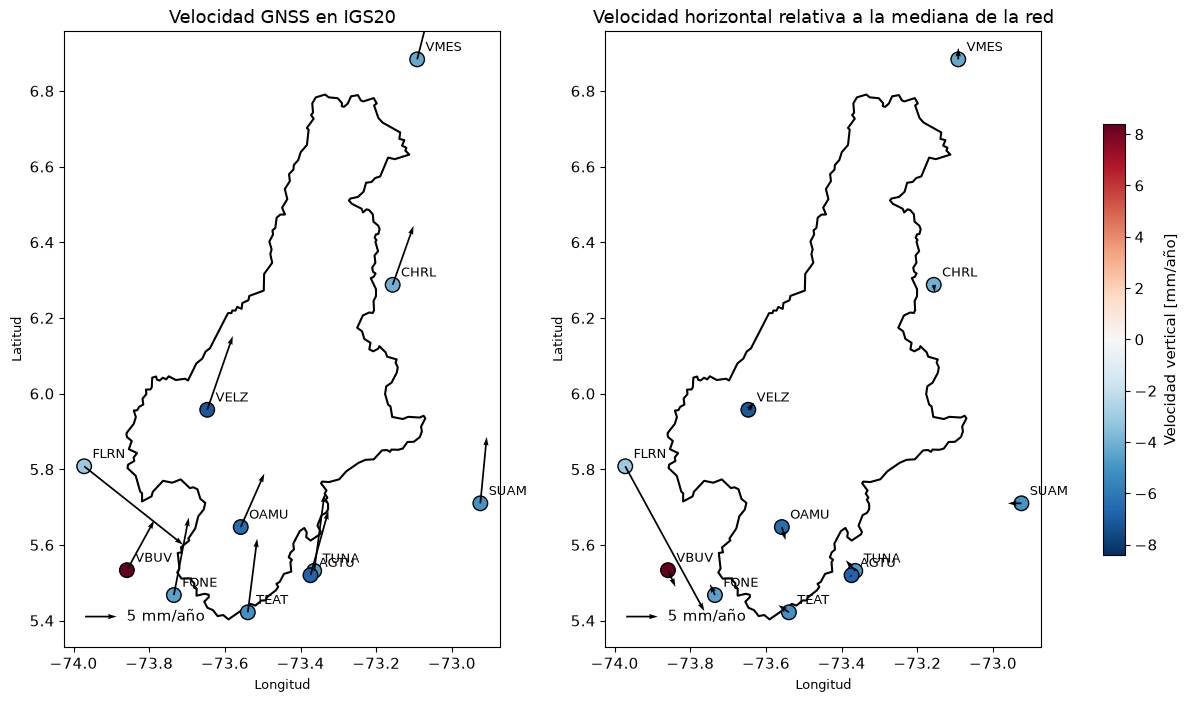

In [94]:
ESCALA_FLECHA = 60      # mm/año por grado del mapa
REF_FLECHA = 5          # longitud de la flecha de escala [mm/año]

v = vel_gnss.copy()
v["vE_rel"] = v["vE_mm"] - v["vE_mm"].median()
v["vN_rel"] = v["vN_mm"] - v["vN_mm"].median()
lim_u = max(np.nanpercentile(np.abs(v["vU_mm"]), 95), 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (ce, cn, titulo) in zip(axes, (("vE_mm", "vN_mm", "Velocidad GNSS en IGS20"),
                                       ("vE_rel", "vN_rel", "Velocidad horizontal relativa a la mediana de la red"))):
    gdf_cuenca.boundary.plot(ax=ax, color="black", lw=1.5)
    sc = ax.scatter(v["lon"], v["lat"], c=v["vU_mm"], cmap="RdBu_r", vmin=-lim_u, vmax=lim_u,
                    s=110, edgecolor="k", zorder=3)
    q = ax.quiver(v["lon"], v["lat"], v[ce], v[cn], angles="xy", scale_units="xy",
                  scale=ESCALA_FLECHA, width=0.004, zorder=4)
    ax.quiverkey(q, 0.12, 0.05, REF_FLECHA, f"{REF_FLECHA} mm/año", labelpos="E", coordinates="axes")
    for fila in v.itertuples():
        ax.annotate(fila.sitio, (fila.lon, fila.lat), xytext=(6, 6), textcoords="offset points", fontsize=9)
    ax.set(title=titulo, xlabel="Longitud", ylabel="Latitud")
    ax.set_aspect("equal")
plt.colorbar(sc, ax=axes.tolist(), shrink=0.7, label="Velocidad vertical [mm/año]")
plt.show()

## 26.4 Proyección a la línea de vista y comparación de velocidades

**Ejecución:** cada vez que se abre el notebook.

InSAR solo mide la componente del movimiento en la dirección terreno-satélite. Para comparar, para cada stack:

1. Se leen de `inputs/geometryGeo.h5` el ángulo de incidencia θ y el azimut α en el píxel de cada estación. En la convención de MintPy, α es el azimut del vector terreno-satélite, medido desde el norte y positivo en sentido antihorario (Yunjun et al., 2019).
2. Se calcula el vector unitario $\hat{u} = (-\sin\theta\sin\alpha,\ \sin\theta\cos\alpha,\ \cos\theta)$ y la velocidad GNSS en LOS como $v_{LOS} = \hat{u} \cdot (v_E, v_N, v_U)$ (EarthScope Consortium, 2026, módulo 1.2). Como control, la componente Este del vector debe ser positiva en órbita descendente y negativa en ascendente.
3. Se recalculan las velocidades GNSS con el modelo de 26.2, usando solo el periodo de ese stack.
4. Se toma la velocidad InSAR de `velocity.h5` como el promedio de los píxeles confiables en una ventana de 3 x 3 píxeles alrededor de la estación.
5. Se resta la diferencia constante entre InSAR y GNSS, usando la estación `REF_GNSS` o, si es `None`, la mediana de las diferencias.
6. Se calculan el sesgo, el error cuadrático medio (RMSE) y el coeficiente de correlación de Pearson.

Los pasos 2 y 5 equivalen a las opciones `--gnss-comp enu2los` y `--ref-gnss` de MintPy, usadas en la sección 5 del notebook `smallbaselineApp_aria.ipynb` del curso ISCE+ 2026 (EarthScope Consortium, 2026). Las tablas se guardan en `03_resultados/tablas/gnss_vs_insar_<stack>.csv`.

In [68]:
REF_GNSS = None          


def vector_los(inc, az):
    """Vector unitario terreno-satélite (E, N, U) con la convención de MintPy (ángulos en grados)."""
    inc, az = np.deg2rad(inc), np.deg2rad(az)
    return np.array([-np.sin(inc) * np.sin(az), np.sin(inc) * np.cos(az), np.cos(inc)])


def valor_en_punto(archivo, dataset, lat, lon, mascara=None, ventana=1):
    """Promedio de un dataset en la ventana alrededor de (lat, lon); NaN si está fuera o enmascarado."""
    v = ventana_en_punto(archivo, lat, lon, ventana)
    if v is None:
        return np.nan
    r0, r1, c0, c1 = v
    with h5py.File(archivo, "r") as f:
        datos = f[dataset][r0:r1, c0:c1].astype(float)
    valido = np.isfinite(datos) & (datos != 0)
    if mascara is not None:
        valido &= mascara[r0:r1, c0:c1]
    return float(np.mean(datos[valido])) if valido.any() else np.nan


comparaciones = {}
for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    etiqueta = job_name.replace(RUN_ID + "_", "")
    geo = d / "inputs" / "geometryGeo.h5"
    m = mascara_confiable(d)
    with h5py.File(serie_final(d), "r") as f:
        fechas_ts = pd.to_datetime(fechas_h5(f["date"][()]), format="%Y%m%d")
    t0, t1 = fechas_ts.min(), fechas_ts.max()

    filas = []
    for sitio, g in gnss.items():
        inc = valor_en_punto(geo, "incidenceAngle", g["lat"], g["lon"])
        az = valor_en_punto(geo, "azimuthAngle", g["lat"], g["lon"])
        if not np.isfinite(inc):
            continue
        s = g["serie"][(g["serie"]["fecha"] >= t0) & (g["serie"]["fecha"] <= t1)].reset_index(drop=True)
        if len(s) < 60:
            continue
        u = vector_los(inc, az)
        vel, sig = {}, {}
        for comp in "ENU":
            a = ajustar_trayectoria(s["fecha"], s[comp], s[f"sig_{comp}"], g["pasos"])
            vel[comp], sig[comp] = a["vel"], a["vel_sigma"]
        gnss_los = u @ np.array([vel["E"], vel["N"], vel["U"]])
        gnss_sig = float(np.sqrt(np.sum((u * np.array([sig["E"], sig["N"], sig["U"]])) ** 2)))
        insar = valor_en_punto(d / "velocity.h5", "velocity", g["lat"], g["lon"], mascara=m) * 1000
        insar_sig = valor_en_punto(d / "velocity.h5", "velocityStd", g["lat"], g["lon"], mascara=m) * 1000
        filas.append({"sitio": sitio, "lat": g["lat"], "lon": g["lon"], "inc_deg": round(inc, 1),
                      "az_deg": round(az, 1), "dias_gnss": len(s),
                      "gnss_los_mm": gnss_los, "gnss_sig_mm": gnss_sig,
                      "insar_los_mm": insar, "insar_sig_mm": insar_sig, "u": u})
    tabla = pd.DataFrame(filas)
    if tabla.empty:
        print(f"{etiqueta}: ninguna estación dentro del stack.")
        continue

    con_insar = tabla["insar_los_mm"].notna()
    dif = tabla["insar_los_mm"] - tabla["gnss_los_mm"]
    if REF_GNSS and REF_GNSS in set(tabla.loc[con_insar, "sitio"]):
        desfase = float(dif[tabla["sitio"] == REF_GNSS].iloc[0])
        criterio = f"estación {REF_GNSS}"
    else:
        desfase = float(np.median(dif[con_insar])) if con_insar.any() else 0.0
        criterio = "mediana de las diferencias"
    tabla["insar_ajustada_mm"] = tabla["insar_los_mm"] - desfase
    tabla["diferencia_mm"] = tabla["insar_ajustada_mm"] - tabla["gnss_los_mm"]

    ok = tabla[con_insar]
    n = len(ok)
    metricas = {"n": n, "desfase_mm": desfase, "criterio": criterio,
                "sesgo_mm": float(ok["diferencia_mm"].mean()) if n else np.nan,
                "rmse_mm": float(np.sqrt(np.mean(ok["diferencia_mm"] ** 2))) if n else np.nan,
                "r": float(np.corrcoef(ok["gnss_los_mm"], ok["insar_ajustada_mm"])[0, 1]) if n >= 3 else np.nan}
    comparaciones[job_name] = {"tabla": tabla, "metricas": metricas, "t0": t0, "t1": t1}

    u_medio = np.mean(np.vstack(tabla["u"]), axis=0)
    print("\n" + "-" * 70)
    print(f"{etiqueta}  ({t0.date()} a {t1.date()})")
    print(f"  Vector LOS medio (E, N, U): ({u_medio[0]:+.3f}, {u_medio[1]:+.3f}, {u_medio[2]:+.3f})")
    print(f"  Estaciones en el stack: {len(tabla)} | con InSAR confiable: {n} | referencia: {criterio} "
          f"(desfase {desfase:+.1f} mm/año)")
    print(f"  Sesgo {metricas['sesgo_mm']:+.2f} mm/año | RMSE {metricas['rmse_mm']:.2f} mm/año | r = {metricas['r']:.2f}")
    columnas = ["sitio", "inc_deg", "az_deg", "dias_gnss", "gnss_los_mm", "gnss_sig_mm",
                "insar_los_mm", "insar_sig_mm", "insar_ajustada_mm", "diferencia_mm"]
    display(tabla[columnas].round(2))
    tabla[columnas + ["lat", "lon"]].to_csv(TABLAS_DIR / f"gnss_vs_insar_{etiqueta}.csv", index=False)


----------------------------------------------------------------------
ASCENDING_R77_F1199  (2025-05-03 a 2026-09-14)
  Vector LOS medio (E, N, U): (-0.536, -0.110, +0.836)
  Estaciones en el stack: 4 | con InSAR confiable: 3 | referencia: mediana de las diferencias (desfase -12.1 mm/año)
  Sesgo -2.77 mm/año | RMSE 10.34 mm/año | r = -0.40


,sitio,inc_deg,az_deg,dias_gnss,gnss_los_mm,gnss_sig_mm,insar_los_mm,insar_sig_mm,insar_ajustada_mm,diferencia_mm
0,CHRL,36.2,101.6,187,27.13,2.70,-1.05,12.63,11.02,-16.11
1,VELZ,32.2,101.6,165,20.86,1.86,8.79,10.46,20.86,0.00
2,TUNA,33.7,101.7,191,24.41,3.22,20.15,8.53,32.21,7.81
3,FQNE,30.8,101.7,179,33.18,2.11,NaN,NaN,NaN,NaN



----------------------------------------------------------------------
DESCENDING_R69_F572  (2024-01-03 a 2026-09-14)
  Vector LOS medio (E, N, U): (+0.558, -0.115, +0.821)
  Estaciones en el stack: 8 | con InSAR confiable: 6 | referencia: mediana de las diferencias (desfase +4.8 mm/año)
  Sesgo +0.82 mm/año | RMSE 12.62 mm/año | r = -0.59


,sitio,inc_deg,az_deg,dias_gnss,gnss_los_mm,gnss_sig_mm,insar_los_mm,insar_sig_mm,insar_ajustada_mm,diferencia_mm
0,CHRL,33.0,-101.6,458,-2.68,2.59,NaN,NaN,NaN,NaN
1,VELZ,36.0,-101.6,500,-4.82,1.08,-1.85,2.14,-6.70,-1.88
2,VBUV,36.9,-101.6,191,9.04,2.39,-8.58,1.83,-13.42,-22.46
3,TUNA,33.4,-101.7,663,-4.53,0.76,17.85,0.96,13.01,17.53
4,AGTU,33.4,-101.7,209,-5.26,0.73,11.33,0.90,6.48,11.74
5,OAMU,34.9,-101.6,173,-4.10,1.06,-0.39,1.48,-5.24,-1.13
6,TEAT,34.5,-101.7,111,-5.44,0.99,0.54,1.20,-4.31,1.13
7,FQNE,35.9,-101.6,597,-4.00,1.21,NaN,NaN,NaN,NaN


## 26.5 Figuras de comparación de velocidades

**Ejecución:** cada vez que se abre el notebook.

Para cada stack se generan dos paneles:

1. Dispersión entre la velocidad GNSS proyectada y la velocidad InSAR, con barras de error de una desviación estándar y la línea 1:1. Si ambas técnicas coinciden, los puntos caen sobre la línea.
2. Mapa de velocidad InSAR con las estaciones encima, coloreadas con su velocidad GNSS en la misma escala. Un círculo que se confunde con el fondo indica acuerdo.

Estas figuras reproducen las que genera MintPy con `plot_insar_vs_gnss_scatter` y `view.py --show-gnss` en la sección 5 del notebook `smallbaselineApp_aria.ipynb` del curso ISCE+ 2026 (EarthScope Consortium, 2026). La posición de las estaciones se transforma al sistema del producto con `geopandas` (Jordahl et al., 2020).

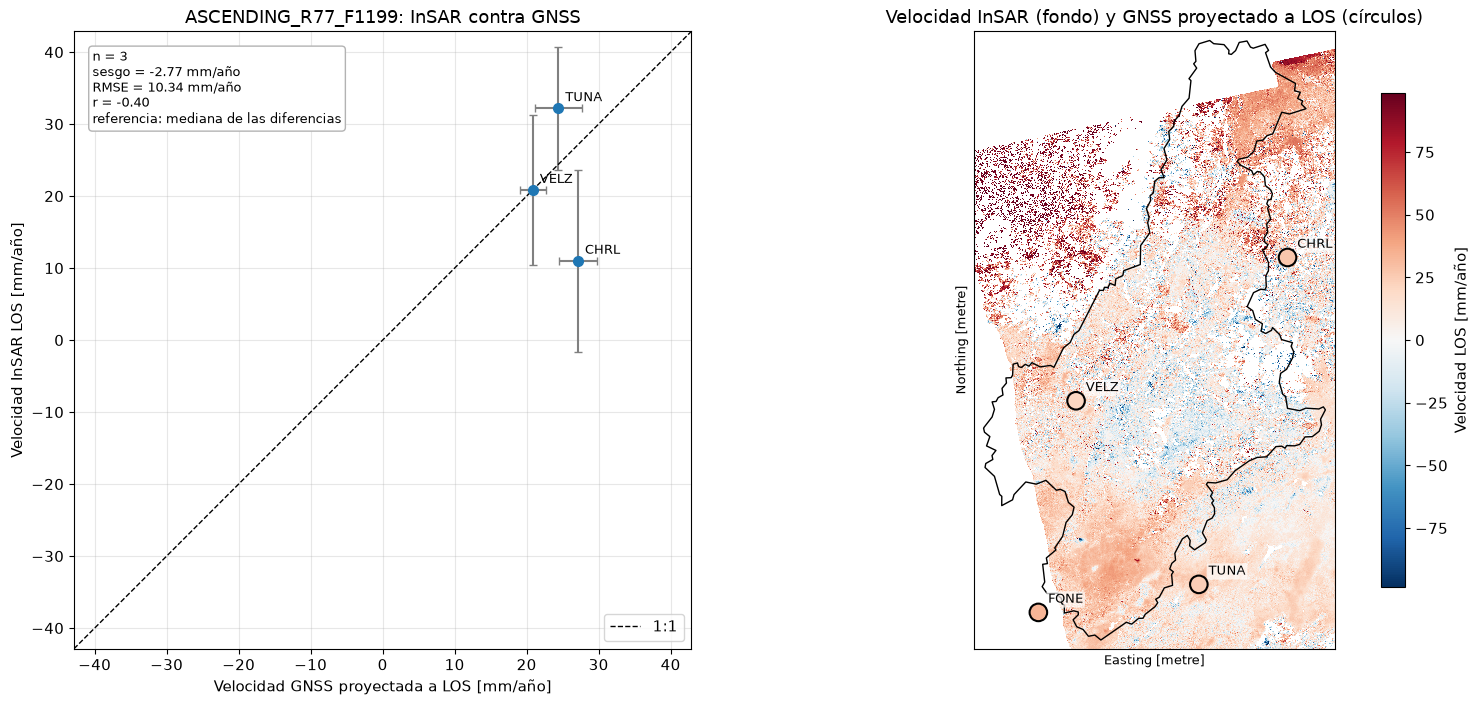

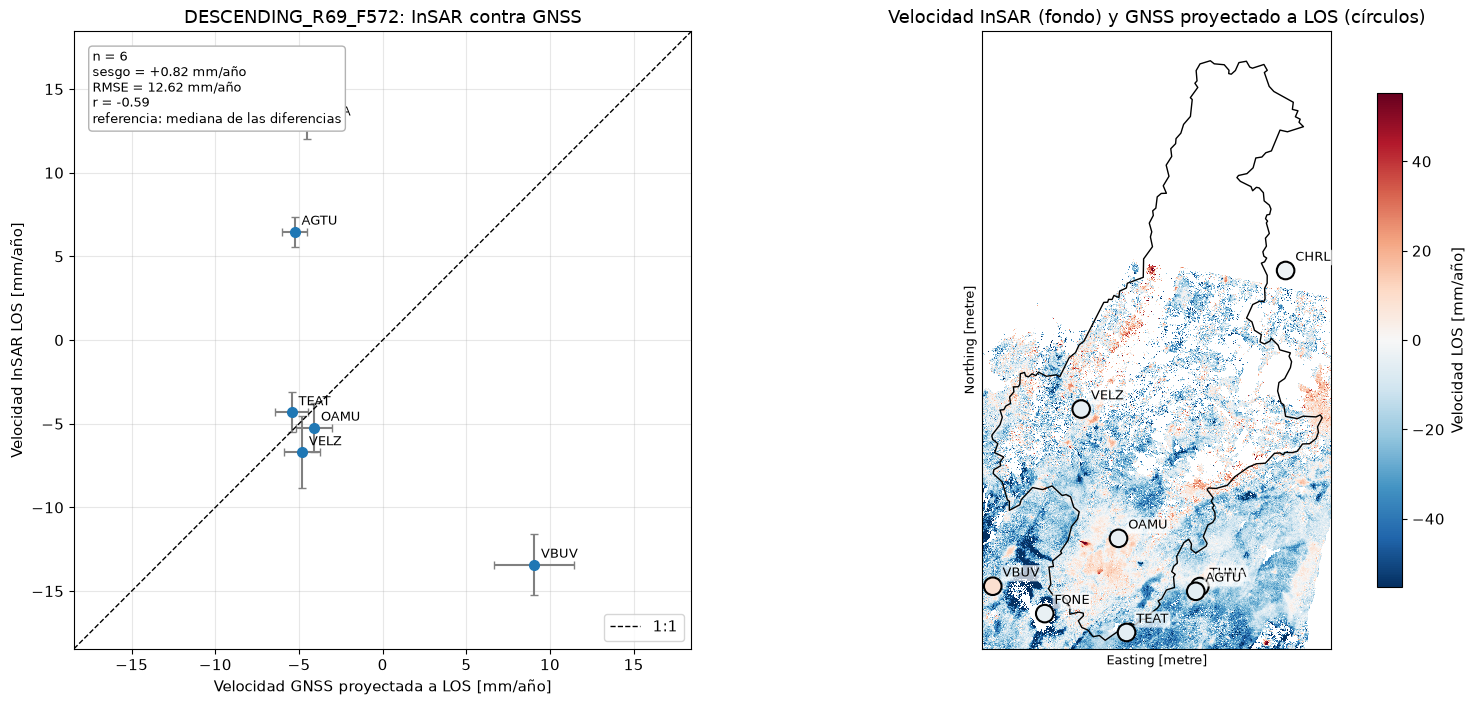

In [93]:
for job_name, comp in comparaciones.items():
    etiqueta = job_name.replace(RUN_ID + "_", "")
    tabla, met = comp["tabla"], comp["metricas"]
    ok = tabla[tabla["insar_los_mm"].notna()]
    d = MINTPY_ROOT / job_name

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.25]})
    ax = axes[0]
    ax.errorbar(ok["gnss_los_mm"], ok["insar_ajustada_mm"], xerr=ok["gnss_sig_mm"], yerr=ok["insar_sig_mm"],
                fmt="o", ms=7, color="tab:blue", ecolor="0.5", capsize=3)
    for fila in ok.itertuples():
        ax.annotate(fila.sitio, (fila.gnss_los_mm, fila.insar_ajustada_mm), xytext=(5, 5),
                    textcoords="offset points", fontsize=9)
    extremos = np.r_[ok["gnss_los_mm"], ok["insar_ajustada_mm"]]
    lim = (np.nanmax(np.abs(extremos)) if extremos.size else 5) * 1.3 + 1
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="1:1")
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), aspect="equal",
           xlabel="Velocidad GNSS proyectada a LOS [mm/año]", ylabel="Velocidad InSAR LOS [mm/año]",
           title=f"{etiqueta}: InSAR contra GNSS")
    ax.text(0.03, 0.97, f"n = {met['n']}\nsesgo = {met['sesgo_mm']:+.2f} mm/año\n"
                        f"RMSE = {met['rmse_mm']:.2f} mm/año\nr = {met['r']:.2f}\nreferencia: {met['criterio']}",
            transform=ax.transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round", fc="w", ec="0.7"))
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

    ax = axes[1]
    vel, at = leer_h5(d / "velocity.h5", "velocity")
    _, epsg = georef(at)
    mapa = np.where(mascara_confiable(d), vel * 1000 - met["desfase_mm"], np.nan)
    vlim = max(np.nanpercentile(np.abs(mapa), 98), np.nanmax(np.abs(tabla["gnss_los_mm"])))
    im = ax.imshow(mapa, extent=extent(at), cmap="RdBu_r", vmin=-vlim, vmax=vlim, interpolation="nearest")
    gdf_cuenca.to_crs(epsg).boundary.plot(ax=ax, color="k", lw=1)
    pts = gpd.GeoSeries(gpd.points_from_xy(tabla["lon"], tabla["lat"]), crs=4326).to_crs(epsg)
    ax.scatter(pts.x, pts.y, c=tabla["gnss_los_mm"], cmap="RdBu_r", vmin=-vlim, vmax=vlim,
               s=160, edgecolor="k", linewidth=1.5, zorder=3)
    for p, sitio in zip(pts, tabla["sitio"]):
        ax.annotate(sitio, (p.x, p.y), xytext=(7, 7), textcoords="offset points", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.15", fc="w", ec="none", alpha=0.7))
    plt.colorbar(im, ax=ax, shrink=0.8, label="Velocidad LOS [mm/año]")
    ax.set_title("Velocidad InSAR (fondo) y GNSS proyectado a LOS (círculos)")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

## 26.6 Comparación de series temporales

**Ejecución:** cada vez que se abre el notebook.

La comparación de velocidades resume todo el periodo en un número; la de series muestra si InSAR sigue también los cambios en el tiempo (EarthScope Consortium, 2026). Para cada estación con InSAR confiable:

1. Se proyecta a LOS cada día GNSS con el vector de 26.4 y se pasa a centímetros.
2. Se le suma el desfase de velocidad de 26.4 multiplicado por el tiempo, para llevarla al mismo marco relativo de InSAR, y se ajusta a cero en la primera fecha InSAR.
3. Se superpone la serie InSAR de la sección 23, con un punto por imagen.
4. Se sombrean los periodos sin datos GNSS de más de `HUECO_MIN_DIAS` días. No se rellenan, para no presentar como medición lo que no se midió.

El ruido de fecha a fecha es mayor en InSAR que en GNSS, principalmente por el retraso troposférico residual (Jolivet et al., 2011).


----------------------------------------------------------------------
CHRL  (6.2875, -73.1565)
  ASCENDING_R77_F1199: GNSS +27.1 | InSAR +11.0 | diferencia -16.1 mm/año
    GNSS con dato: 193 de 500 días (39 %) | huecos mayores a 10 días: 1 (46 días)


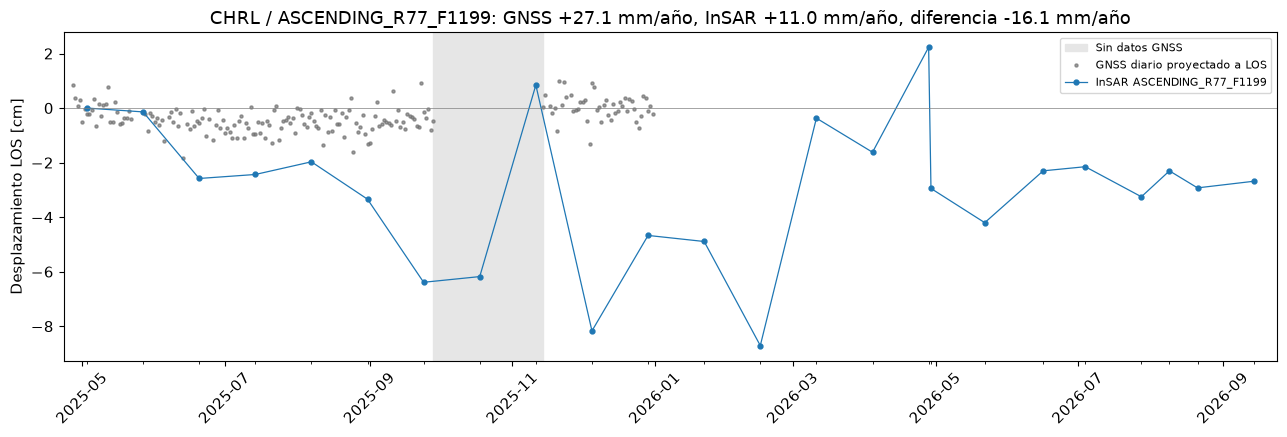


----------------------------------------------------------------------
SUAM  (5.7099, -72.9247)
  Sin InSAR confiable en ningún stack: no se genera gráfica.

----------------------------------------------------------------------
VMES  (6.8833, -73.0917)
  Sin InSAR confiable en ningún stack: no se genera gráfica.

----------------------------------------------------------------------
VELZ  (5.9571, -73.6466)
  ASCENDING_R77_F1199: GNSS +20.9 | InSAR +20.9 | diferencia +0.0 mm/año
    GNSS con dato: 171 de 500 días (34 %) | huecos mayores a 10 días: 2 (68 días)
  DESCENDING_R69_F572: GNSS -4.8 | InSAR -6.7 | diferencia -1.9 mm/año
    GNSS con dato: 500 de 986 días (51 %) | huecos mayores a 10 días: 3 (80 días)


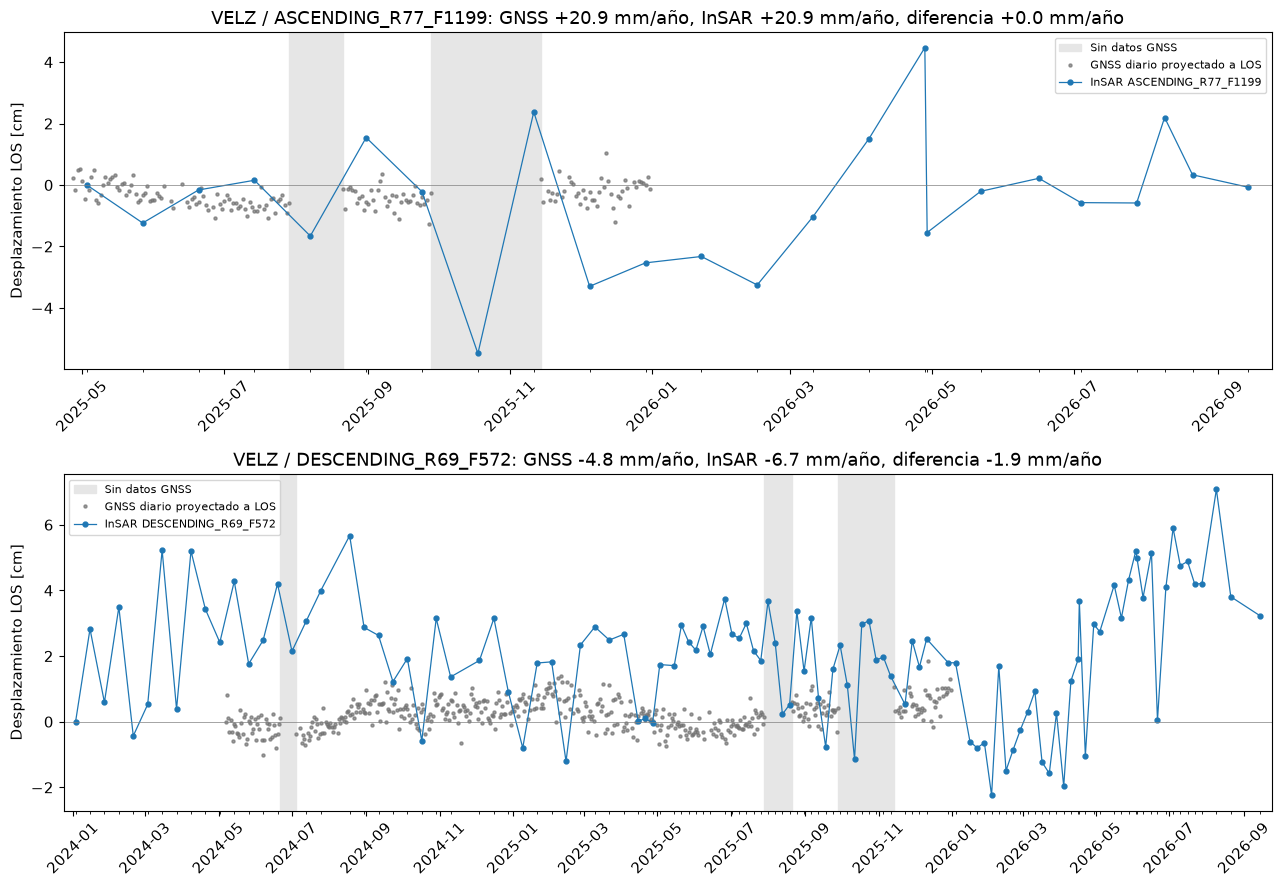


----------------------------------------------------------------------
FLRN  (5.8078, -73.9720)
  Sin InSAR confiable en ningún stack: no se genera gráfica.

----------------------------------------------------------------------
VBUV  (5.5332, -73.8589)
  DESCENDING_R69_F572: GNSS +9.0 | InSAR -13.4 | diferencia -22.5 mm/año
    GNSS con dato: 193 de 986 días (20 %) | huecos mayores a 10 días: 8 (459 días)


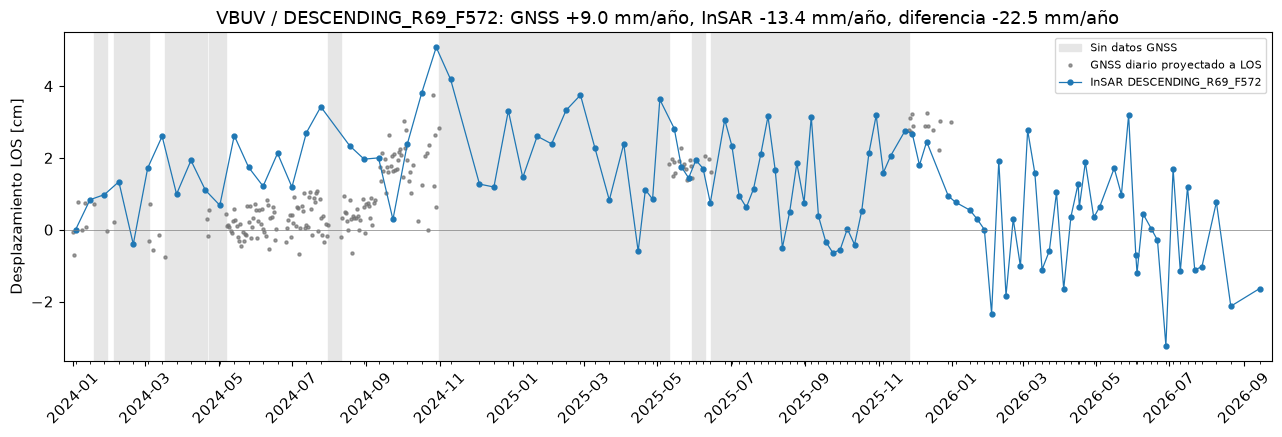


----------------------------------------------------------------------
TUNA  (5.5313, -73.3639)
  ASCENDING_R77_F1199: GNSS +24.4 | InSAR +32.2 | diferencia +7.8 mm/año
    GNSS con dato: 197 de 500 días (39 %) | huecos mayores a 10 días: 1 (46 días)
  DESCENDING_R69_F572: GNSS -4.5 | InSAR +13.0 | diferencia +17.5 mm/año
    GNSS con dato: 665 de 986 días (67 %) | huecos mayores a 10 días: 1 (46 días)


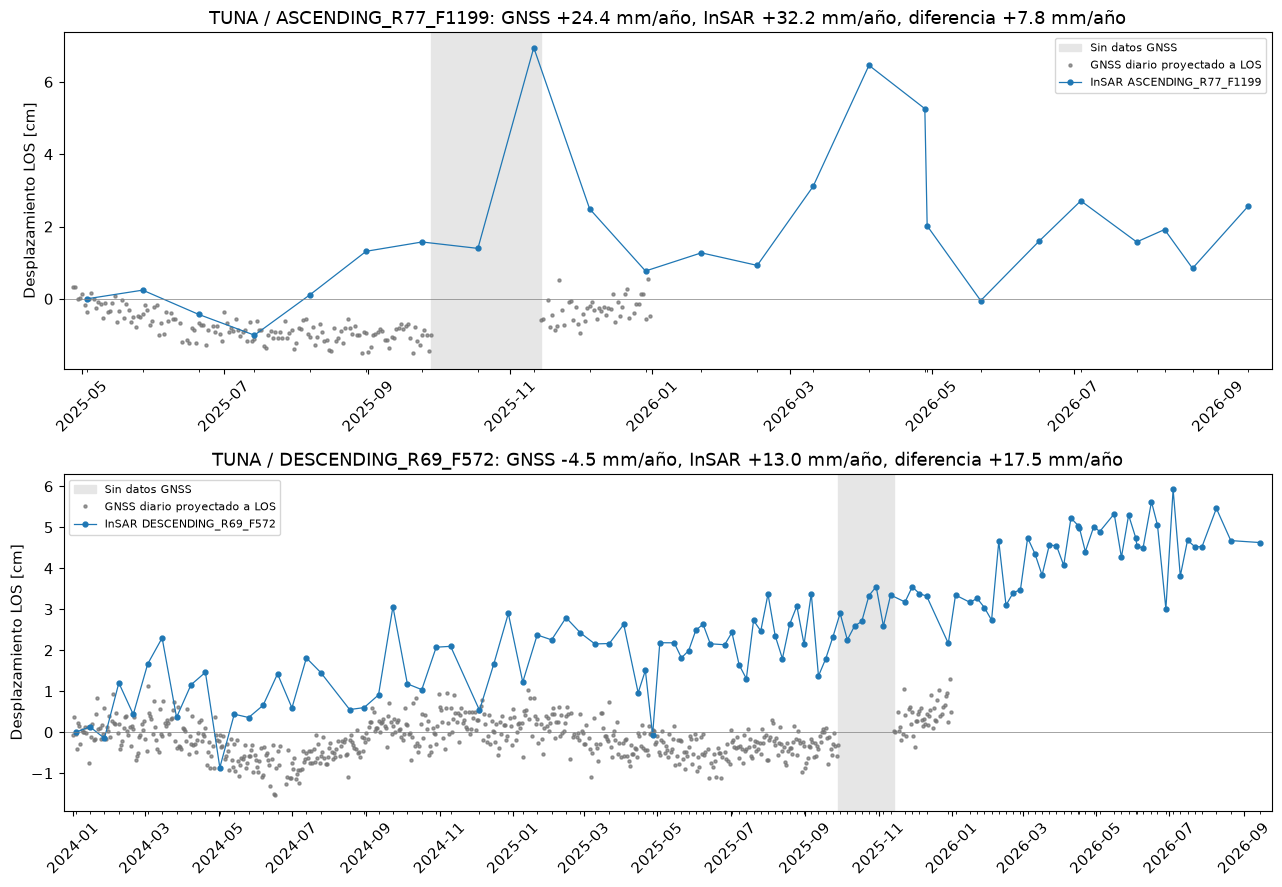


----------------------------------------------------------------------
AGTU  (5.5199, -73.3737)
  DESCENDING_R69_F572: GNSS -5.3 | InSAR +6.5 | diferencia +11.7 mm/año
    GNSS con dato: 211 de 986 días (21 %) | huecos mayores a 10 días: 4 (265 días)


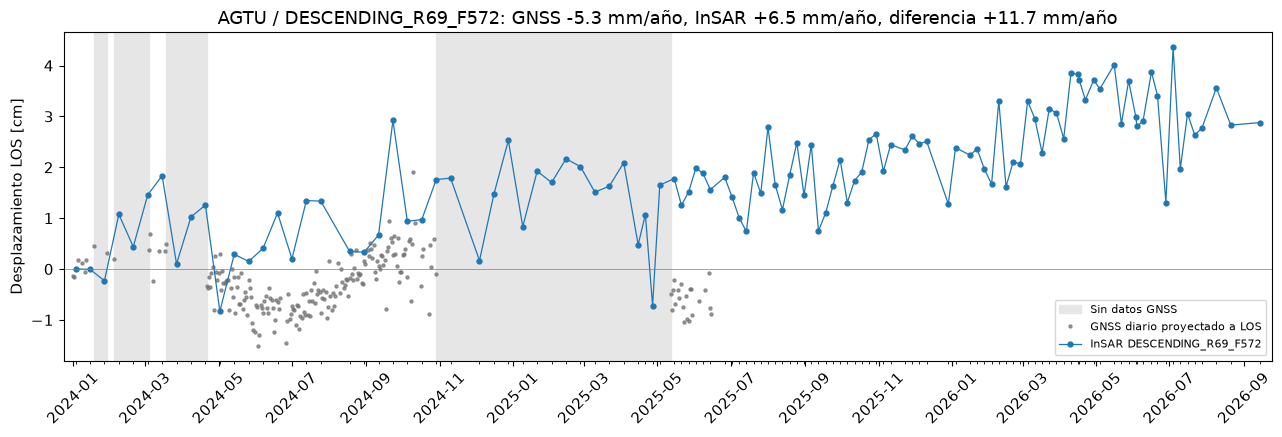


----------------------------------------------------------------------
OAMU  (5.6472, -73.5580)
  DESCENDING_R69_F572: GNSS -4.1 | InSAR -5.2 | diferencia -1.1 mm/año
    GNSS con dato: 175 de 986 días (18 %) | huecos mayores a 10 días: 4 (291 días)


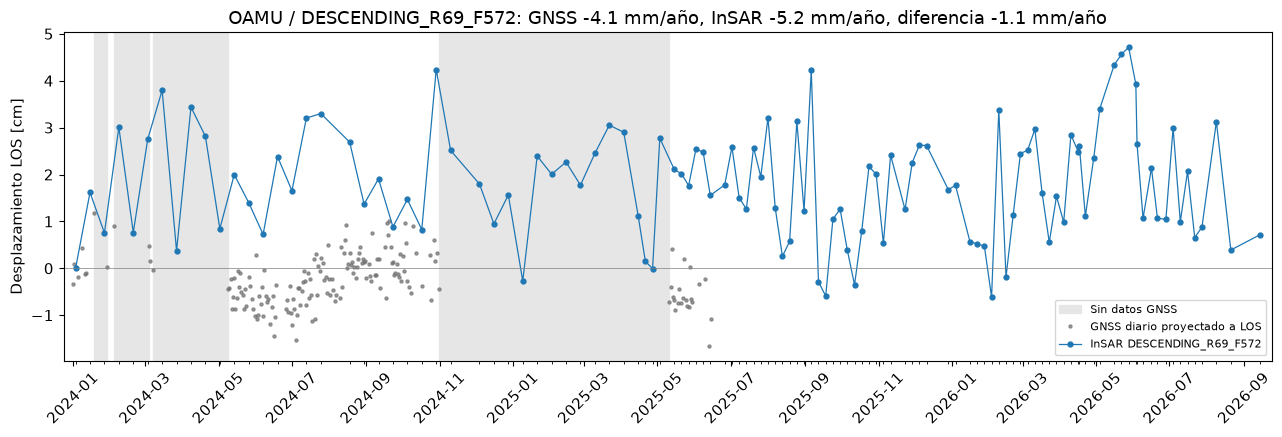


----------------------------------------------------------------------
TEAT  (5.4218, -73.5393)
  DESCENDING_R69_F572: GNSS -5.4 | InSAR -4.3 | diferencia +1.1 mm/año
    GNSS con dato: 113 de 986 días (11 %) | huecos mayores a 10 días: 9 (564 días)


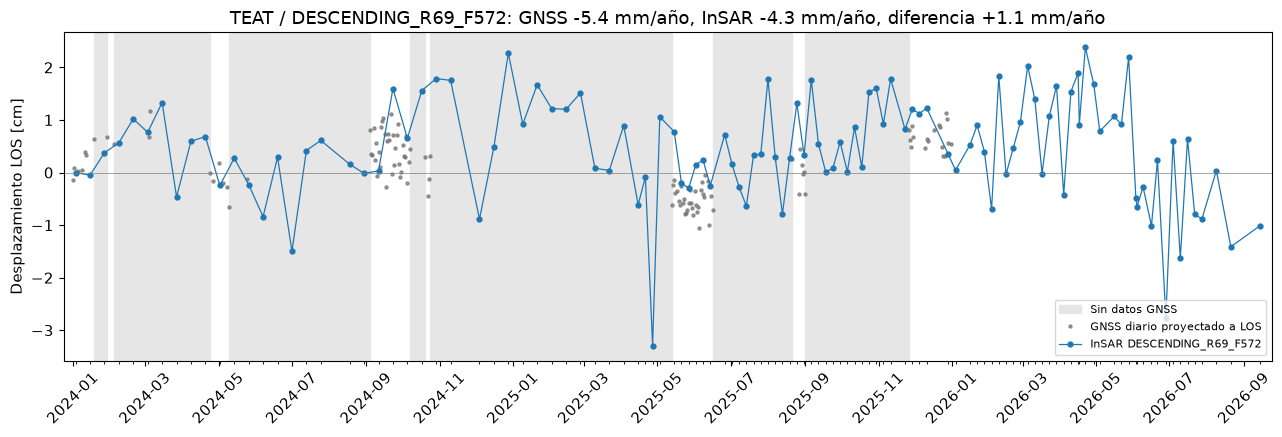


----------------------------------------------------------------------
FQNE  (5.4673, -73.7348)
  Sin InSAR confiable en ningún stack: no se genera gráfica.


In [83]:
HUECO_MIN_DIAS = 10  

for sitio, g in gnss.items():
    stacks_con_dato = [j for j, c in comparaciones.items()
                       if sitio in set(c["tabla"].loc[c["tabla"]["insar_los_mm"].notna(), "sitio"])]
    print("\n" + "-" * 70)
    print(f"{sitio}  ({g['lat']:.4f}, {g['lon']:.4f})")
    if not stacks_con_dato:
        print("  Sin InSAR confiable en ningún stack: no se genera gráfica.")
        continue

    fig, axes = plt.subplots(len(stacks_con_dato), 1, figsize=(13, 4.5 * len(stacks_con_dato)), squeeze=False)
    for ax, job_name in zip(axes[:, 0], stacks_con_dato):
        c = comparaciones[job_name]
        etiqueta = job_name.replace(RUN_ID + "_", "")
        fila = c["tabla"].set_index("sitio").loc[sitio]

        # Días GNSS dentro del periodo del stack
        dentro = ((g["serie"]["fecha"] >= c["t0"] - pd.Timedelta(days=6))
                  & (g["serie"]["fecha"] <= c["t1"])).to_numpy()
        s = g["serie"][dentro].reset_index(drop=True)

        # Proyección a LOS (cm) y paso al marco relativo de InSAR
        anios = ((s["fecha"] - c["t0"]).dt.days / 365.25).to_numpy()
        los = (s[["E", "N", "U"]].to_numpy() @ fila["u"]) / 10 + c["metricas"]["desfase_mm"] / 10 * anios
        inicio = np.abs((s["fecha"] - c["t0"]).dt.days) <= 6
        los = los - (np.mean(los[inicio]) if inicio.any() else los[0])

        # Huecos en la serie GNSS
        saltos = s["fecha"].diff().dt.days.to_numpy()
        huecos = [(s["fecha"].iloc[i - 1], s["fecha"].iloc[i]) for i in np.where(saltos > HUECO_MIN_DIAS)[0]]
        for k, (a, b) in enumerate(huecos):
            ax.axvspan(a, b, color="0.9", zorder=0, label="Sin datos GNSS" if k == 0 else None)

        fechas, serie = serie_en_punto(MINTPY_ROOT / job_name, g["lat"], g["lon"])
        ax.plot(s["fecha"], los, "o", ms=2.2, color="0.45", alpha=0.7, label="GNSS diario proyectado a LOS")
        ax.plot(fechas, serie, "o-", ms=3.5, lw=0.9, color="tab:blue", label=f"InSAR {etiqueta}")
        ax.axhline(0, color="gray", lw=0.5)
        ax.set(ylabel="Desplazamiento LOS [cm]",
               title=f"{sitio} / {etiqueta}: GNSS {fila['gnss_los_mm']:+.1f} mm/año, "
                     f"InSAR {fila['insar_ajustada_mm']:+.1f} mm/año, diferencia {fila['diferencia_mm']:+.1f} mm/año")
        ax.set_xlim(c["t0"] - pd.Timedelta(days=10), c["t1"] + pd.Timedelta(days=10))
        ax.set_xticks(fechas, minor=True)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis="x", which="major", rotation=45)
        ax.legend(fontsize=8, loc="best")

        dias_total = (c["t1"] - c["t0"]).days + 1
        dias_hueco = int(sum((b - a).days - 1 for a, b in huecos))
        print(f"  {etiqueta}: GNSS {fila['gnss_los_mm']:+.1f} | InSAR {fila['insar_ajustada_mm']:+.1f} | "
              f"diferencia {fila['diferencia_mm']:+.1f} mm/año")
        print(f"    GNSS con dato: {len(s)} de {dias_total} días ({100 * len(s) / dias_total:.0f} %) | "
              f"huecos mayores a {HUECO_MIN_DIAS} días: {len(huecos)} ({dias_hueco} días)")
    plt.tight_layout()
    plt.show()

## Referencias

Alaska Satellite Facility. (s.f.-a). *asf_search* [Software]. https://docs.asf.alaska.edu/asf_search/basics/

Alaska Satellite Facility. (s.f.-b). *Time series analysis with HyP3 and MintPy* [Cuaderno de Jupyter]. https://github.com/ASFHyP3/hyp3-docs/blob/main/docs/tutorials/hyp3_insar_stack_for_ts_analysis.ipynb

Alaska Satellite Facility. (s.f.-c). *HyP3 SDK* [Documentación de software]. https://hyp3-docs.asf.alaska.edu/using/sdk/

Alaska Satellite Facility. (s.f.-d). *Sentinel-1 InSAR product guide* [Documentación]. https://hyp3-docs.asf.alaska.edu/guides/insar_product_guide/

Alaska Satellite Facility. (s.f.-e). *OpenScienceLab* [Plataforma de cómputo en la nube]. https://opensciencelab.asf.alaska.edu/

Altamimi, Z., Rebischung, P., Collilieux, X., Métivier, L., & Chanard, K. (2023). ITRF2020: An augmented reference frame refining the modeling of nonlinear station motions. *Journal of Geodesy, 97*(5), 47. https://doi.org/10.1007/s00190-023-01738-w

Berardino, P., Fornaro, G., Lanari, R., & Sansosti, E. (2002). A new algorithm for surface deformation monitoring based on small baseline differential SAR interferograms. *IEEE Transactions on Geoscience and Remote Sensing, 40*(11), 2375–2383. https://doi.org/10.1109/TGRS.2002.803792

Bertiger, W., Bar-Sever, Y., Dorsey, A., Haines, B., Harvey, N., Hemberger, D., et al. (2020). GipsyX/RTGx, a new tool set for space geodetic operations and research. *Advances in Space Research, 66*(3), 469–489. https://doi.org/10.1016/j.asr.2020.04.015

Bevis, M., & Brown, A. (2014). Trajectory models and reference frames for crustal motion geodesy. *Journal of Geodesy, 88*(3), 283–311. https://doi.org/10.1007/s00190-013-0685-5

Blewitt, G., Hammond, W. C., & Kreemer, C. (2018). Harnessing the GPS data explosion for interdisciplinary science. *Eos, 99*. https://doi.org/10.1029/2018EO104623

Collette, A. (2013). *Python and HDF5*. O'Reilly Media.

Copernicus Sentinel-1. (2024–2026). *Sentinel-1 Interferometric Wide Swath SLC products* [Conjunto de datos]. European Space Agency. Obtenido del Alaska Satellite Facility Distributed Active Archive Center. https://search.asf.alaska.edu/

da Costa-Luis, C. O. (2019). tqdm: A fast, extensible progress meter for Python and CLI. *Journal of Open Source Software, 4*(37), 1277. https://doi.org/10.21105/joss.01277

Doin, M.-P., Lasserre, C., Peltzer, G., Cavalié, O., & Doubre, C. (2009). Corrections of stratified tropospheric delays in SAR interferometry: Validation with global atmospheric models. *Journal of Applied Geophysics, 69*(1), 35–50. https://doi.org/10.1016/j.jappgeo.2009.03.010

EarthScope Consortium. (2026). *2026 Technical Course: InSAR Processing and Analysis (ISCE+)* [Materiales de curso]. https://github.com/isceplus/2026-isceplus

European Space Agency. (2022). *Copernicus Global Digital Elevation Model GLO-30* [Conjunto de datos]. https://doi.org/10.5270/ESA-c5d3d65

Fattahi, H., & Amelung, F. (2013). DEM error correction in InSAR time series. *IEEE Transactions on Geoscience and Remote Sensing, 51*(7), 4249–4259. https://doi.org/10.1109/TGRS.2012.2227761

Geng, J., Wen, Q., & Sievers, C. (2024). *Multi-GNSS precise point positioning and PRIDE PPP-AR* [Curso técnico, 10 y 12 de septiembre de 2024; grabaciones]. EarthScope Consortium. https://www.earthscope.org/event/2024-technical-short-course-multi-gnss-precise-point-positioning-and-pride-ppp-ar/

Gillies, S., et al. (2013). *Rasterio: Geospatial raster I/O for Python programmers* [Software]. https://github.com/rasterio/rasterio

Gillies, S., van der Wel, C., Van den Bossche, J., Taves, M. W., Arnott, J., Ward, B. C., et al. (2024). *Shapely* (Versión 2.0) [Software]. Zenodo. https://doi.org/10.5281/zenodo.5597138

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., et al. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Herring, T., Floyd, M., Stamps, D. S., & Berglund, H. (2026). *GNSS data processing and analysis with GAMIT/GLOBK and track* [Curso técnico, 23 a 31 de julio de 2026]. EarthScope Consortium. https://www.earthscope.org/event/2026-technical-course-gnss-data-processing-and-analysis-with-gamit-globk-and-track/

Herring, T. A., Melbourne, T. I., Murray, M. H., Floyd, M. A., Szeliga, W. M., King, R. W., Phillips, D. A., Puskas, C. M., Santillan, M., & Wang, L. (2016). Plate Boundary Observatory and related networks: GPS data analysis methods and geodetic products. *Reviews of Geophysics, 54*(4), 759–808. https://doi.org/10.1002/2016RG000529

Hersbach, H., Bell, B., Berrisford, P., Hirahara, S., Horányi, A., Muñoz-Sabater, J., et al. (2020). The ERA5 global reanalysis. *Quarterly Journal of the Royal Meteorological Society, 146*(730), 1999–2049. https://doi.org/10.1002/qj.3803

Hetland, E. A., Musé, P., Simons, M., Lin, Y. N., Agram, P. S., & DiCaprio, C. J. (2012). Multiscale InSAR Time Series (MInTS) analysis of surface deformation. *Journal of Geophysical Research: Solid Earth, 117*(B2), B02404. https://doi.org/10.1029/2011JB008731

Hogenson, K., Kristenson, H., Kennedy, J., Johnston, A., Rine, J., Logan, T., Zhu, J., Williams, F., Herrmann, J., Smale, J., & Meyer, F. (2026). *Hybrid Pluggable Processing Pipeline (HyP3): A cloud-native infrastructure for generic processing of SAR data* [Software]. Zenodo. https://doi.org/10.5281/zenodo.4646138

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Jolivet, R., Grandin, R., Lasserre, C., Doin, M.-P., & Peltzer, G. (2011). Systematic InSAR tropospheric phase delay corrections from global meteorological reanalysis data. *Geophysical Research Letters, 38*(17), L17311. https://doi.org/10.1029/2011GL048757

Jordahl, K., Van den Bossche, J., Fleischmann, M., Wasserman, J., McBride, J., Gerard, J., et al. (2020). *geopandas/geopandas* (Versión 0.8.1) [Software]. Zenodo. https://doi.org/10.5281/zenodo.3946761

McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

Mora-Páez, H., Kellogg, J. N., Freymueller, J. T., Mencin, D., Fernandes, R. M. S., Diederix, H., et al. (2019). Crustal deformation in the northern Andes: A new GPS velocity field. *Journal of South American Earth Sciences, 89*, 76–91. https://doi.org/10.1016/j.jsames.2018.11.002

Nevada Geodetic Laboratory. (2026). *GNSS time series, IGS20 solution* [Conjunto de datos]. University of Nevada, Reno. https://geodesy.unr.edu/

Pepe, A., & Lanari, R. (2006). On the extension of the minimum cost flow algorithm for phase unwrapping of multitemporal differential SAR interferograms. *IEEE Transactions on Geoscience and Remote Sensing, 44*(9), 2374–2383. https://doi.org/10.1109/TGRS.2006.873207

Python Software Foundation. (2024). *The Python standard library* (Versión 3.11) [Documentación de software]. https://docs.python.org/3/library/

Snow, A. D., Whitaker, J., Cochran, M., Van den Bossche, J., Mayo, C., et al. (2024). *pyproj4/pyproj* [Software]. Zenodo. https://doi.org/10.5281/zenodo.2592232

Torres, R., Snoeij, P., Geudtner, D., Bibby, D., Davidson, M., Attema, E., et al. (2012). GMES Sentinel-1 mission. *Remote Sensing of Environment, 120*, 9–24. https://doi.org/10.1016/j.rse.2011.05.028

Werner, C., Wegmüller, U., Strozzi, T., & Wiesmann, A. (2000). GAMMA SAR and interferometric processing software. En *Proceedings of the ERS-Envisat Symposium* (ESA SP-461). European Space Agency.

Williams, S. D. P. (2003). The effect of coloured noise on the uncertainties of rates estimated from geodetic time series. *Journal of Geodesy, 76*(9–10), 483–494. https://doi.org/10.1007/s00190-002-0283-4

Yunjun, Z., Fattahi, H., & Amelung, F. (2019). Small baseline InSAR time series analysis: Unwrapping error correction and noise reduction. *Computers & Geosciences, 133*, 104331. https://doi.org/10.1016/j.cageo.2019.104331

Yunjun, Z., Fattahi, H., Pi, X., Rosen, P., Simons, M., Agram, P., & Aoki, Y. (2022). Range geolocation accuracy of C-/L-band SAR and its implications for operational stack coregistration. *IEEE Transactions on Geoscience and Remote Sensing, 60*, 1–19. https://doi.org/10.1109/TGRS.2022.3168509

Zumberge, J. F., Heflin, M. B., Jefferson, D. C., Watkins, M. M., & Webb, F. H. (1997). Precise point positioning for the efficient and robust analysis of GPS data from large networks. *Journal of Geophysical Research: Solid Earth, 102*(B3), 5005–5017. https://doi.org/10.1029/96JB03860